# Setup and configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
RANDOM_SEED = 42

ROOT_DIR = Path.cwd()
STAGE2_OUTPUT_DIR = ROOT_DIR / "outputs" / "stage2"
STAGE3_OUTPUT_DIR = ROOT_DIR / "outputs" / "stage3"

STAGE3_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_SEED)

N_BOOTSTRAP = 1000

# Load Stage 2 outputs

In [3]:
# Stage 2 output files
trade_features_path = STAGE2_OUTPUT_DIR / "trade_features.parquet"
idea_features_path = STAGE2_OUTPUT_DIR / "idea_features.parquet"
feature_check_results_path = STAGE2_OUTPUT_DIR / "feature_check_results.csv"
feature_dictionary_path = STAGE2_OUTPUT_DIR / "feature_dictionary.csv"

# Load Stage 2 outputs
trade_features = pd.read_parquet(trade_features_path)
idea_features = pd.read_parquet(idea_features_path)
feature_check_results = pd.read_csv(feature_check_results_path)
feature_dictionary = pd.read_csv(feature_dictionary_path)

In [4]:
print(f"trade_features shape: {trade_features.shape}")
print(f"idea_features shape: {idea_features.shape}")
print(f"feature_check_results shape: {feature_check_results.shape}")
print(f"feature_dictionary shape: {feature_dictionary.shape}")

trade_features shape: (46520, 132)
idea_features shape: (33379, 44)
feature_check_results shape: (22, 12)
feature_dictionary shape: (24, 8)


In [5]:
trade_model_data = trade_features.copy()
idea_model_data = idea_features.copy()

In [6]:
idea_timing_columns = [
    "idea_id",
    "minutes_since_previous_idea_start",
    "past_median_idea_start_gap_minutes",
    "idea_start_gap_to_past_median_ratio",
]

trade_model_data = trade_model_data.merge(
    idea_features[idea_timing_columns],
    on="idea_id",
    how="left",
    validate="many_to_one",
)

# Prepare leakage-safe features

## Define identifier, target and banned features

In [7]:
# Columns needed for splitting, evaluation, and account-level bootstrap.
identifier_columns = [
    "trade_row_id",
    "campaign_id",
    "account_id",
    "idea_id",
    "open_date_time",
    "close_date_time",
]

evaluation_columns = [
    "amount", 
    "reverse_profit",
]

target_column = "reverse_profit_per_lot"

In [8]:
banned_sl_tp_columns = [
    "sl_price",
    "tp_price",
    "has_stop_loss",
    "has_take_profit",
    "has_both_sl_tp",
    "has_neither_sl_tp",
    "sl_tp_configuration",
    "stop_loss_distance",
    "take_profit_distance",
    "valid_stop_loss_distance",
    "valid_take_profit_distance",
    "stop_loss_distance_pct",
    "take_profit_distance_pct",
    "planned_reward_to_risk_ratio",
]

In [9]:
banned_outcome_columns = [
    "profit",
    "net_profit",
    "reverse_profit",
    "expected_net_profit",
    "net_profit_difference",
    "net_profit_reconciles",
    "reverse_profit_per_lot",
    "idea_end_time",
    "mean_net_profit",
    "maximum_net_profit",
    "minimum_net_profit",
    "total_net_profit",
]

## Define leakage-safe stage 2 candidate features

### Loss response

In [10]:
loss_response_features = [
    "post_loss_entry",
    "post_loss_reentry_gap_minutes",
    "post_loss_amount_ratio",
    "post_loss_amount_increased",
]

### Trading activity and timing

In [11]:
activity_timing_features = [
    "past_trade_open_count",
    "past_idea_start_count",
    "elapsed_active_minutes",
    "elapsed_active_hours",
    "past_trades_opened_per_active_hour",
    "past_ideas_started_per_active_hour",
    "trades_opened_past_15_minutes",
    "trades_opened_past_30_minutes",
    "trades_opened_past_60_minutes",
    "ideas_started_past_15_minutes",
    "ideas_started_past_30_minutes",
    "ideas_started_past_60_minutes",
    "minutes_since_previous_trade_open",
    "past_median_trade_open_gap_minutes",
    "trade_open_gap_to_past_median_ratio",
    "minutes_since_previous_idea_start",
    "past_median_idea_start_gap_minutes",
    "idea_start_gap_to_past_median_ratio",
]

### Challenge state and drawdown pressure

In [12]:
challenge_state_features = [
    "realized_pnl_before_trade",
    "realized_return_before_trade",
    "realized_balance_before_trade",
    "realized_distance_to_drawdown_limit",
    "realized_distance_to_profit_target",
]

### Position sizing

In [13]:
position_sizing_features = [
    "historical_median_amount_before_trade",
    "current_to_historical_median_amount_ratio",
    "past_amount_count",
    "past_amount_mean",
    "past_amount_std",
    "past_amount_cv",
]

### Historical performance

In [14]:
historical_performance_features = [
    "past_completed_idea_count",
    "past_winning_idea_count",
    "past_losing_idea_count",
    "past_idea_win_rate",
    "past_mean_win_profit_per_lot",
    "past_mean_loss_abs_profit_per_lot",
    "past_payoff_ratio",
]

In [15]:
candidate_feature_columns = (
    loss_response_features
    + activity_timing_features
    + challenge_state_features
    + position_sizing_features
    + historical_performance_features
)

## Keep only features that actually exist

In [16]:
available_feature_columns = [
    column
    for column in candidate_feature_columns
    if column in trade_model_data.columns
]

missing_feature_columns = sorted(
    set(candidate_feature_columns) - set(available_feature_columns)
)

print(f"Candidate features requested: {len(candidate_feature_columns)}")
print(f"Candidate features available: {len(available_feature_columns)}")

if missing_feature_columns:
    print("\nMissing Stage 2 features:")
    for column in missing_feature_columns:
        print(f"- {column}")

Candidate features requested: 40
Candidate features available: 40


## Leakage assertion

In [17]:
banned_feature_columns = set(
    banned_sl_tp_columns
    + banned_outcome_columns
)

leaking_features = sorted(
    set(available_feature_columns) & banned_feature_columns
)

assert not leaking_features, (
    "Leakage detected in model features: "
    + ", ".join(leaking_features)
)

print("Leakage check passed.")

Leakage check passed.


# Rebuild SL/TP behaviour using only pre-trade information

## Predicted  SL/TP probability

### Build historical SL/TP usage features

In [18]:
def build_historical_sl_tp_usage_features(data):
    """Build account-level historical SL/TP usage features.

    For each trade, only trades from the same account that closed strictly
    before the current trade opened are included.

    Args:
        data: Trade-level DataFrame containing account ID, open and close
            timestamps, and observed SL/TP fields.

    Returns:
        DataFrame with historical SL/TP usage features attached.
    """
    result = data.copy()

    result["open_date_time"] = pd.to_datetime(result["open_date_time"])
    result["close_date_time"] = pd.to_datetime(result["close_date_time"])

    # These are historical outcomes only.
    result["observed_has_sl"] = result["sl_price"].notna().astype(int)
    result["observed_has_tp"] = result["tp_price"].notna().astype(int)

    result["observed_has_both_sl_tp"] = (
        (result["observed_has_sl"] == 1)
        & (result["observed_has_tp"] == 1)
    ).astype(int)

    result["observed_has_neither_sl_tp"] = (
        (result["observed_has_sl"] == 0)
        & (result["observed_has_tp"] == 0)
    ).astype(int)

    # Aggregate trades closing at exactly the same timestamp.
    close_events = (
        result.groupby(
            ["account_id", "close_date_time"],
            as_index=False,
        )
        .agg(
            completed_trade_count=("trade_row_id", "size"),
            completed_sl_count=("observed_has_sl", "sum"),
            completed_tp_count=("observed_has_tp", "sum"),
            completed_both_sl_tp_count=("observed_has_both_sl_tp", "sum"),
            completed_neither_sl_tp_count=(
                "observed_has_neither_sl_tp",
                "sum",
            ),
        )
    )

    cumulative_columns = [
        "completed_trade_count",
        "completed_sl_count",
        "completed_tp_count",
        "completed_both_sl_tp_count",
        "completed_neither_sl_tp_count",
    ]

    close_events = close_events.sort_values(
        ["close_date_time", "account_id"]
    )

    close_events[cumulative_columns] = (
        close_events.groupby("account_id")[cumulative_columns]
        .cumsum()
    )

    trade_order = result.sort_values(
        ["open_date_time", "account_id", "trade_row_id"]
    ).copy()

    historical = pd.merge_asof(
        trade_order[
            [
                "trade_row_id",
                "account_id",
                "open_date_time",
            ]
        ],
        close_events,
        by="account_id",
        left_on="open_date_time",
        right_on="close_date_time",
        direction="backward",
        allow_exact_matches=False,
    )

    historical = historical.rename(
        columns={
            "completed_trade_count": "past_completed_trade_count",
            "completed_sl_count": "past_sl_count",
            "completed_tp_count": "past_tp_count",
            "completed_both_sl_tp_count": "past_both_sl_tp_count",
            "completed_neither_sl_tp_count": "past_neither_sl_tp_count",
        }
    )

    count = historical["past_completed_trade_count"]

    historical["past_sl_usage_rate"] = (
        historical["past_sl_count"] / count
    )

    historical["past_tp_usage_rate"] = (
        historical["past_tp_count"] / count
    )

    historical["past_both_sl_tp_rate"] = (
        historical["past_both_sl_tp_count"] / count
    )

    historical["past_neither_sl_tp_rate"] = (
        historical["past_neither_sl_tp_count"] / count
    )

    historical_features = [
        "trade_row_id",
        "past_completed_trade_count",
        "past_sl_count",
        "past_tp_count",
        "past_both_sl_tp_count",
        "past_neither_sl_tp_count",
        "past_sl_usage_rate",
        "past_tp_usage_rate",
        "past_both_sl_tp_rate",
        "past_neither_sl_tp_rate",
    ]

    result = result.merge(
        historical[historical_features],
        on="trade_row_id",
        how="left",
        validate="one_to_one",
    )

    return result

In [19]:
trade_model_data = build_historical_sl_tp_usage_features(
    trade_model_data
)

### Walk-forward probability prediction for SL/TP

In [20]:
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def build_probability_model(model_name):
    """Build a probability classification model.

    Args:
        model_name: Name of the classification model.

    Returns:
        Classification model compatible with predict_proba().

    Raises:
        ValueError: If the requested model is unsupported.
    """
    if model_name == "logistic_regression":
        return Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    LogisticRegression(
                        max_iter=1_000,
                        random_state=RANDOM_SEED,
                    ),
                ),
            ]
        )

    if model_name == "lightgbm":
        return LGBMClassifier(
            n_estimators=200,
            learning_rate=0.05,
            num_leaves=15,
            random_state=RANDOM_SEED,
            verbosity=-1,
        )

    if model_name == "xgboost":
        return XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=RANDOM_SEED,
            eval_metric="logloss",
            n_jobs=-1,
        )

    if model_name == "catboost":
        return CatBoostClassifier(
            iterations=200,
            learning_rate=0.05,
            depth=6,
            random_seed=RANDOM_SEED,
            verbose=False,
        )

    raise ValueError(
        f"Unsupported model_name: {model_name}"
    )

In [21]:
def walk_forward_probability_model(
    data,
    feature_columns,
    target_column,
    model_name,
    campaign_column="campaign_id",
    minimum_training_campaigns=10,
):
    """Generate expanding-window walk-forward probability predictions.

    For each test campaign, the model is trained on all strictly earlier
    campaigns and then used to predict the current campaign.

    Args:
        data: Trade-level DataFrame.
        feature_columns: Pre-trade predictor columns.
        target_column: Binary target column.
        model_name: Classification model to use.
        campaign_column: Campaign identifier column.
        minimum_training_campaigns: Minimum number of earlier campaigns
            required before prediction begins.

    Returns:
        DataFrame containing out-of-sample predictions.
    """
    campaign_order = sorted(
        data[campaign_column].dropna().unique()
    )

    prediction_records = []

    for campaign_index, test_campaign in enumerate(campaign_order):
        training_campaigns = campaign_order[:campaign_index]

        if len(training_campaigns) < minimum_training_campaigns:
            continue

        train = data.loc[
            data[campaign_column].isin(training_campaigns)
        ].copy()

        test = data.loc[
            data[campaign_column] == test_campaign
        ].copy()

        X_train = train[feature_columns]
        y_train = train[target_column]

        X_test = test[feature_columns]
        y_test = test[target_column]

        if y_train.nunique() < 2:
            continue

        model = build_probability_model(model_name)

        model.fit(
            X_train,
            y_train,
        )

        predicted_probability = (
            model.predict_proba(X_test)[:, 1]
        )

        campaign_predictions = test[
            [
                "trade_row_id",
                "account_id",
                campaign_column,
            ]
        ].copy()

        campaign_predictions["observed_target"] = (
            y_test.to_numpy()
        )

        campaign_predictions["predicted_probability"] = (
            predicted_probability
        )

        campaign_predictions["model_name"] = model_name

        prediction_records.append(
            campaign_predictions
        )

    if not prediction_records:
        return pd.DataFrame()

    return pd.concat(
        prediction_records,
        ignore_index=True,
    )

In [22]:
historical_sl_tp_features = [
    "past_completed_trade_count",
    "past_sl_usage_rate",
    "past_tp_usage_rate",
    "past_both_sl_tp_rate",
    "past_neither_sl_tp_rate",
]

sl_tp_probability_features = (
    available_feature_columns
    + historical_sl_tp_features
)

In [23]:
development_data = trade_model_data.loc[
    trade_model_data["campaign_id"] <= 52
].copy()

In [24]:
sl_logistic_predictions = walk_forward_probability_model(
    data=development_data,
    feature_columns=sl_tp_probability_features,
    target_column="observed_has_sl",
    model_name="logistic_regression",
    minimum_training_campaigns=10,
)

sl_lightgbm_predictions = walk_forward_probability_model(
    data=development_data,
    feature_columns=sl_tp_probability_features,
    target_column="observed_has_sl",
    model_name="lightgbm",
    minimum_training_campaigns=10,
)

sl_xgboost_predictions = walk_forward_probability_model(
    data=development_data,
    feature_columns=sl_tp_probability_features,
    target_column="observed_has_sl",
    model_name="xgboost",
    minimum_training_campaigns=10,
)

sl_catboost_predictions = walk_forward_probability_model(
    data=development_data,
    feature_columns=sl_tp_probability_features,
    target_column="observed_has_sl",
    model_name="catboost",
    minimum_training_campaigns=10,
)

In [25]:
tp_logistic_predictions = walk_forward_probability_model(
    data=development_data,
    feature_columns=sl_tp_probability_features,
    target_column="observed_has_tp",
    model_name="logistic_regression",
    minimum_training_campaigns=10,
)

tp_lightgbm_predictions = walk_forward_probability_model(
    data=development_data,
    feature_columns=sl_tp_probability_features,
    target_column="observed_has_tp",
    model_name="lightgbm",
    minimum_training_campaigns=10,
)

tp_xgboost_predictions = walk_forward_probability_model(
    data=development_data,
    feature_columns=sl_tp_probability_features,
    target_column="observed_has_tp",
    model_name="xgboost",
    minimum_training_campaigns=10,
)

tp_catboost_predictions = walk_forward_probability_model(
    data=development_data,
    feature_columns=sl_tp_probability_features,
    target_column="observed_has_tp",
    model_name="catboost",
    minimum_training_campaigns=10,
)

In [26]:
def evaluate_probability_predictions(predictions):
    """Evaluate binary probability predictions.

    Args:
        predictions: DataFrame containing observed_target and
            predicted_probability columns.

    Returns:
        Dictionary of classification metrics.
    """
    y_true = predictions["observed_target"]
    y_probability = predictions["predicted_probability"]

    y_predicted = (y_probability >= 0.5).astype(int)

    metrics = {
        "n_predictions": len(predictions),
        "positive_rate": y_true.mean(),
        "accuracy": accuracy_score(
            y_true,
            y_predicted,
        ),
        "roc_auc": roc_auc_score(
            y_true,
            y_probability,
        ),
        "log_loss": log_loss(
            y_true,
            y_probability,
        ),
    }

    return metrics

In [27]:
prediction_sets = {
    ("SL", "Logistic Regression"): sl_logistic_predictions,
    ("SL", "LightGBM"): sl_lightgbm_predictions,
    ("SL", "XGBoost"): sl_xgboost_predictions,
    ("SL", "CatBoost"): sl_catboost_predictions,
    ("TP", "Logistic Regression"): tp_logistic_predictions,
    ("TP", "LightGBM"): tp_lightgbm_predictions,
    ("TP", "XGBoost"): tp_xgboost_predictions,
    ("TP", "CatBoost"): tp_catboost_predictions,
}

comparison_records = []

for (target, model_name), predictions in prediction_sets.items():
    metrics = evaluate_probability_predictions(
        predictions
    )

    comparison_records.append(
        {
            "target": target,
            "model": model_name,
            **metrics,
        }
    )

probability_model_comparison = pd.DataFrame(
    comparison_records
)

probability_model_comparison

,target,model,n_predictions,positive_rate,accuracy,roc_auc,log_loss
0,SL,Logistic Regression,12771,0.473808,0.621721,0.665003,0.651903
1,SL,LightGBM,12771,0.473808,0.647091,0.711267,0.618137
2,SL,XGBoost,12771,0.473808,0.645447,0.711145,0.617228
3,SL,CatBoost,12771,0.473808,0.648970,0.713247,0.616181
4,TP,Logistic Regression,12771,0.565813,0.631431,0.665427,0.638787
5,TP,LightGBM,12771,0.565813,0.652102,0.695569,0.617989
6,TP,XGBoost,12771,0.565813,0.647952,0.693960,0.618157
7,TP,CatBoost,12771,0.565813,0.652416,0.700343,0.613714


### Fit final SL/TP probability models

In [28]:
final_train_data = trade_model_data.loc[
    trade_model_data["campaign_id"] <= 52
].copy()

final_validation_data = trade_model_data.loc[
    trade_model_data["campaign_id"].between(53, 66)
].copy()

In [29]:
final_sl_model = build_probability_model("catboost")

final_sl_model.fit(
    final_train_data[sl_tp_probability_features],
    final_train_data["observed_has_sl"],
)

CatBoostClassifier(depth=6, iterations=200, learning_rate=0.05, random_seed=42, verbose=False)

In [30]:
final_tp_model = build_probability_model("catboost")

final_tp_model.fit(
    final_train_data[sl_tp_probability_features],
    final_train_data["observed_has_tp"],
)

CatBoostClassifier(depth=6, iterations=200, learning_rate=0.05, random_seed=42, verbose=False)

In [31]:
final_validation_data["predicted_sl_probability"] = (
    final_sl_model.predict_proba(
        final_validation_data[sl_tp_probability_features]
    )[:, 1]
)

final_validation_data["predicted_tp_probability"] = (
    final_tp_model.predict_proba(
        final_validation_data[sl_tp_probability_features]
    )[:, 1]
)

In [32]:
sl_validation_predictions = final_validation_data[
    [
        "trade_row_id",
        "account_id",
        "campaign_id",
    ]
].copy()

sl_validation_predictions["observed_target"] = (
    final_validation_data["observed_has_sl"].to_numpy()
)

sl_validation_predictions["predicted_probability"] = (
    final_validation_data["predicted_sl_probability"].to_numpy()
)

In [33]:
tp_validation_predictions = final_validation_data[
    [
        "trade_row_id",
        "account_id",
        "campaign_id",
    ]
].copy()

tp_validation_predictions["observed_target"] = (
    final_validation_data["observed_has_tp"].to_numpy()
)

tp_validation_predictions["predicted_probability"] = (
    final_validation_data["predicted_tp_probability"].to_numpy()
)

In [34]:
sl_validation_metrics = evaluate_probability_predictions(
    sl_validation_predictions
)

tp_validation_metrics = evaluate_probability_predictions(
    tp_validation_predictions
)

print("SL validation performance")
for metric, value in sl_validation_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nTP validation performance")
for metric, value in tp_validation_metrics.items():
    print(f"{metric}: {value:.4f}")

SL validation performance
n_predictions: 21355.0000
positive_rate: 0.4893
accuracy: 0.6427
roc_auc: 0.7179
log_loss: 0.6167

TP validation performance
n_predictions: 21355.0000
positive_rate: 0.5463
accuracy: 0.6413
roc_auc: 0.6943
log_loss: 0.6237


## Predicted SL/TP distance

### Build historical SL/TP distance features

In [35]:
def build_observed_sl_tp_distances(data):
    """Create observed directional SL/TP distance targets.

    Args:
        data: Trade-level DataFrame containing side, open price,
            SL price, and TP price.

    Returns:
        DataFrame with observed SL/TP distance targets.
    """
    result = data.copy()

    is_buy = result["side"].str.upper().eq("BUY")
    is_sell = result["side"].str.upper().eq("SELL")

    result["observed_sl_distance"] = np.nan
    result["observed_tp_distance"] = np.nan

    result.loc[is_buy, "observed_sl_distance"] = (
        result.loc[is_buy, "open_price"]
        - result.loc[is_buy, "sl_price"]
    )

    result.loc[is_sell, "observed_sl_distance"] = (
        result.loc[is_sell, "sl_price"]
        - result.loc[is_sell, "open_price"]
    )

    result.loc[is_buy, "observed_tp_distance"] = (
        result.loc[is_buy, "tp_price"]
        - result.loc[is_buy, "open_price"]
    )

    result.loc[is_sell, "observed_tp_distance"] = (
        result.loc[is_sell, "open_price"]
        - result.loc[is_sell, "tp_price"]
    )

    result["observed_sl_distance_pct"] = (
        result["observed_sl_distance"]
        / result["open_price"]
    )

    result["observed_tp_distance_pct"] = (
        result["observed_tp_distance"]
        / result["open_price"]
    )

    result.loc[
        result["observed_sl_distance_pct"] <= 0,
        "observed_sl_distance_pct",
    ] = np.nan

    result.loc[
        result["observed_tp_distance_pct"] <= 0,
        "observed_tp_distance_pct",
    ] = np.nan

    return result

In [36]:
trade_model_data = build_observed_sl_tp_distances(
    trade_model_data
)

In [37]:
def build_historical_sl_tp_distance_features(data):
    """Build historical SL/TP distance features using prior completed trades.

    Args:
        data: Trade-level DataFrame containing observed SL/TP distance
            targets and timestamps.

    Returns:
        DataFrame with pre-trade historical SL/TP distance features.
    """
    result = data.copy()

    result["open_date_time"] = pd.to_datetime(
        result["open_date_time"]
    )
    result["close_date_time"] = pd.to_datetime(
        result["close_date_time"]
    )

    close_events = (
        result.groupby(
            ["account_id", "close_date_time"],
            as_index=False,
        )
        .agg(
            completed_sl_distance_sum=(
                "observed_sl_distance_pct",
                "sum",
            ),
            completed_sl_distance_count=(
                "observed_sl_distance_pct",
                "count",
            ),
            completed_tp_distance_sum=(
                "observed_tp_distance_pct",
                "sum",
            ),
            completed_tp_distance_count=(
                "observed_tp_distance_pct",
                "count",
            ),
        )
        .sort_values(
            ["close_date_time", "account_id"]
        )
    )

    cumulative_columns = [
        "completed_sl_distance_sum",
        "completed_sl_distance_count",
        "completed_tp_distance_sum",
        "completed_tp_distance_count",
    ]

    close_events[cumulative_columns] = (
        close_events.groupby("account_id")[
            cumulative_columns
        ]
        .cumsum()
    )

    close_events["past_mean_sl_distance_pct"] = (
        close_events["completed_sl_distance_sum"]
        / close_events["completed_sl_distance_count"]
    )

    close_events["past_mean_tp_distance_pct"] = (
        close_events["completed_tp_distance_sum"]
        / close_events["completed_tp_distance_count"]
    )

    trade_order = result.sort_values(
        [
            "open_date_time",
            "account_id",
            "trade_row_id",
        ]
    )

    historical = pd.merge_asof(
        trade_order[
            [
                "trade_row_id",
                "account_id",
                "open_date_time",
            ]
        ],
        close_events[
            [
                "account_id",
                "close_date_time",
                "completed_sl_distance_count",
                "completed_tp_distance_count",
                "past_mean_sl_distance_pct",
                "past_mean_tp_distance_pct",
            ]
        ],
        by="account_id",
        left_on="open_date_time",
        right_on="close_date_time",
        direction="backward",
        allow_exact_matches=False,
    )

    historical = historical.rename(
        columns={
            "completed_sl_distance_count":
                "past_sl_distance_count",
            "completed_tp_distance_count":
                "past_tp_distance_count",
        }
    )

    historical_columns = [
        "trade_row_id",
        "past_sl_distance_count",
        "past_tp_distance_count",
        "past_mean_sl_distance_pct",
        "past_mean_tp_distance_pct",
    ]

    result = result.merge(
        historical[historical_columns],
        on="trade_row_id",
        how="left",
        validate="one_to_one",
    )

    return result

In [38]:
trade_model_data = build_historical_sl_tp_distance_features(
    trade_model_data
)

In [39]:
historical_sl_tp_distance_features = [
    "past_sl_distance_count",
    "past_tp_distance_count",
    "past_mean_sl_distance_pct",
    "past_mean_tp_distance_pct",
]

### Walk-forward distance prediction

In [40]:
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def build_distance_model(model_name):
    """Build a regression model for SL/TP distance prediction.

    Args:
        model_name: Name of the regression model.

    Returns:
        Regression model.

    Raises:
        ValueError: If model_name is unsupported.
    """
    if model_name == "linear_regression":
        return Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    LinearRegression(),
                ),
            ]
        )

    if model_name == "lightgbm":
        return LGBMRegressor(
            n_estimators=200,
            learning_rate=0.05,
            num_leaves=15,
            random_state=RANDOM_SEED,
            verbosity=-1,
        )

    if model_name == "xgboost":
        return XGBRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=RANDOM_SEED,
            n_jobs=-1,
        )

    if model_name == "catboost":
        return CatBoostRegressor(
            iterations=200,
            learning_rate=0.05,
            depth=6,
            random_seed=RANDOM_SEED,
            verbose=False,
        )

    raise ValueError(
        f"Unsupported model_name: {model_name}"
    )

In [41]:
def walk_forward_distance_model(
    data,
    feature_columns,
    target_column,
    model_name,
    campaign_column="campaign_id",
    minimum_training_campaigns=10,
):
    """Generate expanding-window walk-forward distance predictions.

    Args:
        data: Trade-level DataFrame.
        feature_columns: Pre-trade predictor columns.
        target_column: Continuous distance target.
        model_name: Regression model to use.
        campaign_column: Campaign identifier column.
        minimum_training_campaigns: Minimum earlier campaigns required.

    Returns:
        DataFrame with out-of-sample distance predictions.
    """
    campaign_order = sorted(
        data[campaign_column].dropna().unique()
    )

    prediction_records = []

    for campaign_index, test_campaign in enumerate(campaign_order):
        training_campaigns = campaign_order[:campaign_index]

        if len(training_campaigns) < minimum_training_campaigns:
            continue

        train = data.loc[
            data[campaign_column].isin(training_campaigns)
            & data[target_column].notna()
        ].copy()

        test = data.loc[
            (data[campaign_column] == test_campaign)
            & data[target_column].notna()
        ].copy()

        if train.empty or test.empty:
            continue

        X_train = train[feature_columns]
        y_train = train[target_column]

        X_test = test[feature_columns]
        y_test = test[target_column]

        model = build_distance_model(model_name)

        model.fit(
            X_train,
            y_train,
        )

        predicted_distance = model.predict(X_test)

        campaign_predictions = test[
            [
                "trade_row_id",
                "account_id",
                campaign_column,
            ]
        ].copy()

        campaign_predictions["observed_target"] = (
            y_test.to_numpy()
        )

        campaign_predictions["predicted_distance"] = (
            predicted_distance
        )

        campaign_predictions["model_name"] = model_name

        prediction_records.append(
            campaign_predictions
        )

    if not prediction_records:
        return pd.DataFrame()

    return pd.concat(
        prediction_records,
        ignore_index=True,
    )

In [42]:
sl_tp_distance_features = (
    available_feature_columns
    + historical_sl_tp_features
    + historical_sl_tp_distance_features
)

In [43]:
development_data = trade_model_data.loc[
    trade_model_data["campaign_id"] <= 52
].copy()

In [44]:
sl_distance_predictions = {}

for model_name in [
    "linear_regression",
    "lightgbm",
    "xgboost",
    "catboost",
]:
    sl_distance_predictions[model_name] = (
        walk_forward_distance_model(
            data=development_data,
            feature_columns=sl_tp_distance_features,
            target_column="observed_sl_distance_pct",
            model_name=model_name,
            minimum_training_campaigns=10,
        )
    )

In [45]:
tp_distance_predictions = {}

for model_name in [
    "linear_regression",
    "lightgbm",
    "xgboost",
    "catboost",
]:
    tp_distance_predictions[model_name] = (
        walk_forward_distance_model(
            data=development_data,
            feature_columns=sl_tp_distance_features,
            target_column="observed_tp_distance_pct",
            model_name=model_name,
            minimum_training_campaigns=10,
        )
    )

In [46]:
def evaluate_distance_predictions(predictions):
    """Evaluate continuous distance predictions.

    Args:
        predictions: DataFrame containing observed_target and
            predicted_distance.

    Returns:
        Dictionary of regression metrics.
    """
    y_true = predictions["observed_target"]
    y_pred = predictions["predicted_distance"]

    return {
        "n_predictions": len(predictions),
        "mae": mean_absolute_error(
            y_true,
            y_pred,
        ),
        "median_absolute_error": median_absolute_error(
            y_true,
            y_pred,
        ),
        "r2": r2_score(
            y_true,
            y_pred,
        ),
    }

In [47]:
comparison_records = []

for target_name, prediction_dict in [
    ("SL", sl_distance_predictions),
    ("TP", tp_distance_predictions),
]:
    for model_name, predictions in prediction_dict.items():
        metrics = evaluate_distance_predictions(
            predictions
        )

        comparison_records.append(
            {
                "target": target_name,
                "model": model_name,
                **metrics,
            }
        )

distance_model_comparison = pd.DataFrame(
    comparison_records
)

distance_model_comparison

,target,model,n_predictions,mae,median_absolute_error,r2
0,SL,linear_regression,5198,0.011063,0.007847,-19.067868
1,SL,lightgbm,5198,0.002298,0.000866,-8.009358
2,SL,xgboost,5198,0.001502,0.000749,-1.358492
3,SL,catboost,5198,0.001998,0.001144,-1.946333
4,TP,linear_regression,7199,0.011635,0.005106,-0.006178
5,TP,lightgbm,7199,0.016911,0.002603,-0.063654
6,TP,xgboost,7199,0.013564,0.001632,-0.604560
7,TP,catboost,7199,0.008678,0.001892,-0.009857


### Inspect SL/TP distance distributions

In [48]:
distance_summary = (
    development_data[
        [
            "observed_sl_distance_pct",
            "observed_tp_distance_pct",
        ]
    ]
    .describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .T
)

distance_summary

,count,mean,std,min,50%,75%,90%,95%,99%,max
observed_sl_distance_pct,9736.0,0.003797,0.129467,0.000002,0.001149,0.002126,0.003504,0.004848,0.010626,9.017238
observed_tp_distance_pct,13864.0,0.006067,0.153213,0.000010,0.001993,0.003641,0.007558,0.010771,0.022543,9.110184


In [49]:
def summarize_distance_tail(data, column):
    """Summarize the upper tail of an SL/TP distance distribution.

    Args:
        data: Input DataFrame.
        column: Distance column to summarize.

    Returns:
        Dictionary containing distribution statistics.
    """
    values = data[column].dropna()

    return {
        "count": len(values),
        "mean": values.mean(),
        "median": values.median(),
        "p90": values.quantile(0.90),
        "p95": values.quantile(0.95),
        "p99": values.quantile(0.99),
        "maximum": values.max(),
        "max_to_median_ratio": (
            values.max() / values.median()
            if values.median() > 0
            else np.nan
        ),
        "p99_to_median_ratio": (
            values.quantile(0.99) / values.median()
            if values.median() > 0
            else np.nan
        ),
    }


distance_tail_summary = pd.DataFrame(
    [
        {
            "target": "SL",
            **summarize_distance_tail(
                development_data,
                "observed_sl_distance_pct",
            ),
        },
        {
            "target": "TP",
            **summarize_distance_tail(
                development_data,
                "observed_tp_distance_pct",
            ),
        },
    ]
)

distance_tail_summary

,target,count,mean,median,p90,p95,p99,maximum,max_to_median_ratio,p99_to_median_ratio
0,SL,9736,0.003797,0.001149,0.003504,0.004848,0.010626,9.017238,7847.535962,9.247372
1,TP,13864,0.006067,0.001993,0.007558,0.010771,0.022543,9.110184,4570.432763,11.309358


### Inspect the extreme observations

In [50]:
sl_extreme_threshold = development_data[
    "observed_sl_distance_pct"
].quantile(0.99)

tp_extreme_threshold = development_data[
    "observed_tp_distance_pct"
].quantile(0.99)

In [51]:
sl_extreme_trades = (
    development_data.loc[
        development_data["observed_sl_distance_pct"]
        > sl_extreme_threshold,
        [
            "trade_row_id",
            "account_id",
            "campaign_id",
            "side",
            "open_price",
            "sl_price",
            "observed_sl_distance",
            "observed_sl_distance_pct",
        ],
    ]
    .sort_values(
        "observed_sl_distance_pct",
        ascending=False,
    )
)

sl_extreme_trades.head(20)

,trade_row_id,account_id,campaign_id,side,open_price,sl_price,observed_sl_distance,observed_sl_distance_pct
395,396,D#1702450,33,sell,5168.89,51778.00,46609.11,9.017238
11911,11912,D#1702545,42,sell,4556.11,45560.00,41003.89,8.999759
11144,11145,D#1670976,42,buy,4550.94,456.57,4094.37,0.899676
6474,6475,D#1702552,38,sell,5000.24,6000.00,999.76,0.199942
19590,19591,D#1702354,48,buy,4576.82,4000.00,576.82,0.126031
7115,7116,D#1670956,39,buy,4725.42,4189.42,536.00,0.113429
12736,12737,D#1671064,43,buy,4694.42,4294.31,400.11,0.085231
18813,18814,D#1702667,47,sell,4673.20,4999.00,325.80,0.069717
18819,18820,D#1702667,47,sell,4684.17,4999.28,315.11,0.067271
21115,21116,D#1702462,49,sell,4596.88,4904.36,307.48,0.066889


In [52]:
tp_extreme_trades = (
    development_data.loc[
        development_data["observed_tp_distance_pct"]
        > tp_extreme_threshold,
        [
            "trade_row_id",
            "account_id",
            "campaign_id",
            "side",
            "open_price",
            "tp_price",
            "observed_tp_distance",
            "observed_tp_distance_pct",
        ],
    ]
    .sort_values(
        "observed_tp_distance_pct",
        ascending=False,
    )
)

tp_extreme_trades.head(20)

,trade_row_id,account_id,campaign_id,side,open_price,tp_price,observed_tp_distance,observed_tp_distance_pct
13574,13575,D#1702693,43,buy,4647.69,46989.00,42341.31,9.110184
15773,15774,D#1671066,45,buy,4772.67,47829.00,43056.33,9.021435
16267,16268,D#1702517,45,buy,4773.46,47780.00,43006.54,9.009511
4137,4138,D#1702737,36,buy,5184.03,51238.00,46053.97,8.883816
20741,20742,D#1670986,49,sell,4592.14,459.00,4133.14,0.900047
20352,20353,D#1702694,48,buy,4672.78,5872.37,1199.59,0.256719
2576,2577,D#1702678,35,buy,5084.05,6183.74,1099.69,0.216302
24667,24668,D#1702457,52,sell,4588.08,3960.99,627.09,0.136678
11450,11451,D#1702377,42,sell,4643.89,4051.50,592.39,0.127563
15650,15651,D#1670937,45,sell,4779.40,4235.74,543.66,0.113751


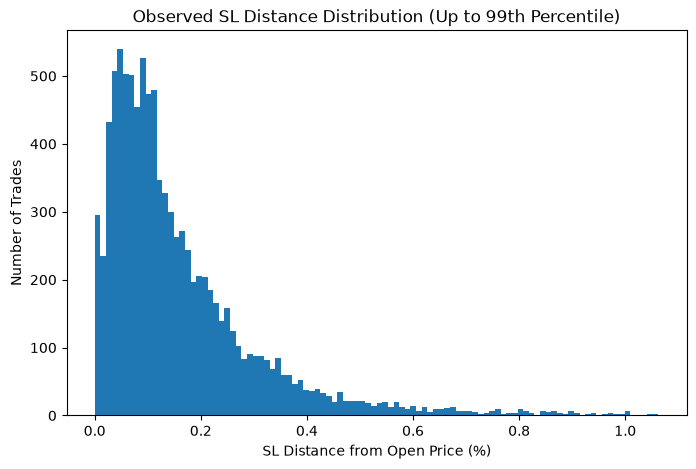

In [53]:
import matplotlib.pyplot as plt


sl_distances = (
    development_data["observed_sl_distance_pct"]
    .dropna()
    * 100
)

sl_p99 = sl_distances.quantile(0.99)

plt.figure(figsize=(8, 5))
plt.hist(
    sl_distances[sl_distances <= sl_p99],
    bins=100,
)

plt.xlabel("SL Distance from Open Price (%)")
plt.ylabel("Number of Trades")
plt.title("Observed SL Distance Distribution (Up to 99th Percentile)")
plt.show()

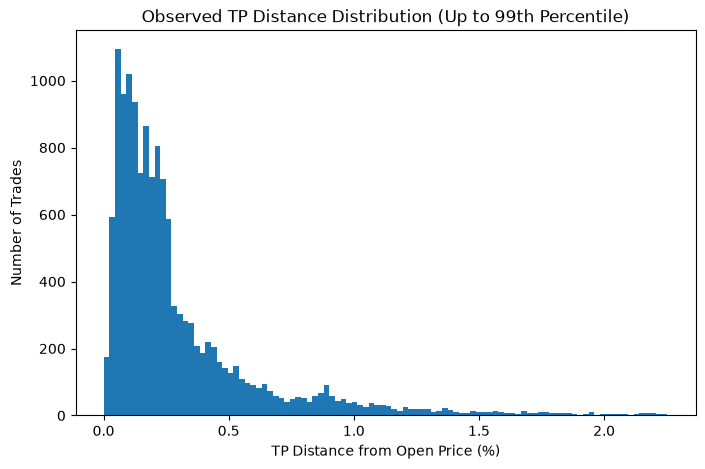

In [54]:
tp_distances = (
    development_data["observed_tp_distance_pct"]
    .dropna()
    * 100
)

tp_p99 = tp_distances.quantile(0.99)

plt.figure(figsize=(8, 5))
plt.hist(
    tp_distances[tp_distances <= tp_p99],
    bins=100,
)

plt.xlabel("TP Distance from Open Price (%)")
plt.ylabel("Number of Trades")
plt.title("Observed TP Distance Distribution (Up to 99th Percentile)")
plt.show()

### Upper-tail cutoff for clean regression target

In [55]:
sl_distance_upper_bound = (
    development_data["observed_sl_distance_pct"]
    .dropna()
    .quantile(0.99)
)

tp_distance_upper_bound = (
    development_data["observed_tp_distance_pct"]
    .dropna()
    .quantile(0.99)
)

print(
    f"SL upper bound: {sl_distance_upper_bound:.6f} "
    f"({sl_distance_upper_bound * 100:.3f}%)"
)

print(
    f"TP upper bound: {tp_distance_upper_bound:.6f} "
    f"({tp_distance_upper_bound * 100:.3f}%)"
)

SL upper bound: 0.010626 (1.063%)
TP upper bound: 0.022543 (2.254%)


In [56]:
trade_model_data["clean_sl_distance_pct"] = (
    trade_model_data["observed_sl_distance_pct"]
    .where(
        trade_model_data["observed_sl_distance_pct"]
        <= sl_distance_upper_bound
    )
)

trade_model_data["clean_tp_distance_pct"] = (
    trade_model_data["observed_tp_distance_pct"]
    .where(
        trade_model_data["observed_tp_distance_pct"]
        <= tp_distance_upper_bound
    )
)

In [57]:
sl_removed = (
    trade_model_data["observed_sl_distance_pct"].notna()
    & trade_model_data["clean_sl_distance_pct"].isna()
)

tp_removed = (
    trade_model_data["observed_tp_distance_pct"].notna()
    & trade_model_data["clean_tp_distance_pct"].isna()
)

print(
    f"SL distance observations excluded: "
    f"{sl_removed.sum():,} "
    f"({sl_removed.mean():.2%} of all trades)"
)

print(
    f"TP distance observations excluded: "
    f"{tp_removed.sum():,} "
    f"({tp_removed.mean():.2%} of all trades)"
)

SL distance observations excluded: 161 (0.35% of all trades)
TP distance observations excluded: 195 (0.42% of all trades)


### Rerun the walk-forward

In [58]:
development_data = trade_model_data.loc[
    trade_model_data["campaign_id"] <= 52
].copy()

In [59]:
sl_distance_predictions = {}

for model_name in [
    "linear_regression",
    "lightgbm",
    "xgboost",
    "catboost",
]:
    sl_distance_predictions[model_name] = (
        walk_forward_distance_model(
            data=development_data,
            feature_columns=sl_tp_distance_features,
            target_column="clean_sl_distance_pct",
            model_name=model_name,
            minimum_training_campaigns=10,
        )
    )

In [60]:
tp_distance_predictions = {}

for model_name in [
    "linear_regression",
    "lightgbm",
    "xgboost",
    "catboost",
]:
    tp_distance_predictions[model_name] = (
        walk_forward_distance_model(
            data=development_data,
            feature_columns=sl_tp_distance_features,
            target_column="clean_tp_distance_pct",
            model_name=model_name,
            minimum_training_campaigns=10,
        )
    )

In [61]:
comparison_records = []

for target_name, prediction_dict in [
    ("SL", sl_distance_predictions),
    ("TP", tp_distance_predictions),
]:
    for model_name, predictions in prediction_dict.items():
        metrics = evaluate_distance_predictions(
            predictions
        )

        comparison_records.append(
            {
                "target": target_name,
                "model": model_name,
                **metrics,
            }
        )

distance_model_comparison = pd.DataFrame(
    comparison_records
)

distance_model_comparison

,target,model,n_predictions,mae,median_absolute_error,r2
0,SL,linear_regression,5151,0.000921,0.000717,0.110047
1,SL,lightgbm,5151,0.000887,0.000624,0.115096
2,SL,xgboost,5151,0.000878,0.000630,0.129321
3,SL,catboost,5151,0.000865,0.000607,0.146239
4,TP,linear_regression,7134,0.001960,0.001525,0.139543
5,TP,lightgbm,7134,0.001700,0.000952,0.201379
6,TP,xgboost,7134,0.001731,0.000988,0.187113
7,TP,catboost,7134,0.001693,0.000971,0.215642


### Fit final SL/TP distance model

In [62]:
final_train_data = trade_model_data.loc[
    trade_model_data["campaign_id"] <= 52
].copy()

final_validation_data = trade_model_data.loc[
    trade_model_data["campaign_id"].between(53, 66)
].copy()

In [63]:
for dataset in [final_train_data, final_validation_data]:
    dataset["clean_sl_distance_pct"] = (
        dataset["observed_sl_distance_pct"]
        .where(
            dataset["observed_sl_distance_pct"]
            <= sl_distance_upper_bound
        )
    )

    dataset["clean_tp_distance_pct"] = (
        dataset["observed_tp_distance_pct"]
        .where(
            dataset["observed_tp_distance_pct"]
            <= tp_distance_upper_bound
        )
    )

In [64]:
sl_train = final_train_data.loc[
    final_train_data["clean_sl_distance_pct"].notna()
].copy()

final_sl_distance_model = build_distance_model(
    "catboost"
)

final_sl_distance_model.fit(
    sl_train[sl_tp_distance_features],
    sl_train["clean_sl_distance_pct"],
)

CatBoostRegressor(depth=6, iterations=200, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=False)

In [65]:
final_validation_data["predicted_sl_distance_pct"] = (
    final_sl_distance_model.predict(
        final_validation_data[sl_tp_distance_features]
    )
)

In [66]:
tp_train = final_train_data.loc[
    final_train_data["clean_tp_distance_pct"].notna()
].copy()

final_tp_distance_model = build_distance_model(
    "catboost"
)

final_tp_distance_model.fit(
    tp_train[sl_tp_distance_features],
    tp_train["clean_tp_distance_pct"],
)

CatBoostRegressor(depth=6, iterations=200, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=False)

In [67]:
final_validation_data["predicted_tp_distance_pct"] = (
    final_tp_distance_model.predict(
        final_validation_data[sl_tp_distance_features]
    )
)

In [68]:
sl_validation_mask = (
    final_validation_data["clean_sl_distance_pct"].notna()
)

sl_distance_validation_predictions = pd.DataFrame(
    {
        "observed_target": final_validation_data.loc[
            sl_validation_mask,
            "clean_sl_distance_pct",
        ],
        "predicted_distance": final_validation_data.loc[
            sl_validation_mask,
            "predicted_sl_distance_pct",
        ],
    }
)

sl_distance_validation_metrics = (
    evaluate_distance_predictions(
        sl_distance_validation_predictions
    )
)

In [69]:
tp_validation_mask = (
    final_validation_data["clean_tp_distance_pct"].notna()
)

tp_distance_validation_predictions = pd.DataFrame(
    {
        "observed_target": final_validation_data.loc[
            tp_validation_mask,
            "clean_tp_distance_pct",
        ],
        "predicted_distance": final_validation_data.loc[
            tp_validation_mask,
            "predicted_tp_distance_pct",
        ],
    }
)

tp_distance_validation_metrics = (
    evaluate_distance_predictions(
        tp_distance_validation_predictions
    )
)

In [70]:
print("SL distance validation")
for metric, value in sl_distance_validation_metrics.items():
    print(f"{metric}: {value:.6f}")

print("\nTP distance validation")
for metric, value in tp_distance_validation_metrics.items():
    print(f"{metric}: {value:.6f}")

SL distance validation
n_predictions: 8913.000000
mae: 0.000800
median_absolute_error: 0.000561
r2: 0.156692

TP distance validation
n_predictions: 11573.000000
mae: 0.001503
median_absolute_error: 0.000821
r2: 0.218229


# Add SL/TP features to master table

## Generate training OOF features

### Probability

In [71]:
sl_probability_oof = (
    sl_catboost_predictions[
        ["trade_row_id", "predicted_probability"]
    ]
    .rename(
        columns={
            "predicted_probability":
                "predicted_sl_probability"
        }
    )
)

tp_probability_oof = (
    tp_catboost_predictions[
        ["trade_row_id", "predicted_probability"]
    ]
    .rename(
        columns={
            "predicted_probability":
                "predicted_tp_probability"
        }
    )
)

### Distance

In [72]:
def walk_forward_distance_features(
    data,
    feature_columns,
    target_column,
    model_name,
    campaign_column="campaign_id",
    minimum_training_campaigns=10,
):
    """Generate out-of-fold distance predictions for all test trades.

    The model is trained only on historical rows with valid distance
    targets, while predictions are generated for every trade in the
    next campaign.

    Args:
        data: Trade-level DataFrame.
        feature_columns: Pre-trade predictor columns.
        target_column: Clean distance target.
        model_name: Regression model name.
        campaign_column: Campaign identifier column.
        minimum_training_campaigns: Minimum earlier campaigns required.

    Returns:
        DataFrame containing one predicted distance per eligible trade.
    """
    campaign_order = sorted(
        data[campaign_column].dropna().unique()
    )

    prediction_records = []

    for campaign_index, test_campaign in enumerate(campaign_order):
        training_campaigns = campaign_order[:campaign_index]

        if len(training_campaigns) < minimum_training_campaigns:
            continue

        train = data.loc[
            data[campaign_column].isin(training_campaigns)
            & data[target_column].notna()
        ].copy()

        test = data.loc[
            data[campaign_column] == test_campaign
        ].copy()

        if train.empty or test.empty:
            continue

        model = build_distance_model(model_name)

        model.fit(
            train[feature_columns],
            train[target_column],
        )

        predictions = test[
            ["trade_row_id"]
        ].copy()

        predictions["predicted_distance"] = (
            model.predict(
                test[feature_columns]
            )
        )

        prediction_records.append(predictions)

    return pd.concat(
        prediction_records,
        ignore_index=True,
    )

In [73]:
training_data = trade_model_data.loc[
    trade_model_data["campaign_id"] <= 52
].copy()

In [74]:
sl_distance_oof = walk_forward_distance_features(
    data=training_data,
    feature_columns=sl_tp_distance_features,
    target_column="clean_sl_distance_pct",
    model_name="catboost",
    minimum_training_campaigns=10,
)

sl_distance_oof = sl_distance_oof.rename(
    columns={
        "predicted_distance":
            "predicted_sl_distance_pct"
    }
)

In [75]:
tp_distance_oof = walk_forward_distance_features(
    data=training_data,
    feature_columns=sl_tp_distance_features,
    target_column="clean_tp_distance_pct",
    model_name="catboost",
    minimum_training_campaigns=10,
)

tp_distance_oof = tp_distance_oof.rename(
    columns={
        "predicted_distance":
            "predicted_tp_distance_pct"
    }
)

## Generate validation features

In [76]:
validation_features = trade_model_data.loc[
    trade_model_data["campaign_id"].between(53, 66)
].copy()

### Probability

In [77]:
final_sl_probability_model = build_probability_model(
    "catboost"
)

final_sl_probability_model.fit(
    training_data[sl_tp_probability_features],
    training_data["observed_has_sl"],
)

CatBoostClassifier(depth=6, iterations=200, learning_rate=0.05, random_seed=42, verbose=False)

In [78]:
final_tp_probability_model = build_probability_model(
    "catboost"
)

final_tp_probability_model.fit(
    training_data[sl_tp_probability_features],
    training_data["observed_has_tp"],
)

CatBoostClassifier(depth=6, iterations=200, learning_rate=0.05, random_seed=42, verbose=False)

In [79]:
validation_features["predicted_sl_probability"] = (
    final_sl_probability_model.predict_proba(
        validation_features[
            sl_tp_probability_features
        ]
    )[:, 1]
)

validation_features["predicted_tp_probability"] = (
    final_tp_probability_model.predict_proba(
        validation_features[
            sl_tp_probability_features
        ]
    )[:, 1]
)

### Distance

In [80]:
sl_distance_train = training_data.loc[
    training_data["clean_sl_distance_pct"].notna()
]

final_sl_distance_model = build_distance_model(
    "catboost"
)

final_sl_distance_model.fit(
    sl_distance_train[sl_tp_distance_features],
    sl_distance_train["clean_sl_distance_pct"],
)

CatBoostRegressor(depth=6, iterations=200, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=False)

In [81]:
tp_distance_train = training_data.loc[
    training_data["clean_tp_distance_pct"].notna()
]

final_tp_distance_model = build_distance_model(
    "catboost"
)

final_tp_distance_model.fit(
    tp_distance_train[sl_tp_distance_features],
    tp_distance_train["clean_tp_distance_pct"],
)

CatBoostRegressor(depth=6, iterations=200, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=False)

In [82]:
validation_features["predicted_sl_distance_pct"] = (
    final_sl_distance_model.predict(
        validation_features[
            sl_tp_distance_features
        ]
    )
)

validation_features["predicted_tp_distance_pct"] = (
    final_tp_distance_model.predict(
        validation_features[
            sl_tp_distance_features
        ]
    )
)

## Merge everything into trade_model_data

In [83]:
training_predicted_features = (
    sl_probability_oof
    .merge(
        tp_probability_oof,
        on="trade_row_id",
        validate="one_to_one",
    )
    .merge(
        sl_distance_oof,
        on="trade_row_id",
        validate="one_to_one",
    )
    .merge(
        tp_distance_oof,
        on="trade_row_id",
        validate="one_to_one",
    )
)

In [84]:
predicted_sl_tp_columns = [
    "predicted_sl_probability",
    "predicted_tp_probability",
    "predicted_sl_distance_pct",
    "predicted_tp_distance_pct",
]

validation_predicted_features = (
    validation_features[
        ["trade_row_id"] + predicted_sl_tp_columns
    ]
    .copy()
)

In [85]:
predicted_features = pd.concat(
    [
        training_predicted_features,
        validation_predicted_features,
    ],
    ignore_index=True,
)

In [86]:
trade_model_data = trade_model_data.merge(
    predicted_features,
    on="trade_row_id",
    how="left",
    validate="one_to_one",
)

# Create modelling table

In [87]:
predicted_sl_tp_columns = [
    "predicted_sl_probability",
    "predicted_tp_probability",
    "predicted_sl_distance_pct",
    "predicted_tp_distance_pct",
]

predicted_sl_tp_prob_columns = [
    "predicted_sl_probability",
    "predicted_tp_probability",
]

predicted_sl_tp_dist_columns = [
    "predicted_sl_distance_pct",
    "predicted_tp_distance_pct",
]

In [88]:
full_sl_tp_feature_columns = (
    available_feature_columns
    + predicted_sl_tp_columns
)

prob_only_feature_columns = (
    available_feature_columns
    + predicted_sl_tp_prob_columns
)

base_feature_columns = (
    available_feature_columns.copy()
)

full_sl_tp_feature_columns = list(
    dict.fromkeys(full_sl_tp_feature_columns)
)

prob_only_feature_columns = list(
    dict.fromkeys(prob_only_feature_columns)
)

base_feature_columns = list(
    dict.fromkeys(base_feature_columns)
)

In [89]:
identifier_columns = [
    "trade_row_id",
    "campaign_id",
    "account_id",
    "idea_id",
    "open_date_time",
    "close_date_time",
]

target_column = "reverse_profit_per_lot"

## Base features

In [90]:
base_model_columns = (
    identifier_columns
    + evaluation_columns
    + base_feature_columns
    + [target_column]
)

base_model_columns = list(
    dict.fromkeys(base_model_columns)
)

base_model_data = (
    trade_model_data[base_model_columns]
    .copy()
    .sort_values(
        [
            "campaign_id",
            "account_id",
            "open_date_time",
            "trade_row_id",
        ]
    )
    .reset_index(drop=True)
)

In [91]:
print(f"Modelling rows: {len(base_model_data):,}")
print(f"Predictor columns: {len(base_feature_columns)}")

Modelling rows: 46,520
Predictor columns: 40


## Base + full SL/TP features

In [92]:
full_sl_tp_model_columns = (
    identifier_columns
    + evaluation_columns
    + full_sl_tp_feature_columns
    + [target_column]
)

full_sl_tp_model_columns = list(
    dict.fromkeys(full_sl_tp_model_columns)
)

full_sl_tp_model_data = (
    trade_model_data[
        full_sl_tp_model_columns
    ]
    .copy()
    .sort_values(
        [
            "campaign_id",
            "account_id",
            "open_date_time",
            "trade_row_id",
        ]
    )
    .reset_index(drop=True)
)

In [93]:
print(f"Modelling rows: {len(full_sl_tp_model_data):,}")
print(f"Predictor columns: {len(full_sl_tp_feature_columns)}")

Modelling rows: 46,520
Predictor columns: 44


## Base + SL/TP probability features

In [94]:
prob_model_columns = (
    identifier_columns
    + evaluation_columns
    + prob_only_feature_columns
    + [target_column]
)

prob_model_columns = list(
    dict.fromkeys(prob_model_columns)
)

prob_model_data = (
    trade_model_data[
        prob_model_columns
    ]
    .copy()
    .sort_values(
        [
            "campaign_id",
            "account_id",
            "open_date_time",
            "trade_row_id",
        ]
    )
    .reset_index(drop=True)
)

In [95]:
print(f"Modelling rows: {len(prob_model_data):,}")
print(f"Predictor columns: {len(prob_only_feature_columns)}")

Modelling rows: 46,520
Predictor columns: 42


# Create train/validation split

## Train/validation split

In [96]:
base_train_data = (
    base_model_data.loc[
        base_model_data["campaign_id"] <= 52
    ]
    .copy()
    .reset_index(drop=True)
)

base_validation_data = (
    base_model_data.loc[
        base_model_data["campaign_id"].between(
            53,
            66,
        )
    ]
    .copy()
    .reset_index(drop=True)
)


full_sl_tp_train_data = (
    full_sl_tp_model_data.loc[
        full_sl_tp_model_data["campaign_id"] <= 52
    ]
    .copy()
    .reset_index(drop=True)
)

full_sl_tp_validation_data = (
    full_sl_tp_model_data.loc[
        full_sl_tp_model_data[
            "campaign_id"
        ].between(
            53,
            66,
        )
    ]
    .copy()
    .reset_index(drop=True)
)


prob_train_data = (
    prob_model_data.loc[
        prob_model_data["campaign_id"] <= 52
    ]
    .copy()
    .reset_index(drop=True)
)

prob_validation_data = (
    prob_model_data.loc[
        prob_model_data["campaign_id"].between(
            53,
            66,
        )
    ]
    .copy()
    .reset_index(drop=True)
)

In [97]:
base_train_data = (
    base_train_data
    .copy()
    .reset_index(drop=True)
)

In [98]:
full_sl_tp_train_data = (
    full_sl_tp_train_data.dropna(
        subset=predicted_sl_tp_columns
    )
    .reset_index(drop=True)
)

In [99]:
prob_train_data = (
    prob_train_data.dropna(
        subset=predicted_sl_tp_prob_columns
    )
    .reset_index(drop=True)
)

In [100]:
assert not full_sl_tp_validation_data[
    predicted_sl_tp_columns
].isna().any().any()

assert not prob_validation_data[
    predicted_sl_tp_prob_columns
].isna().any().any()

In [101]:
modelling_splits = {
    "base": (
        base_train_data,
        base_validation_data,
    ),
    "full_sl_tp": (
        full_sl_tp_train_data,
        full_sl_tp_validation_data,
    ),
    "prob_only": (
        prob_train_data,
        prob_validation_data,
    ),
}

for split_name, (
    train_split,
    validation_split,
) in modelling_splits.items():

    print(f"\n{split_name.upper()}")

    print(
        f"Training trades: "
        f"{len(train_split):,}"
    )

    print(
        f"Validation trades: "
        f"{len(validation_split):,}"
    )

    print(
        "Training campaigns:",
        sorted(
            train_split[
                "campaign_id"
            ].unique()
        ),
    )

    print(
        "Validation campaigns:",
        sorted(
            validation_split[
                "campaign_id"
            ].unique()
        ),
    )


BASE
Training trades: 25,165
Validation trades: 21,355
Training campaigns: [np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52)]
Validation campaigns: [np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66)]

FULL_SL_TP
Training trades: 12,771
Validation trades: 21,355
Training campaigns: [np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52)]
Validation campaigns: [np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(6

# Modelling framework

In [102]:
from catboost import (
    CatBoostClassifier,
    CatBoostRegressor,
)
from lightgbm import (
    LGBMClassifier,
    LGBMRegressor,
)
from xgboost import (
    XGBClassifier,
    XGBRegressor,
)

from sklearn.ensemble import (
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import (
    ElasticNet,
    HuberRegressor,
    LogisticRegression,
    Ridge,
)
from sklearn.neural_network import (
    MLPClassifier,
    MLPRegressor,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    RobustScaler,
    StandardScaler,
)
from sklearn.svm import (
    SVC,
    SVR,
)

## Classification models

In [103]:
def build_classifier(model_name):
    """Build a candidate classification model.

    Args:
        model_name: Name of the classifier.

    Returns:
        Configured classification model.
    """
    if model_name == "logistic_regression":
        return Pipeline(
            [
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    LogisticRegression(
                        max_iter=2000,
                        random_state=42,
                    ),
                ),
            ]
        )

    if model_name == "random_forest":
        return RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=20,
            random_state=42,
            n_jobs=-1,
        )

    if model_name == "extra_trees":
        return ExtraTreesClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=20,
            random_state=42,
            n_jobs=-1,
        )

    if model_name == "hist_gradient_boosting":
        return HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=200,
            max_leaf_nodes=15,
            l2_regularization=1.0,
            random_state=42,
        )

    if model_name == "lightgbm":
        return LGBMClassifier(
            n_estimators=200,
            learning_rate=0.05,
            num_leaves=15,
            random_state=42,
            verbosity=-1,
        )

    if model_name == "xgboost":
        return XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss",
        )

    if model_name == "catboost":
        return CatBoostClassifier(
            iterations=200,
            learning_rate=0.05,
            depth=6,
            random_seed=42,
            verbose=False,
        )

    if model_name == "svm":
        return Pipeline(
            [
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    SVC(
                        kernel="rbf",
                        C=1.0,
                        probability=True,
                        random_state=42,
                    ),
                ),
            ]
        )

    if model_name == "mlp":
        return Pipeline(
            [
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    MLPClassifier(
                        hidden_layer_sizes=(64, 32),
                        activation="relu",
                        alpha=0.001,
                        learning_rate_init=0.001,
                        early_stopping=True,
                        max_iter=300,
                        random_state=42,
                    ),
                ),
            ]
        )

    raise ValueError(
        f"Unknown classifier: {model_name}"
    )

## Regression models

In [104]:
def build_regressor(model_name):
    """Build a candidate regression model.

    Args:
        model_name: Name of the regressor.

    Returns:
        Configured regression model.
    """
    if model_name == "ridge":
        return Pipeline(
            [
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    Ridge(alpha=1.0),
                ),
            ]
        )

    if model_name == "elastic_net":
        return Pipeline(
            [
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    ElasticNet(
                        alpha=1.0,
                        l1_ratio=0.5,
                        max_iter=5000,
                        random_state=42,
                    ),
                ),
            ]
        )

    if model_name == "huber":
        return Pipeline(
            [
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    RobustScaler(),
                ),
                (
                    "model",
                    HuberRegressor(
                        epsilon=1.35,
                        max_iter=1000,
                    ),
                ),
            ]
        )

    if model_name == "random_forest":
        return RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=20,
            random_state=42,
            n_jobs=-1,
        )

    if model_name == "extra_trees":
        return ExtraTreesRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=20,
            random_state=42,
            n_jobs=-1,
        )

    if model_name == "hist_gradient_boosting":
        return HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_iter=200,
            max_leaf_nodes=15,
            l2_regularization=1.0,
            random_state=42,
        )

    if model_name == "lightgbm":
        return LGBMRegressor(
            n_estimators=200,
            learning_rate=0.05,
            num_leaves=15,
            random_state=42,
            verbosity=-1,
        )

    if model_name == "xgboost":
        return XGBRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
            n_jobs=-1,
        )

    if model_name == "catboost":
        return CatBoostRegressor(
            iterations=200,
            learning_rate=0.05,
            depth=6,
            random_seed=42,
            verbose=False,
        )

    if model_name == "svr":
        return Pipeline(
            [
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    SVR(
                        kernel="rbf",
                        C=1.0,
                        epsilon=0.1,
                    ),
                ),
            ]
        )

    if model_name == "mlp":
        return Pipeline(
            [
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    MLPRegressor(
                        hidden_layer_sizes=(64, 32),
                        activation="relu",
                        alpha=0.001,
                        learning_rate_init=0.001,
                        early_stopping=True,
                        max_iter=300,
                        random_state=42,
                    ),
                ),
            ]
        )

    raise ValueError(
        f"Unknown regressor: {model_name}"
    )

## Quantile regression models

In [105]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [106]:
def build_quantile_regressor(
    model_name,
    target_quantile,
):
    """Build a regression model using quantile loss."""

    if model_name == "gradient_boosting":
        return Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    ),
                ),
                (
                    "model",
                    GradientBoostingRegressor(
                        loss="quantile",
                        alpha=target_quantile,
                        n_estimators=200,
                        learning_rate=0.05,
                        max_depth=3,
                        min_samples_leaf=20,
                        random_state=RANDOM_SEED,
                    ),
                ),
            ]
        )

    if model_name == "hist_gradient_boosting":
        return HistGradientBoostingRegressor(
            loss="quantile",
            quantile=target_quantile,
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=15,
            min_samples_leaf=20,
            l2_regularization=1.0,
            random_state=RANDOM_SEED,
        )

    if model_name == "lightgbm":
        return LGBMRegressor(
            objective="quantile",
            alpha=target_quantile,
            n_estimators=200,
            learning_rate=0.05,
            num_leaves=15,
            min_child_samples=20,
            random_state=RANDOM_SEED,
            verbosity=-1,
        )

    if model_name == "catboost":
        return CatBoostRegressor(
            loss_function=(
                f"Quantile:alpha="
                f"{target_quantile}"
            ),
            iterations=200,
            learning_rate=0.05,
            depth=6,
            random_seed=RANDOM_SEED,
            verbose=False,
        )

    raise ValueError(
        f"Unknown quantile model: "
        f"{model_name}"
    )

## Candidate model lists

In [107]:
classification_model_names = [
    "logistic_regression",
    "random_forest",
    "extra_trees",
    "hist_gradient_boosting",
    "lightgbm",
    "xgboost",
    "catboost",
    "svm",
    "mlp",
]

regression_model_names = [
    "ridge",
    "elastic_net",
    "huber",
    "random_forest",
    "extra_trees",
    "hist_gradient_boosting",
    "lightgbm",
    "xgboost",
    "catboost",
    "svr",
    "mlp",
]

## Walk-forward functions

In [108]:
def walk_forward_classifier(
    data,
    feature_columns,
    target_column,
    model_name,
    minimum_training_campaigns,
    campaign_column="campaign_id",
):
    """Generate walk-forward classification predictions.

    Args:
        data: Development modelling data.
        feature_columns: Predictor columns.
        target_column: Binary target column.
        model_name: Classification model name.
        minimum_training_campaigns: Minimum number of earlier
            campaigns required before evaluation.
        campaign_column: Campaign identifier column.

    Returns:
        DataFrame containing walk-forward probabilities and outcomes.
    """
    campaigns = sorted(
        data[campaign_column].unique()
    )

    predictions = []

    for test_index in range(
        minimum_training_campaigns,
        len(campaigns),
    ):
        test_campaign = campaigns[test_index]

        training_campaigns = campaigns[
            :test_index
        ]

        train = data.loc[
            data[campaign_column].isin(
                training_campaigns
            )
        ].copy()

        test = data.loc[
            data[campaign_column]
            == test_campaign
        ].copy()

        model = build_classifier(model_name)

        model.fit(
            train[feature_columns],
            train[target_column],
        )

        test_prediction = test[
            [
                "trade_row_id",
                "campaign_id",
                "account_id",
                "amount",
                "reverse_profit",
                "reverse_profit_per_lot",
                target_column,
            ]
        ].copy()

        test_prediction[
            "predicted_probability"
        ] = model.predict_proba(
            test[feature_columns]
        )[:, 1]

        test_prediction[
            "model_name"
        ] = model_name

        predictions.append(
            test_prediction
        )

    return pd.concat(
        predictions,
        ignore_index=True,
    )

In [109]:
def walk_forward_regressor(
    data,
    feature_columns,
    target_column,
    model_name,
    minimum_training_campaigns,
    campaign_column="campaign_id",
):
    """Generate walk-forward regression predictions.

    Args:
        data: Development modelling data.
        feature_columns: Predictor columns.
        target_column: Continuous regression target.
        model_name: Regression model name.
        minimum_training_campaigns: Minimum number of earlier
            campaigns required before evaluation.
        campaign_column: Campaign identifier column.

    Returns:
        DataFrame containing walk-forward predictions and outcomes.
    """
    campaigns = sorted(
        data[campaign_column].unique()
    )

    predictions = []

    for test_index in range(
        minimum_training_campaigns,
        len(campaigns),
    ):
        test_campaign = campaigns[test_index]

        training_campaigns = campaigns[
            :test_index
        ]

        train = data.loc[
            data[campaign_column].isin(
                training_campaigns
            )
        ].copy()

        test = data.loc[
            data[campaign_column]
            == test_campaign
        ].copy()

        model = build_regressor(model_name)

        model.fit(
            train[feature_columns],
            train[target_column],
        )

        test_prediction = test[
            [
                "trade_row_id",
                "campaign_id",
                "account_id",
                "amount",
                "reverse_profit",
                "reverse_profit_per_lot",
            ]
        ].copy()

        test_prediction[
            "predicted_reverse_profit_per_lot"
        ] = model.predict(
            test[feature_columns]
        )

        test_prediction[
            "model_name"
        ] = model_name

        predictions.append(
            test_prediction
        )

    return pd.concat(
        predictions,
        ignore_index=True,
    )

In [110]:
def walk_forward_expected_value(
    data,
    feature_columns,
    classification_target_column,
    regression_target_column,
    model_family,
    minimum_training_campaigns,
    campaign_column="campaign_id",
):
    """Generate walk-forward expected-value predictions.

    The expected-value model consists of:
        1. A classifier estimating the probability of
           a profitable fade.
        2. A regressor estimating payoff conditional on
           a profitable fade.
        3. A regressor estimating payoff conditional on
           a non-profitable fade.

    Args:
        data: Modelling DataFrame.
        feature_columns: Pre-trade predictor columns.
        classification_target_column: Binary fade target.
        regression_target_column: Continuous fade payoff target.
        model_family: Model family used for all three models.
        minimum_training_campaigns: Minimum number of historical
            campaigns required before prediction.
        campaign_column: Campaign identifier column.

    Returns:
        DataFrame containing walk-forward expected-value
        predictions.
    """
    model_pairs = {
        "random_forest": (
            "random_forest",
            "random_forest",
        ),
        "extra_trees": (
            "extra_trees",
            "extra_trees",
        ),
        "hist_gradient_boosting": (
            "hist_gradient_boosting",
            "hist_gradient_boosting",
        ),
        "lightgbm": (
            "lightgbm",
            "lightgbm",
        ),
        "xgboost": (
            "xgboost",
            "xgboost",
        ),
        "catboost": (
            "catboost",
            "catboost",
        ),
        "mlp": (
            "mlp",
            "mlp",
        ),
    }

    if model_family not in model_pairs:
        raise ValueError(
            f"Unsupported model family: "
            f"{model_family}"
        )

    (
        classifier_name,
        regressor_name,
    ) = model_pairs[model_family]

    campaigns = sorted(
        data[campaign_column]
        .dropna()
        .unique()
    )

    predictions = []

    for campaign_index, test_campaign in enumerate(
        campaigns
    ):
        if (
            campaign_index
            < minimum_training_campaigns
        ):
            continue

        training_campaigns = campaigns[
            :campaign_index
        ]

        train = data.loc[
            data[campaign_column].isin(
                training_campaigns
            )
        ].copy()

        test = data.loc[
            data[campaign_column]
            == test_campaign
        ].copy()

        positive_train = train.loc[
            train[
                classification_target_column
            ] == 1
        ].copy()

        negative_train = train.loc[
            train[
                classification_target_column
            ] == 0
        ].copy()

        classifier = build_classifier(
            classifier_name
        )

        positive_regressor = build_regressor(
            regressor_name
        )

        negative_regressor = build_regressor(
            regressor_name
        )

        classifier.fit(
            train[feature_columns],
            train[
                classification_target_column
            ],
        )

        positive_regressor.fit(
            positive_train[
                feature_columns
            ],
            positive_train[
                regression_target_column
            ],
        )

        negative_regressor.fit(
            negative_train[
                feature_columns
            ],
            negative_train[
                regression_target_column
            ],
        )

        profitable_probability = (
            classifier.predict_proba(
                test[feature_columns]
            )[:, 1]
        )

        predicted_positive_payoff = (
            positive_regressor.predict(
                test[feature_columns]
            )
        )

        predicted_negative_payoff = (
            negative_regressor.predict(
                test[feature_columns]
            )
        )

        predicted_positive_payoff = (
            np.maximum(
                predicted_positive_payoff,
                0.0,
            )
        )

        predicted_negative_payoff = (
            np.minimum(
                predicted_negative_payoff,
                0.0,
            )
        )

        predicted_expected_value = (
            profitable_probability
            * predicted_positive_payoff
            + (
                1.0
                - profitable_probability
            )
            * predicted_negative_payoff
        )

        test_prediction = test[
            [
                "trade_row_id",
                "campaign_id",
                "account_id",
                "amount",
                "reverse_profit",
                "reverse_profit_per_lot",
                classification_target_column,
            ]
        ].copy()

        test_prediction[
            "predicted_profitable_probability"
        ] = profitable_probability

        test_prediction[
            "predicted_positive_payoff"
        ] = predicted_positive_payoff

        test_prediction[
            "predicted_negative_payoff"
        ] = predicted_negative_payoff

        test_prediction[
            "predicted_expected_value"
        ] = predicted_expected_value

        test_prediction[
            "model_family"
        ] = model_family

        predictions.append(
            test_prediction
        )

    return pd.concat(
        predictions,
        ignore_index=True,
    )

In [111]:
def walk_forward_expected_value_winsorized(
    data,
    feature_columns,
    classification_target_column,
    regression_target_column,
    model_family,
    minimum_training_campaigns,
    lower_quantile=0.01,
    upper_quantile=0.99,
    campaign_column="campaign_id",
):
    """Generate winsorized walk-forward EV predictions.

    Winsorization bounds are fitted using only the
    training campaigns within each fold.

    Args:
        data: Modelling DataFrame.
        feature_columns: Pre-trade predictor columns.
        classification_target_column: Binary fade target.
        regression_target_column: Continuous fade payoff.
        model_family: Model family used by all components.
        minimum_training_campaigns: Minimum historical
            campaigns before prediction.
        lower_quantile: Lower winsorization quantile.
        upper_quantile: Upper winsorization quantile.
        campaign_column: Campaign identifier.

    Returns:
        DataFrame containing walk-forward expected-value
        predictions.
    """
    model_pairs = {
        "random_forest": (
            "random_forest",
            "random_forest",
        ),
        "extra_trees": (
            "extra_trees",
            "extra_trees",
        ),
        "hist_gradient_boosting": (
            "hist_gradient_boosting",
            "hist_gradient_boosting",
        ),
        "lightgbm": (
            "lightgbm",
            "lightgbm",
        ),
        "xgboost": (
            "xgboost",
            "xgboost",
        ),
        "catboost": (
            "catboost",
            "catboost",
        ),
        "mlp": (
            "mlp",
            "mlp",
        ),
    }

    if model_family not in model_pairs:
        raise ValueError(
            f"Unsupported model family: "
            f"{model_family}"
        )

    (
        classifier_name,
        regressor_name,
    ) = model_pairs[
        model_family
    ]

    campaigns = sorted(
        data[
            campaign_column
        ]
        .dropna()
        .unique()
    )

    predictions = []

    for campaign_index, test_campaign in enumerate(
        campaigns
    ):
        if (
            campaign_index
            < minimum_training_campaigns
        ):
            continue

        training_campaigns = campaigns[
            :campaign_index
        ]

        train = data.loc[
            data[
                campaign_column
            ].isin(
                training_campaigns
            )
        ].copy()

        test = data.loc[
            data[
                campaign_column
            ] == test_campaign
        ].copy()

        # Fit winsorization bounds using
        # training campaigns only.
        winsorization_bounds = (
            fit_winsorization_bounds(
                data=train,
                feature_columns=(
                    feature_columns
                ),
                lower_quantile=(
                    lower_quantile
                ),
                upper_quantile=(
                    upper_quantile
                ),
            )
        )

        # Apply the same bounds to both
        # training and current test campaign.
        train = apply_winsorization(
            data=train,
            bounds=winsorization_bounds,
        )

        test = apply_winsorization(
            data=test,
            bounds=winsorization_bounds,
        )

        positive_train = train.loc[
            train[
                classification_target_column
            ] == 1
        ].copy()

        negative_train = train.loc[
            train[
                classification_target_column
            ] == 0
        ].copy()

        classifier = build_classifier(
            classifier_name
        )

        positive_regressor = build_regressor(
            regressor_name
        )

        negative_regressor = build_regressor(
            regressor_name
        )

        classifier.fit(
            train[
                feature_columns
            ],
            train[
                classification_target_column
            ],
        )

        positive_regressor.fit(
            positive_train[
                feature_columns
            ],
            positive_train[
                regression_target_column
            ],
        )

        negative_regressor.fit(
            negative_train[
                feature_columns
            ],
            negative_train[
                regression_target_column
            ],
        )

        profitable_probability = (
            classifier.predict_proba(
                test[
                    feature_columns
                ]
            )[:, 1]
        )

        predicted_positive_payoff = (
            positive_regressor.predict(
                test[
                    feature_columns
                ]
            )
        )

        predicted_negative_payoff = (
            negative_regressor.predict(
                test[
                    feature_columns
                ]
            )
        )

        predicted_positive_payoff = (
            np.maximum(
                predicted_positive_payoff,
                0.0,
            )
        )

        predicted_negative_payoff = (
            np.minimum(
                predicted_negative_payoff,
                0.0,
            )
        )

        predicted_expected_value = (
            profitable_probability
            * predicted_positive_payoff
            + (
                1.0
                - profitable_probability
            )
            * predicted_negative_payoff
        )

        test_prediction = test[
            [
                "trade_row_id",
                "campaign_id",
                "account_id",
                "amount",
                "reverse_profit",
                "reverse_profit_per_lot",
                classification_target_column,
            ]
        ].copy()

        test_prediction[
            "predicted_profitable_probability"
        ] = profitable_probability

        test_prediction[
            "predicted_positive_payoff"
        ] = predicted_positive_payoff

        test_prediction[
            "predicted_negative_payoff"
        ] = predicted_negative_payoff

        test_prediction[
            "predicted_expected_value"
        ] = predicted_expected_value

        test_prediction[
            "model_family"
        ] = model_family

        predictions.append(
            test_prediction
        )

    return pd.concat(
        predictions,
        ignore_index=True,
    )

In [112]:
def walk_forward_expected_value_target_clipped(
    data,
    feature_columns,
    classification_target_column,
    regression_target_column,
    model_family,
    minimum_training_campaigns,
    positive_upper_quantile=0.99,
    negative_lower_quantile=0.01,
    campaign_column="campaign_id",
):
    """Generate walk-forward EV predictions with target clipping.

    Target clipping bounds are fitted using only the training
    campaigns within each fold.

    Args:
        data: Modelling DataFrame.
        feature_columns: Pre-trade predictor columns.
        classification_target_column: Binary fade target.
        regression_target_column: Continuous fade payoff target.
        model_family: Model family used by all model components.
        minimum_training_campaigns: Minimum historical campaigns
            required before prediction.
        positive_upper_quantile: Upper clipping quantile for
            positive payoff targets.
        negative_lower_quantile: Lower clipping quantile for
            negative payoff targets.
        campaign_column: Campaign identifier.

    Returns:
        DataFrame containing walk-forward expected-value predictions.
    """
    model_pairs = {
        "random_forest": (
            "random_forest",
            "random_forest",
        ),
        "extra_trees": (
            "extra_trees",
            "extra_trees",
        ),
        "hist_gradient_boosting": (
            "hist_gradient_boosting",
            "hist_gradient_boosting",
        ),
        "lightgbm": (
            "lightgbm",
            "lightgbm",
        ),
        "xgboost": (
            "xgboost",
            "xgboost",
        ),
        "catboost": (
            "catboost",
            "catboost",
        ),
        "mlp": (
            "mlp",
            "mlp",
        ),
    }

    if model_family not in model_pairs:
        raise ValueError(
            f"Unsupported model family: {model_family}"
        )

    (
        classifier_name,
        regressor_name,
    ) = model_pairs[model_family]

    campaigns = sorted(
        data[campaign_column]
        .dropna()
        .unique()
    )

    predictions = []

    for campaign_index, test_campaign in enumerate(
        campaigns
    ):
        if (
            campaign_index
            < minimum_training_campaigns
        ):
            continue

        training_campaigns = campaigns[
            :campaign_index
        ]

        train = data.loc[
            data[campaign_column].isin(
                training_campaigns
            )
        ].copy()

        test = data.loc[
            data[campaign_column]
            == test_campaign
        ].copy()

        target_bounds = (
            fit_conditional_target_bounds(
                data=train,
                classification_target_column=(
                    classification_target_column
                ),
                regression_target_column=(
                    regression_target_column
                ),
                positive_upper_quantile=(
                    positive_upper_quantile
                ),
                negative_lower_quantile=(
                    negative_lower_quantile
                ),
            )
        )

        positive_train = train.loc[
            train[
                classification_target_column
            ] == 1
        ].copy()

        negative_train = train.loc[
            train[
                classification_target_column
            ] == 0
        ].copy()

        positive_train[
            "clipped_regression_target"
        ] = (
            positive_train[
                regression_target_column
            ].clip(
                upper=target_bounds[
                    "positive_upper_bound"
                ]
            )
        )

        negative_train[
            "clipped_regression_target"
        ] = (
            negative_train[
                regression_target_column
            ].clip(
                lower=target_bounds[
                    "negative_lower_bound"
                ]
            )
        )

        classifier = build_classifier(
            classifier_name
        )

        positive_regressor = build_regressor(
            regressor_name
        )

        negative_regressor = build_regressor(
            regressor_name
        )

        classifier.fit(
            train[
                feature_columns
            ],
            train[
                classification_target_column
            ],
        )

        positive_regressor.fit(
            positive_train[
                feature_columns
            ],
            positive_train[
                "clipped_regression_target"
            ],
        )

        negative_regressor.fit(
            negative_train[
                feature_columns
            ],
            negative_train[
                "clipped_regression_target"
            ],
        )

        profitable_probability = (
            classifier.predict_proba(
                test[
                    feature_columns
                ]
            )[:, 1]
        )

        predicted_positive_payoff = (
            positive_regressor.predict(
                test[
                    feature_columns
                ]
            )
        )

        predicted_negative_payoff = (
            negative_regressor.predict(
                test[
                    feature_columns
                ]
            )
        )

        predicted_positive_payoff = (
            np.maximum(
                predicted_positive_payoff,
                0.0,
            )
        )

        predicted_negative_payoff = (
            np.minimum(
                predicted_negative_payoff,
                0.0,
            )
        )

        predicted_expected_value = (
            profitable_probability
            * predicted_positive_payoff
            + (
                1.0
                - profitable_probability
            )
            * predicted_negative_payoff
        )

        test_prediction = test[
            [
                "trade_row_id",
                "campaign_id",
                "account_id",
                "amount",
                "reverse_profit",
                "reverse_profit_per_lot",
                classification_target_column,
            ]
        ].copy()

        test_prediction[
            "predicted_profitable_probability"
        ] = profitable_probability

        test_prediction[
            "predicted_positive_payoff"
        ] = predicted_positive_payoff

        test_prediction[
            "predicted_negative_payoff"
        ] = predicted_negative_payoff

        test_prediction[
            "predicted_expected_value"
        ] = predicted_expected_value

        test_prediction[
            "model_family"
        ] = model_family

        predictions.append(
            test_prediction
        )

    return pd.concat(
        predictions,
        ignore_index=True,
    )

In [113]:
def walk_forward_regressor_winsorized(
    data,
    feature_columns,
    target_column,
    model_name,
    minimum_training_campaigns,
    lower_quantile=0.01,
    upper_quantile=0.99,
    campaign_column="campaign_id",
):
    """Generate walk-forward regression predictions with feature winsorization."""

    campaigns = sorted(
        data[
            campaign_column
        ].dropna().unique()
    )

    prediction_frames = []

    for test_index in range(
        minimum_training_campaigns,
        len(campaigns),
    ):
        test_campaign = (
            campaigns[test_index]
        )

        training_campaigns = (
            campaigns[:test_index]
        )

        train_data = (
            data.loc[
                data[
                    campaign_column
                ].isin(
                    training_campaigns
                )
            ]
            .copy()
        )

        test_data = (
            data.loc[
                data[
                    campaign_column
                ]
                == test_campaign
            ]
            .copy()
        )

        winsorization_bounds = (
            fit_winsorization_bounds(
                data=train_data,
                feature_columns=(
                    feature_columns
                ),
                lower_quantile=(
                    lower_quantile
                ),
                upper_quantile=(
                    upper_quantile
                ),
            )
        )

        transformed_train = (
            apply_winsorization(
                train_data,
                winsorization_bounds,
            )
        )

        transformed_test = (
            apply_winsorization(
                test_data,
                winsorization_bounds,
            )
        )

        model = build_regressor(
            model_name
        )

        model.fit(
            transformed_train[
                feature_columns
            ],
            transformed_train[
                target_column
            ],
        )

        predictions = model.predict(
            transformed_test[
                feature_columns
            ]
        )

        fold_predictions = (
            test_data[
                [
                    "trade_row_id",
                    "campaign_id",
                    "account_id",
                    "amount",
                    "reverse_profit",
                    "reverse_profit_per_lot",
                ]
            ]
            .copy()
        )

        fold_predictions[
            "predicted_reverse_profit_per_lot"
        ] = predictions

        prediction_frames.append(
            fold_predictions
        )

    return pd.concat(
        prediction_frames,
        ignore_index=True,
    )

In [114]:
def walk_forward_regressor_target_clipped(
    data,
    feature_columns,
    target_column,
    model_name,
    minimum_training_campaigns,
    lower_quantile=0.01,
    upper_quantile=0.99,
    campaign_column="campaign_id",
):
    """Generate walk-forward regression predictions with target clipping."""

    campaigns = sorted(
        data[
            campaign_column
        ].dropna().unique()
    )

    prediction_frames = []

    for test_index in range(
        minimum_training_campaigns,
        len(campaigns),
    ):
        test_campaign = (
            campaigns[test_index]
        )

        training_campaigns = (
            campaigns[:test_index]
        )

        train_data = (
            data.loc[
                data[
                    campaign_column
                ].isin(
                    training_campaigns
                )
            ]
            .copy()
        )

        test_data = (
            data.loc[
                data[
                    campaign_column
                ]
                == test_campaign
            ]
            .copy()
        )

        (
            lower_bound,
            upper_bound,
        ) = fit_target_clipping_bounds(
            data=train_data,
            target_column=(
                target_column
            ),
            lower_quantile=(
                lower_quantile
            ),
            upper_quantile=(
                upper_quantile
            ),
        )

        clipped_target = (
            train_data[
                target_column
            ]
            .clip(
                lower=lower_bound,
                upper=upper_bound,
            )
        )

        model = build_regressor(
            model_name
        )

        model.fit(
            train_data[
                feature_columns
            ],
            clipped_target,
        )

        predictions = model.predict(
            test_data[
                feature_columns
            ]
        )

        fold_predictions = (
            test_data[
                [
                    "trade_row_id",
                    "campaign_id",
                    "account_id",
                    "amount",
                    "reverse_profit",
                    "reverse_profit_per_lot",
                ]
            ]
            .copy()
        )

        fold_predictions[
            "predicted_reverse_profit_per_lot"
        ] = predictions

        prediction_frames.append(
            fold_predictions
        )

    return pd.concat(
        prediction_frames,
        ignore_index=True,
    )

In [115]:
def walk_forward_regressor_signed_log(
    data,
    feature_columns,
    target_column,
    model_name,
    minimum_training_campaigns,
    campaign_column="campaign_id",
):
    """Generate walk-forward predictions using a signed-log target."""

    campaigns = sorted(
        data[
            campaign_column
        ]
        .dropna()
        .unique()
    )

    prediction_frames = []

    for test_index in range(
        minimum_training_campaigns,
        len(campaigns),
    ):
        test_campaign = (
            campaigns[test_index]
        )

        training_campaigns = (
            campaigns[:test_index]
        )

        train_data = (
            data.loc[
                data[
                    campaign_column
                ].isin(
                    training_campaigns
                )
            ]
            .copy()
        )

        test_data = (
            data.loc[
                data[
                    campaign_column
                ]
                == test_campaign
            ]
            .copy()
        )

        transformed_target = (
            signed_log_transform(
                train_data[
                    target_column
                ]
            )
        )

        model = build_regressor(
            model_name
        )

        model.fit(
            train_data[
                feature_columns
            ],
            transformed_target,
        )

        transformed_predictions = (
            model.predict(
                test_data[
                    feature_columns
                ]
            )
        )

        fold_predictions = (
            test_data[
                [
                    "trade_row_id",
                    "campaign_id",
                    "account_id",
                    "amount",
                    "reverse_profit",
                    "reverse_profit_per_lot",
                ]
            ]
            .copy()
        )

        fold_predictions[
            "predicted_signed_log_rp_per_lot"
        ] = transformed_predictions

        prediction_frames.append(
            fold_predictions
        )

    return pd.concat(
        prediction_frames,
        ignore_index=True,
    )

## Threshold / quantile evaluation functions

In [116]:
def evaluate_strategy(
    predictions,
    threshold,
    score_column,
):
    """Evaluate a fade strategy at a score threshold.

    Args:
        predictions: DataFrame containing model scores and realized outcomes.
        threshold: Minimum model score required to fade.
        score_column: Column containing the model score.

    Returns:
        Dictionary containing strategy performance metrics.
    """
    selected = predictions.loc[
        predictions[score_column] >= threshold
    ].copy()

    coverage = (
        len(selected) / len(predictions)
        if len(predictions) > 0
        else 0.0
    )

    if selected.empty:
        return {
            "n_faded": 0,
            "coverage": coverage,
            "mean_reverse_profit_per_lot": 0.0,
            "total_reverse_profit_per_total_lot": 0.0,
        }

    return {
        "n_faded": len(selected),
        "coverage": coverage,
        "mean_reverse_profit_per_lot": (
            selected[
                "reverse_profit_per_lot"
            ].mean()
        ),
        "total_reverse_profit_per_total_lot": (
            selected["reverse_profit"].sum()
            / selected["amount"].sum()
        ),
    }

In [117]:
def walk_forward_quantile_regressor(
    data,
    feature_columns,
    target_column,
    model_name,
    target_quantile,
    minimum_training_campaigns,
    campaign_column="campaign_id",
):
    """Generate walk-forward quantile-regression predictions."""

    campaigns = sorted(
        data[
            campaign_column
        ]
        .dropna()
        .unique()
    )

    prediction_frames = []

    for test_index in range(
        minimum_training_campaigns,
        len(campaigns),
    ):
        test_campaign = (
            campaigns[test_index]
        )

        training_campaigns = (
            campaigns[:test_index]
        )

        train_data = (
            data.loc[
                data[
                    campaign_column
                ].isin(
                    training_campaigns
                )
            ]
            .copy()
        )

        test_data = (
            data.loc[
                data[
                    campaign_column
                ]
                == test_campaign
            ]
            .copy()
        )

        model = (
            build_quantile_regressor(
                model_name=model_name,
                target_quantile=(
                    target_quantile
                ),
            )
        )

        model.fit(
            train_data[
                feature_columns
            ],
            train_data[
                target_column
            ],
        )

        predictions = model.predict(
            test_data[
                feature_columns
            ]
        )

        fold_predictions = (
            test_data[
                [
                    "trade_row_id",
                    "campaign_id",
                    "account_id",
                    "amount",
                    "reverse_profit",
                    "reverse_profit_per_lot",
                ]
            ]
            .copy()
        )

        fold_predictions[
            "predicted_quantile_rp_per_lot"
        ] = predictions

        prediction_frames.append(
            fold_predictions
        )

    return pd.concat(
        prediction_frames,
        ignore_index=True,
    )

In [118]:
def evaluate_score_quantiles(
    predictions,
    score_column,
    quantiles,
):
    """Evaluate strategy performance across score quantiles.

    Args:
        predictions: DataFrame containing model scores and outcomes.
        score_column: Column containing the model score.
        quantiles: Candidate quantiles used to define thresholds.

    Returns:
        DataFrame containing strategy performance by quantile.
    """
    results = []

    for quantile in quantiles:
        threshold = predictions[
            score_column
        ].quantile(quantile)

        metrics = evaluate_strategy(
            predictions=predictions,
            threshold=threshold,
            score_column=score_column,
        )

        results.append(
            {
                "quantile": quantile,
                "threshold": threshold,
                **metrics,
            }
        )

    return pd.DataFrame(results)

In [119]:
candidate_quantiles = [
    0.50,
    0.70,
    0.90,
]

## Campaign robustness functions

In [120]:
def evaluate_strategy_by_campaign(
    predictions,
    threshold,
    score_column,
    campaign_column="campaign_id",
):
    """Evaluate strategy performance separately by campaign.

    Args:
        predictions: DataFrame containing model scores and outcomes.
        threshold: Minimum model score required to fade.
        score_column: Column containing the model score.
        campaign_column: Campaign identifier column.

    Returns:
        DataFrame containing campaign-level strategy performance.
    """
    selected = predictions.loc[
        predictions[score_column] >= threshold
    ].copy()

    results = []

    for campaign_id, campaign_data in (
        predictions.groupby(campaign_column)
    ):
        campaign_selected = selected.loc[
            selected[campaign_column]
            == campaign_id
        ]

        n_trades = len(campaign_data)
        n_faded = len(campaign_selected)

        coverage = (
            n_faded / n_trades
            if n_trades > 0
            else 0.0
        )

        if n_faded == 0:
            mean_reverse_profit_per_lot = 0.0
            total_reverse_profit_per_total_lot = 0.0

        else:
            mean_reverse_profit_per_lot = (
                campaign_selected[
                    "reverse_profit_per_lot"
                ].mean()
            )

            total_reverse_profit_per_total_lot = (
                campaign_selected[
                    "reverse_profit"
                ].sum()
                / campaign_selected[
                    "amount"
                ].sum()
            )

        results.append(
            {
                "campaign_id": campaign_id,
                "n_trades": n_trades,
                "n_faded": n_faded,
                "coverage": coverage,
                "mean_reverse_profit_per_lot":
                    mean_reverse_profit_per_lot,
                "total_reverse_profit_per_total_lot":
                    total_reverse_profit_per_total_lot,
            }
        )

    return pd.DataFrame(results)

In [121]:
def summarize_campaign_robustness(
    campaign_results,
    metric_column=(
        "total_reverse_profit_per_total_lot"
    ),
):
    """Summarize strategy robustness across campaigns.

    Args:
        campaign_results: Campaign-level strategy results.
        metric_column: Metric used to define a positive campaign.

    Returns:
        Dictionary containing campaign robustness metrics.
    """
    metric = campaign_results[
        metric_column
    ]

    return {
        "n_campaigns": len(campaign_results),
        "positive_campaigns": (
            metric > 0
        ).sum(),
        "positive_campaign_share": (
            metric > 0
        ).mean(),
        "median_campaign_profit_per_lot":
            metric.median(),
    }

## Bootstrap functions

In [122]:
def account_cluster_bootstrap(
    predictions,
    threshold,
    score_column,
    n_bootstrap=2000,
    random_seed=RANDOM_SEED,
):
    """Bootstrap strategy performance by account.

    Args:
        predictions: Validation prediction DataFrame.
        threshold: Frozen strategy threshold.
        score_column: Column containing the model score.
        n_bootstrap: Number of bootstrap resamples.
        random_seed: Random seed for reproducibility.

    Returns:
        DataFrame containing bootstrap strategy metrics.
    """
    rng = np.random.default_rng(
        random_seed
    )

    accounts = predictions[
        "account_id"
    ].dropna().unique()

    bootstrap_results = []

    progress_interval = max(
        1,
        n_bootstrap // 10,
    )

    for bootstrap_id in range(
        n_bootstrap
    ):
        sampled_accounts = rng.choice(
            accounts,
            size=len(accounts),
            replace=True,
        )

        sampled_parts = []

        for sample_id, account_id in enumerate(
            sampled_accounts
        ):
            account_data = predictions.loc[
                predictions["account_id"]
                == account_id
            ].copy()

            account_data[
                "bootstrap_account_id"
            ] = sample_id

            sampled_parts.append(
                account_data
            )

        bootstrap_sample = pd.concat(
            sampled_parts,
            ignore_index=True,
        )

        metrics = evaluate_strategy(
            predictions=bootstrap_sample,
            threshold=threshold,
            score_column=score_column,
        )

        bootstrap_results.append(
            {
                "bootstrap_id":
                    bootstrap_id,
                **metrics,
            }
        )

        if (
            (bootstrap_id + 1)
            % progress_interval
            == 0
        ):
            print(
                f"Bootstrap progress: "
                f"{bootstrap_id + 1}/"
                f"{n_bootstrap}"
            )

    print("Bootstrap complete.")

    return pd.DataFrame(
        bootstrap_results
    )

In [123]:
def summarize_bootstrap(
    bootstrap_results,
    metric_column,
    confidence_level=0.95,
):
    """Summarize bootstrap uncertainty for one strategy metric.

    Args:
        bootstrap_results: DataFrame of bootstrap strategy results.
        metric_column: Metric column to summarize.
        confidence_level: Confidence interval level.

    Returns:
        Dictionary containing bootstrap summary statistics.
    """
    alpha = 1.0 - confidence_level

    values = bootstrap_results[
        metric_column
    ].dropna()

    return {
        "bootstrap_mean": values.mean(),
        "bootstrap_median": values.median(),
        "ci_lower": values.quantile(
            alpha / 2
        ),
        "ci_upper": values.quantile(
            1 - alpha / 2
        ),
        "positive_bootstrap_share": (
            values > 0
        ).mean(),
    }

## Outlier handling functions

In [124]:
def fit_winsorization_bounds(
    data,
    feature_columns,
    lower_quantile=0.01,
    upper_quantile=0.99,
):
    """Fit winsorization bounds using training data only.

    Args:
        data: Training DataFrame.
        feature_columns: Feature columns to inspect.
        lower_quantile: Lower winsorization quantile.
        upper_quantile: Upper winsorization quantile.

    Returns:
        Dictionary mapping feature names to
        lower and upper clipping bounds.
    """
    bounds = {}

    for column in feature_columns:
        if not pd.api.types.is_numeric_dtype(
            data[column]
        ):
            continue

        unique_values = (
            data[column]
            .dropna()
            .nunique()
        )

        # Avoid winsorizing binary / near-binary
        # indicator features.
        if unique_values <= 2:
            continue

        lower_bound = data[
            column
        ].quantile(
            lower_quantile
        )

        upper_bound = data[
            column
        ].quantile(
            upper_quantile
        )

        bounds[column] = (
            lower_bound,
            upper_bound,
        )

    return bounds

In [125]:
def apply_winsorization(
    data,
    bounds,
):
    """Apply previously fitted winsorization bounds.

    Args:
        data: DataFrame to transform.
        bounds: Feature winsorization bounds fitted
            from training data.

    Returns:
        Winsorized copy of the DataFrame.
    """
    transformed = data.copy()

    for column, (
        lower_bound,
        upper_bound,
    ) in bounds.items():
        transformed[column] = (
            transformed[column]
            .clip(
                lower=lower_bound,
                upper=upper_bound,
            )
        )

    return transformed

In [126]:
def fit_conditional_target_bounds(
    data,
    classification_target_column,
    regression_target_column,
    positive_upper_quantile=0.99,
    negative_lower_quantile=0.01,
):
    """Fit conditional target clipping bounds.

    Args:
        data: Training DataFrame.
        classification_target_column: Binary profitable-fade target.
        regression_target_column: Continuous RP/lot target.
        positive_upper_quantile: Upper clipping quantile for
            profitable-fade outcomes.
        negative_lower_quantile: Lower clipping quantile for
            non-profitable-fade outcomes.

    Returns:
        Dictionary containing positive and negative target bounds.
    """
    positive_target = data.loc[
        data[classification_target_column] == 1,
        regression_target_column,
    ].dropna()

    negative_target = data.loc[
        data[classification_target_column] == 0,
        regression_target_column,
    ].dropna()

    positive_upper_bound = (
        positive_target.quantile(
            positive_upper_quantile
        )
    )

    negative_lower_bound = (
        negative_target.quantile(
            negative_lower_quantile
        )
    )

    return {
        "positive_upper_bound":
            positive_upper_bound,
        "negative_lower_bound":
            negative_lower_bound,
    }

In [127]:
def fit_target_clipping_bounds(
    data,
    target_column,
    lower_quantile=0.01,
    upper_quantile=0.99,
):
    """Fit target clipping bounds using training data only."""

    lower_bound = (
        data[target_column]
        .quantile(
            lower_quantile
        )
    )

    upper_bound = (
        data[target_column]
        .quantile(
            upper_quantile
        )
    )

    return (
        lower_bound,
        upper_bound,
    )

## Save result function

In [128]:
from pathlib import Path

def save_experiment_results(
    experiment_name,
    experiment_description,
    selected_result,
    validation_predictions,
    validation_result,
    validation_by_campaign,
    validation_robustness,
    bootstrap_results,
    bootstrap_summary,
    base_directory="outputs/stage3",
):
    """Save the main outputs from one Stage 3 modelling experiment."""

    result_dir = (
        Path(base_directory)
        / experiment_name
    )

    result_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    selected_result_with_description = {
        "experiment_name":
            experiment_name,
        "experiment_description":
            experiment_description,
        **dict(selected_result),
    }

    pd.DataFrame(
        [selected_result_with_description]
    ).to_csv(
        result_dir
        / f"{experiment_name}_selected_candidate.csv",
        index=False,
    )

    validation_predictions.to_csv(
        result_dir
        / f"{experiment_name}_validation_predictions.csv",
        index=False,
    )

    pd.DataFrame(
        [validation_result]
    ).to_csv(
        result_dir
        / f"{experiment_name}_validation_overall.csv",
        index=False,
    )

    validation_by_campaign.to_csv(
        result_dir
        / f"{experiment_name}_validation_by_campaign.csv",
        index=False,
    )

    pd.DataFrame(
        [validation_robustness]
    ).to_csv(
        result_dir
        / (
            f"{experiment_name}_"
            "validation_campaign_robustness.csv"
        ),
        index=False,
    )

    bootstrap_results.to_csv(
        result_dir
        / (
            f"{experiment_name}_"
            "account_bootstrap_samples.csv"
        ),
        index=False,
    )

    bootstrap_summary.to_csv(
        result_dir
        / (
            f"{experiment_name}_"
            "account_bootstrap_summary.csv"
        ),
        index=False,
    )

    print(
        f"Saved {experiment_name} results to: "
        f"{result_dir}"
    )

# Modelling target

## Classification target

In [129]:
fade_target_column = "profitable_fade"

base_train_data[fade_target_column] = (
    base_train_data["reverse_profit_per_lot"] > 0
).astype(int)

base_validation_data[fade_target_column] = (
    base_validation_data["reverse_profit_per_lot"] > 0
).astype(int)

full_sl_tp_train_data[fade_target_column] = (
    full_sl_tp_train_data["reverse_profit_per_lot"] > 0
).astype(int)

full_sl_tp_validation_data[fade_target_column] = (
    full_sl_tp_validation_data["reverse_profit_per_lot"] > 0
).astype(int)

prob_train_data[fade_target_column] = (
    prob_train_data["reverse_profit_per_lot"] > 0
).astype(int)

prob_validation_data[fade_target_column] = (
    prob_validation_data["reverse_profit_per_lot"] > 0
).astype(int)

In [130]:
leaking_features = sorted(
    set(base_feature_columns)
    & set(banned_feature_columns)
)

assert not leaking_features, (
    "Leakage detected in final feature set: "
    + ", ".join(leaking_features)
)

assert target_column not in base_feature_columns

print("Final leakage check passed.")

Final leakage check passed.


In [131]:
classification_target_column = (
    "profitable_fade"
)

regression_target_column = (
    "reverse_profit_per_lot"
)

# Baselines

## Do nothing

In [132]:
do_nothing_results = {
    "strategy": "Do Nothing",
    "n_trades": 0,
    "coverage": 0.0,
    "mean_reverse_profit_per_lot": 0.0,
    "total_reverse_profit_per_total_lot": 0.0,
}

## Fade everything

In [133]:
fade_everything_results = {
    "strategy": "Fade Everything",
    "n_trades": len(base_validation_data),
    "coverage": 1.0,
    "mean_reverse_profit_per_lot": (
        base_validation_data["reverse_profit_per_lot"].mean()
    ),
    "total_reverse_profit_per_total_lot": (
        base_validation_data["reverse_profit"].sum()
        / base_validation_data["amount"].sum()
    )
}

In [134]:
baseline_results = pd.DataFrame(
    [
        do_nothing_results,
        fade_everything_results,
    ]
)

baseline_results

,strategy,n_trades,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,Do Nothing,0,0.0,0.000000,0.000000
1,Fade Everything,21355,1.0,-3.904257,-3.586679


# Experiment 1: Classification with reconstructed SL/TP

## Experiment configuration

In [135]:
exp1_feature_columns = prob_only_feature_columns.copy()

exp1_train_data = prob_train_data.copy()

exp1_validation_data = prob_validation_data.copy()

exp1_score_column = "predicted_probability"

exp1_minimum_training_campaigns = 5

In [136]:
exp1_leaking_features = sorted(
    set(exp1_feature_columns)
    & set(banned_feature_columns)
)

assert not exp1_leaking_features, (
    "Leakage detected: "
    + ", ".join(exp1_leaking_features)
)

print(
    f"Number of features: "
    f"{len(exp1_feature_columns)}"
)

print(
    "Development campaigns:",
    sorted(
        exp1_train_data[
            "campaign_id"
        ].unique()
    ),
)

Number of features: 42
Development campaigns: [np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52)]


## Walk-forward model comparison

In [137]:
exp1_walk_forward_predictions = {}

for model_name in classification_model_names:
    exp1_walk_forward_predictions[
        model_name
    ] = walk_forward_classifier(
        data=exp1_train_data,
        feature_columns=exp1_feature_columns,
        target_column=fade_target_column,
        model_name=model_name,
        minimum_training_campaigns=(
            exp1_minimum_training_campaigns
        ),
    )

c:\Desktop\C22-veNTUre\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Desktop\C22-veNTUre\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Desktop\C22-veNTUre\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Desktop\C22-veNTUre\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in versio

## Threshold selection

In [138]:
exp1_threshold_results = []

for model_name, predictions in (
    exp1_walk_forward_predictions.items()
):
    model_results = evaluate_score_quantiles(
        predictions=predictions,
        score_column=exp1_score_column,
        quantiles=candidate_quantiles,
    )

    model_results[
        "model_name"
    ] = model_name

    exp1_threshold_results.append(
        model_results
    )

exp1_threshold_results = (
    pd.concat(
        exp1_threshold_results,
        ignore_index=True,
    )
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp1_threshold_results

,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,model_name
0,0.9,0.566332,616,0.100016,38.931478,0.157745,extra_trees
1,0.7,0.512323,1848,0.300049,31.430785,9.433260,mlp
2,0.7,0.495480,1848,0.300049,20.520454,7.927893,extra_trees
3,0.7,0.493022,1848,0.300049,18.330059,0.965581,random_forest
4,0.7,0.491434,1848,0.300049,16.780217,-2.737224,svm
5,0.7,0.496589,1848,0.300049,16.772213,-1.622688,logistic_regression
6,0.5,0.428669,3080,0.500081,15.404286,1.220189,svm
7,0.5,0.465513,3080,0.500081,14.377164,1.981361,hist_gradient_boosting
8,0.7,0.498861,1848,0.300049,12.707408,-1.041608,catboost
9,0.5,0.464900,3080,0.500081,11.167329,4.231603,random_forest


In [139]:
exp1_best_results = (
    exp1_threshold_results
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .groupby(
        "model_name",
        as_index=False,
    )
    .first()
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp1_best_results

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,extra_trees,0.9,0.566332,616,0.100016,38.931478,0.157745
1,mlp,0.7,0.512323,1848,0.300049,31.430785,9.433260
2,random_forest,0.7,0.493022,1848,0.300049,18.330059,0.965581
3,svm,0.7,0.491434,1848,0.300049,16.780217,-2.737224
4,logistic_regression,0.7,0.496589,1848,0.300049,16.772213,-1.622688
5,hist_gradient_boosting,0.5,0.465513,3080,0.500081,14.377164,1.981361
6,catboost,0.7,0.498861,1848,0.300049,12.707408,-1.041608
7,xgboost,0.9,0.594762,616,0.100016,2.690407,0.960735
8,lightgbm,0.7,0.507122,1848,0.300049,1.367149,-4.980320


## Development campaign robustness

In [140]:
exp1_robustness_results = []

for _, row in exp1_best_results.iterrows():
    model_name = row["model_name"]
    threshold = row["threshold"]

    campaign_results = (
        evaluate_strategy_by_campaign(
            predictions=(
                exp1_walk_forward_predictions[
                    model_name
                ]
            ),
            threshold=threshold,
            score_column=exp1_score_column,
        )
    )

    robustness = (
        summarize_campaign_robustness(
            campaign_results
        )
    )

    exp1_robustness_results.append(
        {
            "model_name": model_name,
            "quantile": row["quantile"],
            "threshold": threshold,
            "coverage": row["coverage"],
            "mean_reverse_profit_per_lot":
                row[
                    "mean_reverse_profit_per_lot"
                ],
            "total_reverse_profit_per_total_lot":
                row[
                    "total_reverse_profit_per_total_lot"
                ],
            **robustness,
        }
    )

exp1_robustness_results = (
    pd.DataFrame(
        exp1_robustness_results
    )
)

exp1_robustness_results

,model_name,quantile,threshold,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,extra_trees,0.9,0.566332,0.100016,38.931478,0.157745,5,3,0.6,6.224898
1,mlp,0.7,0.512323,0.300049,31.430785,9.433260,5,4,0.8,17.098696
2,random_forest,0.7,0.493022,0.300049,18.330059,0.965581,5,2,0.4,-9.051571
3,svm,0.7,0.491434,0.300049,16.780217,-2.737224,5,2,0.4,-6.616626
4,logistic_regression,0.7,0.496589,0.300049,16.772213,-1.622688,5,1,0.2,-13.742244
5,hist_gradient_boosting,0.5,0.465513,0.500081,14.377164,1.981361,5,1,0.2,-2.514532
6,catboost,0.7,0.498861,0.300049,12.707408,-1.041608,5,2,0.4,-1.043478
7,xgboost,0.9,0.594762,0.100016,2.690407,0.960735,5,2,0.4,-3.288039
8,lightgbm,0.7,0.507122,0.300049,1.367149,-4.980320,5,1,0.2,-16.343695


## Candidate selection

In [141]:
exp1_selected_model_name = "mlp"
exp1_selected_quantile = 0.70

exp1_selected_result = (
    exp1_threshold_results.loc[
        (
            exp1_threshold_results[
                "model_name"
            ]
            == exp1_selected_model_name
        )
        & (
            exp1_threshold_results[
                "quantile"
            ]
            == exp1_selected_quantile
        )
    ]
    .iloc[0]
)

exp1_selected_threshold = (
    exp1_selected_result["threshold"]
)

print(
    f"Selected model: "
    f"{exp1_selected_model_name}"
)

print(
    f"Selected quantile: "
    f"{exp1_selected_quantile:.2f}"
)

print(
    f"Frozen threshold: "
    f"{exp1_selected_threshold:.6f}"
)

Selected model: mlp
Selected quantile: 0.70
Frozen threshold: 0.512323


## Fit selected model on all development campaigns

In [142]:
exp1_X_train = (
    exp1_train_data[
        exp1_feature_columns
    ].copy()
)

exp1_y_train = (
    exp1_train_data[
        fade_target_column
    ].copy()
)

exp1_X_validation = (
    exp1_validation_data[
        exp1_feature_columns
    ].copy()
)

In [143]:
exp1_final_model = build_classifier(
    exp1_selected_model_name
)

exp1_final_model.fit(
    exp1_X_train,
    exp1_y_train,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](42,)","['post_loss_entry','post_loss_reentry_gap_minutes', 'post_loss_amount_ratio',...,'past_payoff_ratio', 'predicted_sl_probability','predicted_tp_probability']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,42
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", 

## Validation on campaigns 53-66

In [144]:
exp1_validation_predictions = (
    exp1_validation_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
            fade_target_column,
        ]
    ]
    .copy()
)

exp1_validation_predictions[
    exp1_score_column
] = exp1_final_model.predict_proba(
    exp1_X_validation
)[:, 1]

In [145]:
exp1_validation_result = (
    evaluate_strategy(
        predictions=(
            exp1_validation_predictions
        ),
        threshold=(
            exp1_selected_threshold
        ),
        score_column=exp1_score_column,
    )
)

exp1_validation_result

{'n_faded': 7876,
 'coverage': 0.36881292437368296,
 'mean_reverse_profit_per_lot': np.float64(-6.356260401791294),
 'total_reverse_profit_per_total_lot': np.float64(-5.858028154646538)}

## Validation campaign robustness

In [146]:
exp1_validation_by_campaign = (
    evaluate_strategy_by_campaign(
        predictions=(
            exp1_validation_predictions
        ),
        threshold=(
            exp1_selected_threshold
        ),
        score_column=exp1_score_column,
    )
)

exp1_validation_by_campaign

,campaign_id,n_trades,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,53,1063,371,0.349012,39.405391,15.822306
1,54,1511,547,0.362012,1.571069,12.189135
2,55,1222,436,0.356792,-9.751903,-11.277502
3,56,1732,591,0.341224,-97.294795,-48.756647
4,57,1256,495,0.394108,21.777778,10.874587
5,58,1263,426,0.337292,-4.731221,-16.512930
6,59,1490,510,0.342282,25.323232,2.908853
7,60,1575,533,0.338413,52.837242,27.639301
8,61,1573,700,0.445010,-6.882286,0.273365
9,62,1602,557,0.347690,-15.931378,-23.494450


In [147]:
exp1_validation_robustness = (
    summarize_campaign_robustness(
        exp1_validation_by_campaign
    )
)

exp1_validation_robustness

{'n_campaigns': 14,
 'positive_campaigns': np.int64(7),
 'positive_campaign_share': np.float64(0.5),
 'median_campaign_profit_per_lot': np.float64(-0.006558609244315672)}

## Account-cluster bootstrap

In [148]:
exp1_bootstrap_results = (
    account_cluster_bootstrap(
        predictions=(
            exp1_validation_predictions
        ),
        threshold=(
            exp1_selected_threshold
        ),
        score_column=exp1_score_column,
        n_bootstrap=N_BOOTSTRAP,
        random_seed=RANDOM_SEED,
    )
)

Bootstrap progress: 100/1000
Bootstrap progress: 200/1000
Bootstrap progress: 300/1000
Bootstrap progress: 400/1000
Bootstrap progress: 500/1000
Bootstrap progress: 600/1000
Bootstrap progress: 700/1000
Bootstrap progress: 800/1000
Bootstrap progress: 900/1000
Bootstrap progress: 1000/1000
Bootstrap complete.


In [149]:
exp1_bootstrap_summary = pd.DataFrame(
    [
        {
            "metric":
                "mean_reverse_profit_per_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp1_bootstrap_results
                ),
                metric_column=(
                    "mean_reverse_profit_per_lot"
                ),
            ),
        },
        {
            "metric":
                "total_reverse_profit_per_total_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp1_bootstrap_results
                ),
                metric_column=(
                    "total_reverse_profit_per_total_lot"
                ),
            ),
        },
    ]
)

exp1_bootstrap_summary

,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,-5.910837,-5.710065,-21.334921,9.179704,0.205
1,total_reverse_profit_per_total_lot,-5.662921,-5.660153,-15.356882,4.451558,0.130


## Save result

In [150]:
save_experiment_results(
    experiment_name="exp1",
    experiment_description="classification_with_reconstructed_sl_tp",
    selected_result=exp1_selected_result,
    validation_predictions=exp1_validation_predictions,
    validation_result=exp1_validation_result,
    validation_by_campaign=exp1_validation_by_campaign,
    validation_robustness=exp1_validation_robustness,
    bootstrap_results=exp1_bootstrap_results,
    bootstrap_summary=exp1_bootstrap_summary,
)

Saved exp1 results to: outputs\stage3\exp1


# Experiment 2: Stage-2-screened features

## Experiment configuration

In [151]:
exp2_base_feature_columns = [
    "realized_distance_to_drawdown_limit",
    "past_amount_cv",
]

exp2_feature_columns = (
    exp2_base_feature_columns
    + predicted_sl_tp_prob_columns
)

exp2_feature_columns = list(
    dict.fromkeys(exp2_feature_columns)
)

exp2_train_data = (
    prob_train_data.copy()
)

exp2_validation_data = (
    prob_validation_data.copy()
)

exp2_score_column = (
    "predicted_probability"
)

exp2_minimum_training_campaigns = 5

In [152]:
exp2_leaking_features = sorted(
    set(exp2_feature_columns)
    & set(banned_feature_columns)
)

assert not exp2_leaking_features, (
    "Leakage detected: "
    + ", ".join(exp2_leaking_features)
)

print(
    f"Number of features: "
    f"{len(exp2_feature_columns)}"
)

print(
    "Development campaigns:",
    sorted(
        exp2_train_data[
            "campaign_id"
        ].unique()
    ),
)

print(
    "Features:",
    exp2_feature_columns,
)

Number of features: 4
Development campaigns: [np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52)]
Features: ['realized_distance_to_drawdown_limit', 'past_amount_cv', 'predicted_sl_probability', 'predicted_tp_probability']


## Walk-forward model comparison

In [153]:
exp2_walk_forward_predictions = {}

for model_name in classification_model_names:
    exp2_walk_forward_predictions[
        model_name
    ] = walk_forward_classifier(
        data=exp2_train_data,
        feature_columns=exp2_feature_columns,
        target_column=fade_target_column,
        model_name=model_name,
        minimum_training_campaigns=(
            exp2_minimum_training_campaigns
        ),
    )

c:\Desktop\C22-veNTUre\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Desktop\C22-veNTUre\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Desktop\C22-veNTUre\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Desktop\C22-veNTUre\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in versio

## Threshold selection

In [154]:
exp2_threshold_results = []

for model_name, predictions in (
    exp2_walk_forward_predictions.items()
):
    model_results = evaluate_score_quantiles(
        predictions=predictions,
        score_column=exp2_score_column,
        quantiles=candidate_quantiles,
    )

    model_results["model_name"] = (
        model_name
    )

    exp2_threshold_results.append(
        model_results
    )

exp2_threshold_results = (
    pd.concat(
        exp2_threshold_results,
        ignore_index=True,
    )
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp2_threshold_results

,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,model_name
0,0.7,0.500290,1848,0.300049,43.718095,12.950249,mlp
1,0.9,0.585291,616,0.100016,35.294955,4.128583,hist_gradient_boosting
2,0.9,0.561843,616,0.100016,32.411024,26.667916,mlp
3,0.7,0.495133,1848,0.300049,27.801948,8.387469,random_forest
4,0.7,0.479823,1848,0.300049,27.673430,11.626082,extra_trees
5,0.7,0.466001,1848,0.300049,27.304329,7.811173,svm
6,0.9,0.589311,616,0.100016,26.392517,-2.767286,xgboost
7,0.7,0.498620,1848,0.300049,25.557088,11.186588,catboost
8,0.9,0.590681,616,0.100016,23.158264,10.783126,svm
9,0.7,0.500341,1848,0.300049,22.123999,7.244303,hist_gradient_boosting


In [155]:
exp2_best_results = (
    exp2_threshold_results
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .groupby(
        "model_name",
        as_index=False,
    )
    .first()
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp2_best_results

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,mlp,0.7,0.500290,1848,0.300049,43.718095,12.950249
1,hist_gradient_boosting,0.9,0.585291,616,0.100016,35.294955,4.128583
2,random_forest,0.7,0.495133,1848,0.300049,27.801948,8.387469
3,extra_trees,0.7,0.479823,1848,0.300049,27.673430,11.626082
4,svm,0.7,0.466001,1848,0.300049,27.304329,7.811173
5,xgboost,0.9,0.589311,616,0.100016,26.392517,-2.767286
6,catboost,0.7,0.498620,1848,0.300049,25.557088,11.186588
7,lightgbm,0.9,0.595432,616,0.100016,21.285551,6.998897
8,logistic_regression,0.7,0.494494,1848,0.300049,19.847912,8.857283


## Development campaign robustness

In [156]:
exp2_robustness_results = []

for _, row in exp2_best_results.iterrows():
    model_name = row["model_name"]
    threshold = row["threshold"]

    campaign_results = (
        evaluate_strategy_by_campaign(
            predictions=(
                exp2_walk_forward_predictions[
                    model_name
                ]
            ),
            threshold=threshold,
            score_column=exp2_score_column,
        )
    )

    robustness = (
        summarize_campaign_robustness(
            campaign_results
        )
    )

    exp2_robustness_results.append(
        {
            "model_name": model_name,
            "quantile": row["quantile"],
            "threshold": threshold,
            "coverage": row["coverage"],
            "mean_reverse_profit_per_lot":
                row[
                    "mean_reverse_profit_per_lot"
                ],
            "total_reverse_profit_per_total_lot":
                row[
                    "total_reverse_profit_per_total_lot"
                ],
            **robustness,
        }
    )

exp2_robustness_results = pd.DataFrame(
    exp2_robustness_results
)

exp2_robustness_results

,model_name,quantile,threshold,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,mlp,0.7,0.500290,0.300049,43.718095,12.950249,5,3,0.6,13.677765
1,hist_gradient_boosting,0.9,0.585291,0.100016,35.294955,4.128583,5,3,0.6,5.047986
2,random_forest,0.7,0.495133,0.300049,27.801948,8.387469,5,3,0.6,11.279905
3,extra_trees,0.7,0.479823,0.300049,27.673430,11.626082,5,3,0.6,5.624428
4,svm,0.7,0.466001,0.300049,27.304329,7.811173,5,2,0.4,-9.652931
5,xgboost,0.9,0.589311,0.100016,26.392517,-2.767286,5,3,0.6,6.059498
6,catboost,0.7,0.498620,0.300049,25.557088,11.186588,5,3,0.6,7.973016
7,lightgbm,0.9,0.595432,0.100016,21.285551,6.998897,5,2,0.4,-3.150794
8,logistic_regression,0.7,0.494494,0.300049,19.847912,8.857283,5,2,0.4,-5.476777


## Candidate selection

In [157]:
exp2_selected_model_name = "hist_gradient_boosting"
exp2_selected_quantile = 0.90

In [158]:
exp2_selected_result = (
    exp2_threshold_results.loc[
        (
            exp2_threshold_results[
                "model_name"
            ]
            == exp2_selected_model_name
        )
        & (
            exp2_threshold_results[
                "quantile"
            ]
            == exp2_selected_quantile
        )
    ]
    .iloc[0]
)

exp2_selected_threshold = (
    exp2_selected_result["threshold"]
)

print(
    f"Selected model: "
    f"{exp2_selected_model_name}"
)

print(
    f"Selected quantile: "
    f"{exp2_selected_quantile:.2f}"
)

print(
    f"Frozen threshold: "
    f"{exp2_selected_threshold:.6f}"
)

Selected model: hist_gradient_boosting
Selected quantile: 0.90
Frozen threshold: 0.585291


## Fit selected model on all development campaigns

In [159]:
exp2_X_train = (
    exp2_train_data[
        exp2_feature_columns
    ].copy()
)

exp2_y_train = (
    exp2_train_data[
        fade_target_column
    ].copy()
)

exp2_X_validation = (
    exp2_validation_data[
        exp2_feature_columns
    ].copy()
)

In [160]:
exp2_final_model = build_classifier(
    exp2_selected_model_name
)

exp2_final_model.fit(
    exp2_X_train,
    exp2_y_train,
)

,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",200
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",15
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",1.0
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing va

## Validation on campaigns 53-66

In [161]:
exp2_validation_predictions = (
    exp2_validation_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
            fade_target_column,
        ]
    ]
    .copy()
)

exp2_validation_predictions[
    exp2_score_column
] = exp2_final_model.predict_proba(
    exp2_X_validation
)[:, 1]

In [162]:
exp2_validation_result = (
    evaluate_strategy(
        predictions=(
            exp2_validation_predictions
        ),
        threshold=(
            exp2_selected_threshold
        ),
        score_column=exp2_score_column,
    )
)

exp2_validation_result

{'n_faded': 2505,
 'coverage': 0.1173027394052915,
 'mean_reverse_profit_per_lot': np.float64(-11.32710588847368),
 'total_reverse_profit_per_total_lot': np.float64(-8.383928026216696)}

## Validation campaign robustness

In [163]:
exp2_validation_by_campaign = (
    evaluate_strategy_by_campaign(
        predictions=(
            exp2_validation_predictions
        ),
        threshold=(
            exp2_selected_threshold
        ),
        score_column=exp2_score_column,
    )
)

exp2_validation_by_campaign

,campaign_id,n_trades,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,53,1063,169,0.158984,-55.578698,-35.386411
1,54,1511,190,0.125745,77.189342,58.899723
2,55,1222,135,0.110475,-41.940741,-35.529711
3,56,1732,201,0.116051,-110.886638,-54.909728
4,57,1256,188,0.149682,-42.234043,2.320516
5,58,1263,125,0.098971,29.692000,19.008227
6,59,1490,165,0.110738,-15.133333,-19.450814
7,60,1575,190,0.120635,76.752368,29.125082
8,61,1573,200,0.127146,15.645000,14.570915
9,62,1602,178,0.111111,-55.011236,-49.259720


In [164]:
exp2_validation_robustness = (
    summarize_campaign_robustness(
        exp2_validation_by_campaign
    )
)

exp2_validation_robustness

{'n_campaigns': 14,
 'positive_campaigns': np.int64(7),
 'positive_campaign_share': np.float64(0.5),
 'median_campaign_profit_per_lot': np.float64(-5.846140962763305)}

## Account-cluster bootstrap

In [165]:
exp2_bootstrap_results = (
    account_cluster_bootstrap(
        predictions=(
            exp2_validation_predictions
        ),
        threshold=(
            exp2_selected_threshold
        ),
        score_column=exp2_score_column,
        n_bootstrap=1000,
        random_seed=RANDOM_SEED,
    )
)

Bootstrap progress: 100/1000
Bootstrap progress: 200/1000
Bootstrap progress: 300/1000
Bootstrap progress: 400/1000
Bootstrap progress: 500/1000
Bootstrap progress: 600/1000
Bootstrap progress: 700/1000
Bootstrap progress: 800/1000
Bootstrap progress: 900/1000
Bootstrap progress: 1000/1000
Bootstrap complete.


In [166]:
exp2_bootstrap_summary = pd.DataFrame(
    [
        {
            "metric":
                "mean_reverse_profit_per_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp2_bootstrap_results
                ),
                metric_column=(
                    "mean_reverse_profit_per_lot"
                ),
            ),
        },
        {
            "metric":
                "total_reverse_profit_per_total_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp2_bootstrap_results
                ),
                metric_column=(
                    "total_reverse_profit_per_total_lot"
                ),
            ),
        },
    ]
)

exp2_bootstrap_summary

,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,-11.414461,-11.490472,-38.267207,15.035373,0.200
1,total_reverse_profit_per_total_lot,-8.590901,-8.632722,-24.344201,8.079084,0.139


## Save result

In [167]:
save_experiment_results(
    experiment_name="exp2",
    experiment_description="classification_stage2_screened_features",
    selected_result=exp2_selected_result,
    validation_predictions=exp2_validation_predictions,
    validation_result=exp2_validation_result,
    validation_by_campaign=exp2_validation_by_campaign,
    validation_robustness=exp2_validation_robustness,
    bootstrap_results=exp2_bootstrap_results,
    bootstrap_summary=exp2_bootstrap_summary,
)

Saved exp2 results to: outputs\stage3\exp2


# Experiment 3: Classification without SL/TP

## Experiment configuration

In [168]:
exp3_feature_columns = (
    available_feature_columns.copy()
)

exp3_score_column = (
    "predicted_probability"
)

exp3_minimum_training_campaigns = 10

## Build expanded modelling sample

In [169]:
exp3_model_columns = (
    identifier_columns
    + evaluation_columns
    + exp3_feature_columns
    + [target_column]
)

exp3_model_columns = list(
    dict.fromkeys(exp3_model_columns)
)

exp3_data = (
    trade_model_data[
        exp3_model_columns
    ]
    .copy()
    .sort_values(
        [
            "campaign_id",
            "account_id",
            "open_date_time",
            "trade_row_id",
        ]
    )
    .reset_index(drop=True)
)

## Train/validation split

In [170]:
exp3_train_data = (
    exp3_data.loc[
        exp3_data["campaign_id"] <= 52
    ]
    .copy()
    .reset_index(drop=True)
)

exp3_validation_data = (
    exp3_data.loc[
        exp3_data["campaign_id"].between(
            53,
            66,
        )
    ]
    .copy()
    .reset_index(drop=True)
)

## Create classification target

In [171]:
exp3_train_data[
    fade_target_column
] = (
    exp3_train_data[
        "reverse_profit_per_lot"
    ] > 0
).astype(int)

exp3_validation_data[
    fade_target_column
] = (
    exp3_validation_data[
        "reverse_profit_per_lot"
    ] > 0
).astype(int)

In [172]:
print(
    "Development campaigns:",
    sorted(
        exp3_train_data[
            "campaign_id"
        ].unique()
    ),
)

print(
    "Number of development campaigns:",
    exp3_train_data[
        "campaign_id"
    ].nunique(),
)

print(
    "Development trades:",
    len(exp3_train_data),
)

print(
    "Validation campaigns:",
    sorted(
        exp3_validation_data[
            "campaign_id"
        ].unique()
    ),
)

print(
    "Validation trades:",
    len(exp3_validation_data),
)

print(
    "Number of features:",
    len(exp3_feature_columns),
)

Development campaigns: [np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52)]
Number of development campaigns: 20
Development trades: 25165
Validation campaigns: [np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66)]
Validation trades: 21355
Number of features: 40


In [173]:
exp3_leaking_features = sorted(
    set(exp3_feature_columns)
    & set(banned_feature_columns)
)

assert not exp3_leaking_features, (
    "Leakage detected: "
    + ", ".join(exp3_leaking_features)
)

assert (
    target_column
    not in exp3_feature_columns
)

print("Experiment 3 leakage check passed.")

Experiment 3 leakage check passed.


## Walk-forward model comparison

In [174]:
exp3_walk_forward_predictions = {}

for model_name in classification_model_names:
    exp3_walk_forward_predictions[
        model_name
    ] = walk_forward_classifier(
        data=exp3_train_data,
        feature_columns=exp3_feature_columns,
        target_column=fade_target_column,
        model_name=model_name,
        minimum_training_campaigns=(
            exp3_minimum_training_campaigns
        ),
    )

c:\Desktop\C22-veNTUre\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Desktop\C22-veNTUre\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Desktop\C22-veNTUre\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Desktop\C22-veNTUre\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in versio

## Threshold selection

In [175]:
exp3_threshold_results = []

for model_name, predictions in (
    exp3_walk_forward_predictions.items()
):
    model_results = (
        evaluate_score_quantiles(
            predictions=predictions,
            score_column=exp3_score_column,
            quantiles=candidate_quantiles,
        )
    )

    model_results[
        "model_name"
    ] = model_name

    exp3_threshold_results.append(
        model_results
    )

exp3_threshold_results = (
    pd.concat(
        exp3_threshold_results,
        ignore_index=True,
    )
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp3_threshold_results

,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,model_name
0,0.9,0.563105,1278,0.100070,24.239593,16.354240,hist_gradient_boosting
1,0.9,0.576235,1278,0.100070,23.063348,14.886563,svm
2,0.7,0.494803,3832,0.300055,19.134965,15.529586,catboost
3,0.9,0.581629,1278,0.100070,18.427496,4.246700,catboost
4,0.9,0.580733,1278,0.100070,14.919920,8.031594,lightgbm
5,0.9,0.560714,1278,0.100070,14.591862,6.472176,extra_trees
6,0.7,0.508069,3832,0.300055,7.469790,5.111292,extra_trees
7,0.7,0.503660,3832,0.300055,6.915017,6.404500,logistic_regression
8,0.7,0.494654,3832,0.300055,6.330171,8.853591,random_forest
9,0.7,0.498072,3832,0.300055,5.444873,9.009459,lightgbm


## Candidate evaluation and campaign robustness

In [176]:
exp3_candidate_results = []

for model_name, predictions in (
    exp3_walk_forward_predictions.items()
):
    for quantile in candidate_quantiles:
        threshold = predictions[
            exp3_score_column
        ].quantile(quantile)

        strategy_result = (
            evaluate_strategy(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp3_score_column
                ),
            )
        )

        campaign_results = (
            evaluate_strategy_by_campaign(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp3_score_column
                ),
            )
        )

        robustness = (
            summarize_campaign_robustness(
                campaign_results
            )
        )

        exp3_candidate_results.append(
            {
                "model_name": model_name,
                "quantile": quantile,
                "threshold": threshold,
                **strategy_result,
                **robustness,
            }
        )

exp3_candidate_results = pd.DataFrame(
    exp3_candidate_results
)

exp3_candidate_results

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,logistic_regression,0.5,0.446536,6386,0.500039,0.200713,3.360152,10,4,0.4,-2.910879
1,logistic_regression,0.7,0.503660,3832,0.300055,6.915017,6.404500,10,3,0.3,-2.721616
2,logistic_regression,0.9,0.580400,1278,0.100070,-11.229785,1.991870,10,4,0.4,-3.109229
3,random_forest,0.5,0.456242,6386,0.500039,4.961685,5.857746,10,5,0.5,0.559128
4,random_forest,0.7,0.494654,3832,0.300055,6.330171,8.853591,10,4,0.4,-2.377996
5,random_forest,0.9,0.573655,1278,0.100070,-4.532089,-2.949680,10,5,0.5,-8.795584
6,extra_trees,0.5,0.453982,6386,0.500039,-4.863608,0.779306,10,5,0.5,-0.476132
7,extra_trees,0.7,0.508069,3832,0.300055,7.469790,5.111292,10,3,0.3,-7.654148
8,extra_trees,0.9,0.560714,1278,0.100070,14.591862,6.472176,10,6,0.6,6.825987
9,hist_gradient_boosting,0.5,0.457989,6387,0.500117,0.838795,3.661141,10,5,0.5,1.604655


In [177]:
exp3_promising_candidates = (
    exp3_candidate_results.loc[
        (
            exp3_candidate_results[
                "mean_reverse_profit_per_lot"
            ] > 0
        )
        & (
            exp3_candidate_results[
                "total_reverse_profit_per_total_lot"
            ] > 0
        )
        & (
            exp3_candidate_results[
                "positive_campaign_share"
            ] >= 0.50
        )
        & (
            exp3_candidate_results[
                "median_campaign_profit_per_lot"
            ] > 0
        )
    ]
    .copy()
)

exp3_promising_candidates = (
    exp3_promising_candidates
    .sort_values(
        [
            "positive_campaign_share",
            "median_campaign_profit_per_lot",
            "total_reverse_profit_per_total_lot",
            "mean_reverse_profit_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

exp3_promising_candidates

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,mlp,0.5,0.459040,6386,0.500039,4.386956,2.681711,10,7,0.7,7.881143
1,svm,0.9,0.576235,1278,0.100070,23.063348,14.886563,10,6,0.6,8.278435
2,lightgbm,0.9,0.580733,1278,0.100070,14.919920,8.031594,10,6,0.6,7.469890
3,mlp,0.7,0.513822,3832,0.300055,4.028241,0.372946,10,6,0.6,7.218861
4,extra_trees,0.9,0.560714,1278,0.100070,14.591862,6.472176,10,6,0.6,6.825987
5,hist_gradient_boosting,0.9,0.563105,1278,0.100070,24.239593,16.354240,10,5,0.5,9.105646
6,hist_gradient_boosting,0.5,0.457989,6387,0.500117,0.838795,3.661141,10,5,0.5,1.604655
7,catboost,0.9,0.581629,1278,0.100070,18.427496,4.246700,10,5,0.5,1.001564
8,lightgbm,0.7,0.498072,3832,0.300055,5.444873,9.009459,10,5,0.5,0.814419
9,random_forest,0.5,0.456242,6386,0.500039,4.961685,5.857746,10,5,0.5,0.559128


## Candidate selection

In [178]:
if exp3_promising_candidates.empty:
    print(
        "No Experiment 3 candidate "
        "passed the robustness criteria."
    )
else:
    exp3_selected_result = (
        exp3_promising_candidates.iloc[0]
    )

    exp3_selected_model_name = (
        exp3_selected_result[
            "model_name"
        ]
    )

    exp3_selected_quantile = (
        exp3_selected_result[
            "quantile"
        ]
    )

    exp3_selected_threshold = (
        exp3_selected_result[
            "threshold"
        ]
    )

    print(
        f"Selected model: "
        f"{exp3_selected_model_name}"
    )

    print(
        f"Selected quantile: "
        f"{exp3_selected_quantile:.2f}"
    )

    print(
        f"Frozen threshold: "
        f"{exp3_selected_threshold:.6f}"
    )

Selected model: mlp
Selected quantile: 0.50
Frozen threshold: 0.459040


## Fit selected model on all development campaigns

In [179]:
exp3_X_train = (
    exp3_train_data[
        exp3_feature_columns
    ].copy()
)

exp3_y_train = (
    exp3_train_data[
        fade_target_column
    ].copy()
)

exp3_X_validation = (
    exp3_validation_data[
        exp3_feature_columns
    ].copy()
)

In [180]:
exp3_final_model = build_classifier(
    exp3_selected_model_name
)

exp3_final_model.fit(
    exp3_X_train,
    exp3_y_train,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](40,)","['post_loss_entry','post_loss_reentry_gap_minutes', 'post_loss_amount_ratio',...,'past_mean_win_profit_per_lot', 'past_mean_loss_abs_profit_per_lot','past_payoff_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,40
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == "

## Validation on campaigns 53-66

In [181]:
exp3_validation_predictions = (
    exp3_validation_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
            fade_target_column,
        ]
    ]
    .copy()
)

exp3_validation_predictions[
    exp3_score_column
] = exp3_final_model.predict_proba(
    exp3_X_validation
)[:, 1]

In [182]:
exp3_validation_result = (
    evaluate_strategy(
        predictions=(
            exp3_validation_predictions
        ),
        threshold=(
            exp3_selected_threshold
        ),
        score_column=(
            exp3_score_column
        ),
    )
)

exp3_validation_result

{'n_faded': 14487,
 'coverage': 0.6783891360337158,
 'mean_reverse_profit_per_lot': np.float64(-4.163824732991152),
 'total_reverse_profit_per_total_lot': np.float64(-2.2169044456267835)}

## Validation campaign robustness

In [183]:
exp3_validation_by_campaign = (
    evaluate_strategy_by_campaign(
        predictions=(
            exp3_validation_predictions
        ),
        threshold=(
            exp3_selected_threshold
        ),
        score_column=(
            exp3_score_column
        ),
    )
)

exp3_validation_by_campaign

,campaign_id,n_trades,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,53,1063,776,0.730009,48.307864,25.406002
1,54,1511,1047,0.692919,-0.741571,4.984295
2,55,1222,864,0.707038,-21.743910,-23.390643
3,56,1732,1146,0.661663,-59.143826,-27.541733
4,57,1256,891,0.709395,19.987654,14.018777
5,58,1263,794,0.628662,4.122796,13.803749
6,59,1490,980,0.657718,28.661886,6.717797
7,60,1575,1036,0.657778,-9.461728,3.725057
8,61,1573,1184,0.752702,4.960881,10.486956
9,62,1602,1059,0.661049,-11.855623,-19.682312


In [184]:
exp3_validation_robustness = (
    summarize_campaign_robustness(
        exp3_validation_by_campaign
    )
)

exp3_validation_robustness

{'n_campaigns': 14,
 'positive_campaigns': np.int64(7),
 'positive_campaign_share': np.float64(0.5),
 'median_campaign_profit_per_lot': np.float64(1.6686047985191712)}

## Account-cluster bootstrap

In [185]:
exp3_bootstrap_results = (
    account_cluster_bootstrap(
        predictions=(
            exp3_validation_predictions
        ),
        threshold=(
            exp3_selected_threshold
        ),
        score_column=(
            exp3_score_column
        ),
        n_bootstrap=N_BOOTSTRAP,
        random_seed=RANDOM_SEED,
    )
)

Bootstrap progress: 100/1000
Bootstrap progress: 200/1000
Bootstrap progress: 300/1000
Bootstrap progress: 400/1000
Bootstrap progress: 500/1000
Bootstrap progress: 600/1000
Bootstrap progress: 700/1000
Bootstrap progress: 800/1000
Bootstrap progress: 900/1000
Bootstrap progress: 1000/1000
Bootstrap complete.


In [186]:
exp3_bootstrap_summary = pd.DataFrame(
    [
        {
            "metric":
                "mean_reverse_profit_per_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp3_bootstrap_results
                ),
                metric_column=(
                    "mean_reverse_profit_per_lot"
                ),
            ),
        },
        {
            "metric":
                "total_reverse_profit_per_total_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp3_bootstrap_results
                ),
                metric_column=(
                    "total_reverse_profit_per_total_lot"
                ),
            ),
        },
    ]
)

exp3_bootstrap_summary

,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,-3.788218,-3.842686,-16.231339,8.334045,0.268
1,total_reverse_profit_per_total_lot,-2.000057,-1.839368,-10.565816,6.187759,0.316


## Save result

In [187]:
save_experiment_results(
    experiment_name="exp3",
    experiment_description="classification_without_sl_tp",
    selected_result=exp3_selected_result,
    validation_predictions=exp3_validation_predictions,
    validation_result=exp3_validation_result,
    validation_by_campaign=exp3_validation_by_campaign,
    validation_robustness=exp3_validation_robustness,
    bootstrap_results=exp3_bootstrap_results,
    bootstrap_summary=exp3_bootstrap_summary,
)

Saved exp3 results to: outputs\stage3\exp3


# Experiment 4: Regression without SL/TP

## Experiment configuration

In [188]:
exp4_feature_columns = (
    base_feature_columns.copy()
)

exp4_train_data = (
    base_train_data.copy()
)

exp4_validation_data = (
    base_validation_data.copy()
)

exp4_target_column = (
    "reverse_profit_per_lot"
)

exp4_score_column = (
    "predicted_reverse_profit_per_lot"
)

exp4_minimum_training_campaigns = 10

## Walk-forward model comparison

In [189]:
exp4_walk_forward_predictions = {}

for model_name in regression_model_names:
    exp4_walk_forward_predictions[
        model_name
    ] = walk_forward_regressor(
        data=exp4_train_data,
        feature_columns=exp4_feature_columns,
        target_column=exp4_target_column,
        model_name=model_name,
        minimum_training_campaigns=(
            exp4_minimum_training_campaigns
        ),
    )

## Threshold selection

In [190]:
exp4_threshold_results = []

for model_name, predictions in (
    exp4_walk_forward_predictions.items()
):
    model_results = (
        evaluate_score_quantiles(
            predictions=predictions,
            score_column=exp4_score_column,
            quantiles=candidate_quantiles,
        )
    )

    model_results[
        "model_name"
    ] = model_name

    exp4_threshold_results.append(
        model_results
    )

exp4_threshold_results = (
    pd.concat(
        exp4_threshold_results,
        ignore_index=True,
    )
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp4_threshold_results

,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,model_name
0,0.9,23.342197,1278,0.100070,30.341935,15.632313,svr
1,0.9,90.671713,1278,0.100070,18.618494,19.972642,huber
2,0.9,87.221558,1278,0.100070,16.604676,27.056112,xgboost
3,0.7,-22.042698,3832,0.300055,16.275626,10.110556,svr
4,0.9,83.148401,1278,0.100070,16.211197,24.862071,lightgbm
5,0.9,58.769568,1278,0.100070,15.919811,14.539901,catboost
6,0.7,30.101814,3832,0.300055,15.838294,13.889702,huber
7,0.9,31.781066,1278,0.100070,8.810902,28.022530,random_forest
8,0.9,25.628374,1278,0.100070,6.300801,4.673712,extra_trees
9,0.9,19.769137,1278,0.100070,1.032695,6.673483,ridge


## Candidate evaluation and campaign robustness

In [191]:
exp4_candidate_results = []

for model_name, predictions in (
    exp4_walk_forward_predictions.items()
):
    for quantile in candidate_quantiles:
        threshold = predictions[
            exp4_score_column
        ].quantile(quantile)

        strategy_result = (
            evaluate_strategy(
                predictions=predictions,
                threshold=threshold,
                score_column=exp4_score_column,
            )
        )

        campaign_results = (
            evaluate_strategy_by_campaign(
                predictions=predictions,
                threshold=threshold,
                score_column=exp4_score_column,
            )
        )

        robustness = (
            summarize_campaign_robustness(
                campaign_results
            )
        )

        exp4_candidate_results.append(
            {
                "model_name": model_name,
                "quantile": quantile,
                "threshold": threshold,
                **strategy_result,
                **robustness,
            }
        )

exp4_candidate_results = pd.DataFrame(
    exp4_candidate_results
)

exp4_candidate_results

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,ridge,0.5,-14.040395,6386,0.500039,-16.944564,-3.032286,10,4,0.4,-5.437586
1,ridge,0.7,-0.874503,3832,0.300055,-19.291466,-6.323715,10,3,0.3,-4.893738
2,ridge,0.9,19.769137,1278,0.100070,1.032695,6.673483,10,6,0.6,30.455823
3,elastic_net,0.5,-9.090621,6386,0.500039,-26.305086,-5.297637,10,4,0.4,-1.793973
4,elastic_net,0.7,-1.130713,3832,0.300055,-22.759179,0.415655,10,5,0.5,1.144031
5,elastic_net,0.9,10.630967,1278,0.100070,-67.263379,-21.293257,10,4,0.4,-26.805883
6,huber,0.5,-21.253836,6386,0.500039,-0.883278,3.652626,10,5,0.5,1.561848
7,huber,0.7,30.101814,3832,0.300055,15.838294,13.889702,10,8,0.8,7.635750
8,huber,0.9,90.671713,1278,0.100070,18.618494,19.972642,10,7,0.7,10.901120
9,random_forest,0.5,-16.364299,6386,0.500039,-5.835672,3.448566,10,5,0.5,1.572814


In [192]:
exp4_promising_candidates = (
    exp4_candidate_results.loc[
        (
            exp4_candidate_results[
                "mean_reverse_profit_per_lot"
            ] > 0
        )
        & (
            exp4_candidate_results[
                "total_reverse_profit_per_total_lot"
            ] > 0
        )
        & (
            exp4_candidate_results[
                "positive_campaign_share"
            ] >= 0.50
        )
        & (
            exp4_candidate_results[
                "median_campaign_profit_per_lot"
            ] > 0
        )
    ]
    .copy()
)

exp4_promising_candidates = (
    exp4_promising_candidates
    .sort_values(
        [
            "positive_campaign_share",
            "median_campaign_profit_per_lot",
            "total_reverse_profit_per_total_lot",
            "mean_reverse_profit_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

exp4_promising_candidates

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,huber,0.7,30.101814,3832,0.300055,15.838294,13.889702,10,8,0.8,7.635750
1,random_forest,0.9,31.781066,1278,0.100070,8.810902,28.022530,10,7,0.7,61.883164
2,xgboost,0.9,87.221558,1278,0.100070,16.604676,27.056112,10,7,0.7,49.970954
3,huber,0.9,90.671713,1278,0.100070,18.618494,19.972642,10,7,0.7,10.901120
4,lightgbm,0.9,83.148401,1278,0.100070,16.211197,24.862071,10,6,0.6,65.741734
5,extra_trees,0.9,25.628374,1278,0.100070,6.300801,4.673712,10,6,0.6,41.374269
6,ridge,0.9,19.769137,1278,0.100070,1.032695,6.673483,10,6,0.6,30.455823
7,random_forest,0.7,-7.001730,3832,0.300055,0.983942,13.575172,10,6,0.6,18.157118
8,svr,0.9,23.342197,1278,0.100070,30.341935,15.632313,10,6,0.6,9.756430
9,svr,0.7,-22.042698,3832,0.300055,16.275626,10.110556,10,5,0.5,3.511787


## Candidate selection

In [193]:
if exp4_promising_candidates.empty:
    print(
        "No Experiment 4 candidate "
        "passed the robustness criteria."
    )
else:
    exp4_selected_result = (
        exp4_promising_candidates.iloc[0]
    )

    exp4_selected_model_name = (
        exp4_selected_result[
            "model_name"
        ]
    )

    exp4_selected_quantile = (
        exp4_selected_result[
            "quantile"
        ]
    )

    exp4_selected_threshold = (
        exp4_selected_result[
            "threshold"
        ]
    )

    print(
        f"Selected model: "
        f"{exp4_selected_model_name}"
    )

    print(
        f"Selected quantile: "
        f"{exp4_selected_quantile:.2f}"
    )

    print(
        f"Frozen threshold: "
        f"{exp4_selected_threshold:.6f}"
    )

Selected model: huber
Selected quantile: 0.70
Frozen threshold: 30.101814


## Fit selected model on all development campaigns

In [194]:
exp4_X_train = (
    exp4_train_data[
        exp4_feature_columns
    ].copy()
)

exp4_y_train = (
    exp4_train_data[
        exp4_target_column
    ].copy()
)

exp4_X_validation = (
    exp4_validation_data[
        exp4_feature_columns
    ].copy()
)

In [195]:
exp4_final_model = build_regressor(
    exp4_selected_model_name
)

exp4_final_model.fit(
    exp4_X_train,
    exp4_y_train,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](40,)","['post_loss_entry','post_loss_reentry_gap_minutes', 'post_loss_amount_ratio',...,'past_mean_win_profit_per_lot', 'past_mean_loss_abs_profit_per_lot','past_payoff_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,40
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_v

## Validation on campaigns 53-66

In [196]:
exp4_validation_predictions = (
    exp4_validation_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
        ]
    ]
    .copy()
)

exp4_validation_predictions[
    exp4_score_column
] = exp4_final_model.predict(
    exp4_X_validation
)

In [197]:
exp4_validation_result = (
    evaluate_strategy(
        predictions=(
            exp4_validation_predictions
        ),
        threshold=(
            exp4_selected_threshold
        ),
        score_column=exp4_score_column,
    )
)

exp4_validation_result

{'n_faded': 7078,
 'coverage': 0.33144462655115897,
 'mean_reverse_profit_per_lot': np.float64(-9.368712760680184),
 'total_reverse_profit_per_total_lot': np.float64(-5.159391956317439)}

## Validation campaign robustness

In [198]:
exp4_validation_by_campaign = (
    evaluate_strategy_by_campaign(
        predictions=(
            exp4_validation_predictions
        ),
        threshold=(
            exp4_selected_threshold
        ),
        score_column=exp4_score_column,
    )
)

exp4_validation_by_campaign

,campaign_id,n_trades,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,53,1063,377,0.354657,47.701826,31.861647
1,54,1511,491,0.324950,-3.070578,-8.727181
2,55,1222,412,0.337152,-44.617710,-15.468524
3,56,1732,539,0.311201,-100.757991,-50.061532
4,57,1256,439,0.349522,6.205011,-1.023315
5,58,1263,336,0.266033,-20.188988,-8.215058
6,59,1490,461,0.309396,74.708243,52.280740
7,60,1575,448,0.284444,61.641629,35.223619
8,61,1573,640,0.406866,-2.125521,-9.279292
9,62,1602,507,0.316479,-17.552465,-13.917091


In [199]:
exp4_validation_robustness = (
    summarize_campaign_robustness(
        exp4_validation_by_campaign
    )
)

exp4_validation_robustness

{'n_campaigns': 14,
 'positive_campaigns': np.int64(5),
 'positive_campaign_share': np.float64(0.35714285714285715),
 'median_campaign_profit_per_lot': np.float64(-8.471119868396425)}

## Account-cluster bootstrap

In [200]:
exp4_bootstrap_results = (
    account_cluster_bootstrap(
        predictions=(
            exp4_validation_predictions
        ),
        threshold=(
            exp4_selected_threshold
        ),
        score_column=exp4_score_column,
        n_bootstrap=N_BOOTSTRAP,
        random_seed=RANDOM_SEED,
    )
)

Bootstrap progress: 100/1000
Bootstrap progress: 200/1000
Bootstrap progress: 300/1000
Bootstrap progress: 400/1000
Bootstrap progress: 500/1000
Bootstrap progress: 600/1000
Bootstrap progress: 700/1000
Bootstrap progress: 800/1000
Bootstrap progress: 900/1000
Bootstrap progress: 1000/1000
Bootstrap complete.


In [201]:
exp4_bootstrap_summary = pd.DataFrame(
    [
        {
            "metric":
                "mean_reverse_profit_per_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp4_bootstrap_results
                ),
                metric_column=(
                    "mean_reverse_profit_per_lot"
                ),
            ),
        },
        {
            "metric":
                "total_reverse_profit_per_total_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp4_bootstrap_results
                ),
                metric_column=(
                    "total_reverse_profit_per_total_lot"
                ),
            ),
        },
    ]
)

exp4_bootstrap_summary

,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,-9.151754,-9.567429,-23.409972,5.540106,0.114
1,total_reverse_profit_per_total_lot,-5.090377,-5.349121,-14.489339,4.583893,0.150


## Save result

In [202]:
save_experiment_results(
    experiment_name="exp4",
    experiment_description="regression_without_sl_tp",
    selected_result=exp4_selected_result,
    validation_predictions=exp4_validation_predictions,
    validation_result=exp4_validation_result,
    validation_by_campaign=exp4_validation_by_campaign,
    validation_robustness=exp4_validation_robustness,
    bootstrap_results=exp4_bootstrap_results,
    bootstrap_summary=exp4_bootstrap_summary,
)

Saved exp4 results to: outputs\stage3\exp4


# Experiment 5: Two-stage expected-value model

## Experiment configuration

In [203]:
exp5_feature_columns = (
    prob_only_feature_columns.copy()
)

exp5_train_data = (
    prob_train_data.copy()
)

exp5_validation_data = (
    prob_validation_data.copy()
)

exp5_classification_target_column = (
    classification_target_column
)

exp5_regression_target_column = (
    regression_target_column
)

exp5_score_column = (
    "predicted_expected_value"
)

exp5_minimum_training_campaigns = 5

exp5_model_families = [
    "random_forest",
    "extra_trees",
    "hist_gradient_boosting",
    "lightgbm",
    "xgboost",
    "catboost",
    "mlp",
]

In [204]:
assert (
    exp5_classification_target_column
    not in exp5_feature_columns
)

assert (
    exp5_regression_target_column
    not in exp5_feature_columns
)

exp5_leaking_features = sorted(
    set(exp5_feature_columns)
    & set(banned_feature_columns)
)

assert not exp5_leaking_features, (
    "Leakage detected: "
    + ", ".join(
        exp5_leaking_features
    )
)

print(
    f"Number of features: "
    f"{len(exp5_feature_columns)}"
)

print(
    "Development campaigns:",
    sorted(
        exp5_train_data[
            "campaign_id"
        ].unique()
    ),
)

print(
    "Validation campaigns:",
    sorted(
        exp5_validation_data[
            "campaign_id"
        ].unique()
    ),
)

Number of features: 42
Development campaigns: [np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52)]
Validation campaigns: [np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66)]


## Walk-forward model comparison

In [205]:
exp5_walk_forward_predictions = {}

for model_family in (
    exp5_model_families
):
    print(
        f"Running {model_family}..."
    )

    exp5_walk_forward_predictions[
        model_family
    ] = walk_forward_expected_value(
        data=exp5_train_data,
        feature_columns=(
            exp5_feature_columns
        ),
        classification_target_column=(
            exp5_classification_target_column
        ),
        regression_target_column=(
            exp5_regression_target_column
        ),
        model_family=model_family,
        minimum_training_campaigns=(
            exp5_minimum_training_campaigns
        ),
    )

Running random_forest...
Running extra_trees...
Running hist_gradient_boosting...
Running lightgbm...
Running xgboost...
Running catboost...
Running mlp...


## Threshold selection

In [206]:
exp5_threshold_results = []

for model_family, predictions in (
    exp5_walk_forward_predictions.items()
):
    model_results = (
        evaluate_score_quantiles(
            predictions=predictions,
            score_column=(
                exp5_score_column
            ),
            quantiles=candidate_quantiles,
        )
    )

    model_results[
        "model_name"
    ] = model_family

    exp5_threshold_results.append(
        model_results
    )

exp5_threshold_results = (
    pd.concat(
        exp5_threshold_results,
        ignore_index=True,
    )
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp5_threshold_results

,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,model_name
0,0.9,132.412540,616,0.100016,97.094831,18.479968,hist_gradient_boosting
1,0.9,94.319478,616,0.100016,96.640827,63.401333,random_forest
2,0.9,53.679639,616,0.100016,76.663570,30.461129,extra_trees
3,0.7,8.321894,1848,0.300049,35.118631,12.899911,extra_trees
4,0.7,24.996590,1848,0.300049,29.003525,7.055721,random_forest
5,0.5,-13.395544,3080,0.500081,18.612954,7.038293,random_forest
6,0.9,87.123465,616,0.100016,12.849377,13.528190,catboost
7,0.7,27.254358,1848,0.300049,12.613366,7.737052,xgboost
8,0.5,-21.334176,3080,0.500081,6.071374,-1.765741,extra_trees
9,0.5,-18.889441,3080,0.500081,6.046344,1.080641,mlp


## Candidate evaluation and campaign robustness

In [207]:
exp5_candidate_results = []

for model_family, predictions in (
    exp5_walk_forward_predictions.items()
):
    for quantile in candidate_quantiles:
        threshold = predictions[
            exp5_score_column
        ].quantile(
            quantile
        )

        strategy_result = (
            evaluate_strategy(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp5_score_column
                ),
            )
        )

        campaign_results = (
            evaluate_strategy_by_campaign(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp5_score_column
                ),
            )
        )

        robustness = (
            summarize_campaign_robustness(
                campaign_results
            )
        )

        exp5_candidate_results.append(
            {
                "model_name":
                    model_family,
                "quantile":
                    quantile,
                "threshold":
                    threshold,
                **strategy_result,
                **robustness,
            }
        )

exp5_candidate_results = (
    pd.DataFrame(
        exp5_candidate_results
    )
)

exp5_candidate_results

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,random_forest,0.5,-13.395544,3080,0.500081,18.612954,7.038293,5,2,0.4,-3.920667
1,random_forest,0.7,24.996590,1848,0.300049,29.003525,7.055721,5,3,0.6,0.122200
2,random_forest,0.9,94.319478,616,0.100016,96.640827,63.401333,5,4,0.8,65.435500
3,extra_trees,0.5,-21.334176,3080,0.500081,6.071374,-1.765741,5,2,0.4,-15.345357
4,extra_trees,0.7,8.321894,1848,0.300049,35.118631,12.899911,5,2,0.4,-12.639912
5,extra_trees,0.9,53.679639,616,0.100016,76.663570,30.461129,5,4,0.8,19.683931
6,hist_gradient_boosting,0.5,-10.382870,3080,0.500081,-6.033080,-2.603624,5,2,0.4,-12.421787
7,hist_gradient_boosting,0.7,38.038305,1848,0.300049,5.597112,7.746670,5,3,0.6,2.817489
8,hist_gradient_boosting,0.9,132.412540,616,0.100016,97.094831,18.479968,5,3,0.6,11.999531
9,lightgbm,0.5,-10.604579,3080,0.500081,-23.278572,-16.659408,5,1,0.2,-16.216998


In [208]:
exp5_promising_candidates = (
    exp5_candidate_results.loc[
        (
            exp5_candidate_results[
                "mean_reverse_profit_per_lot"
            ] > 0
        )
        & (
            exp5_candidate_results[
                "total_reverse_profit_per_total_lot"
            ] > 0
        )
        & (
            exp5_candidate_results[
                "positive_campaign_share"
            ] >= 0.50
        )
        & (
            exp5_candidate_results[
                "median_campaign_profit_per_lot"
            ] > 0
        )
    ]
    .copy()
)

exp5_promising_candidates = (
    exp5_promising_candidates
    .sort_values(
        [
            "positive_campaign_share",
            "median_campaign_profit_per_lot",
            "total_reverse_profit_per_total_lot",
            "mean_reverse_profit_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(
        drop=True
    )
)

exp5_promising_candidates

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,random_forest,0.9,94.319478,616,0.100016,96.640827,63.401333,5,4,0.8,65.435500
1,extra_trees,0.9,53.679639,616,0.100016,76.663570,30.461129,5,4,0.8,19.683931
2,hist_gradient_boosting,0.9,132.412540,616,0.100016,97.094831,18.479968,5,3,0.6,11.999531
3,mlp,0.7,23.365631,1848,0.300049,4.701005,5.812130,5,3,0.6,8.009125
4,xgboost,0.7,27.254358,1848,0.300049,12.613366,7.737052,5,3,0.6,5.566714
5,lightgbm,0.9,144.877998,616,0.100016,2.229247,15.037413,5,3,0.6,4.297793
6,hist_gradient_boosting,0.7,38.038305,1848,0.300049,5.597112,7.746670,5,3,0.6,2.817489
7,random_forest,0.7,24.996590,1848,0.300049,29.003525,7.055721,5,3,0.6,0.122200


## Candidate selection

In [209]:
if exp5_promising_candidates.empty:
    print(
        "No Experiment 5 candidate "
        "passed the robustness criteria."
    )

else:
    exp5_selected_result = (
        exp5_promising_candidates.iloc[0]
    )

    exp5_selected_model_name = (
        exp5_selected_result[
            "model_name"
        ]
    )

    exp5_selected_quantile = (
        exp5_selected_result[
            "quantile"
        ]
    )

    exp5_selected_threshold = (
        exp5_selected_result[
            "threshold"
        ]
    )

    print(
        f"Selected model: "
        f"{exp5_selected_model_name}"
    )

    print(
        f"Selected quantile: "
        f"{exp5_selected_quantile:.2f}"
    )

    print(
        f"Frozen threshold: "
        f"{exp5_selected_threshold:.6f}"
    )

Selected model: random_forest
Selected quantile: 0.90
Frozen threshold: 94.319478


## Helper functions

In [210]:
def fit_expected_value_model(
    data,
    feature_columns,
    classification_target_column,
    regression_target_column,
    model_family,
):
    """Fit a two-stage expected-value model.

    Args:
        data: Development modelling DataFrame.
        feature_columns: Pre-trade predictor columns.
        classification_target_column: Binary fade target.
        regression_target_column: Continuous fade payoff target.
        model_family: Model family for classifier and regressors.

    Returns:
        Dictionary containing the fitted classifier,
        positive-payoff regressor, and negative-payoff
        regressor.
    """
    model_pairs = {
        "random_forest": (
            "random_forest",
            "random_forest",
        ),
        "extra_trees": (
            "extra_trees",
            "extra_trees",
        ),
        "hist_gradient_boosting": (
            "hist_gradient_boosting",
            "hist_gradient_boosting",
        ),
        "lightgbm": (
            "lightgbm",
            "lightgbm",
        ),
        "xgboost": (
            "xgboost",
            "xgboost",
        ),
        "catboost": (
            "catboost",
            "catboost",
        ),
        "mlp": (
            "mlp",
            "mlp",
        ),
    }

    (
        classifier_name,
        regressor_name,
    ) = model_pairs[
        model_family
    ]

    positive_data = data.loc[
        data[
            classification_target_column
        ] == 1
    ].copy()

    negative_data = data.loc[
        data[
            classification_target_column
        ] == 0
    ].copy()

    classifier = build_classifier(
        classifier_name
    )

    positive_regressor = build_regressor(
        regressor_name
    )

    negative_regressor = build_regressor(
        regressor_name
    )

    classifier.fit(
        data[feature_columns],
        data[
            classification_target_column
        ],
    )

    positive_regressor.fit(
        positive_data[
            feature_columns
        ],
        positive_data[
            regression_target_column
        ],
    )

    negative_regressor.fit(
        negative_data[
            feature_columns
        ],
        negative_data[
            regression_target_column
        ],
    )

    return {
        "classifier": classifier,
        "positive_regressor":
            positive_regressor,
        "negative_regressor":
            negative_regressor,
    }

In [211]:
def predict_expected_value(
    models,
    data,
    feature_columns,
):
    """Generate expected-value model predictions.

    Args:
        models: Fitted expected-value model components.
        data: DataFrame to score.
        feature_columns: Predictor columns.

    Returns:
        DataFrame containing probability, conditional
        payoff, and expected-value predictions.
    """
    profitable_probability = (
        models[
            "classifier"
        ].predict_proba(
            data[feature_columns]
        )[:, 1]
    )

    predicted_positive_payoff = (
        models[
            "positive_regressor"
        ].predict(
            data[feature_columns]
        )
    )

    predicted_negative_payoff = (
        models[
            "negative_regressor"
        ].predict(
            data[feature_columns]
        )
    )

    predicted_positive_payoff = (
        np.maximum(
            predicted_positive_payoff,
            0.0,
        )
    )

    predicted_negative_payoff = (
        np.minimum(
            predicted_negative_payoff,
            0.0,
        )
    )

    predicted_expected_value = (
        profitable_probability
        * predicted_positive_payoff
        + (
            1.0
            - profitable_probability
        )
        * predicted_negative_payoff
    )

    return pd.DataFrame(
        {
            "predicted_profitable_probability":
                profitable_probability,
            "predicted_positive_payoff":
                predicted_positive_payoff,
            "predicted_negative_payoff":
                predicted_negative_payoff,
            "predicted_expected_value":
                predicted_expected_value,
        },
        index=data.index,
    )

## Fit selected model on all development campaigns

In [212]:
exp5_final_models = (
    fit_expected_value_model(
        data=exp5_train_data,
        feature_columns=(
            exp5_feature_columns
        ),
        classification_target_column=(
            exp5_classification_target_column
        ),
        regression_target_column=(
            exp5_regression_target_column
        ),
        model_family=(
            exp5_selected_model_name
        ),
    )
)

## Validation on campaigns 53-66

In [213]:
exp5_validation_scores = (
    predict_expected_value(
        models=exp5_final_models,
        data=exp5_validation_data,
        feature_columns=(
            exp5_feature_columns
        ),
    )
)

In [214]:
exp5_validation_predictions = (
    exp5_validation_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
            exp5_classification_target_column,
        ]
    ]
    .copy()
)

for column in (
    exp5_validation_scores.columns
):
    exp5_validation_predictions[
        column
    ] = exp5_validation_scores[
        column
    ].to_numpy()

In [215]:
exp5_validation_result = (
    evaluate_strategy(
        predictions=(
            exp5_validation_predictions
        ),
        threshold=(
            exp5_selected_threshold
        ),
        score_column=(
            exp5_score_column
        ),
    )
)

exp5_validation_result

{'n_faded': 2294,
 'coverage': 0.10742214937953641,
 'mean_reverse_profit_per_lot': np.float64(-10.950965250965249),
 'total_reverse_profit_per_total_lot': np.float64(-12.316375051936658)}

## Validation campaign robustness

In [216]:
exp5_validation_by_campaign = (
    evaluate_strategy_by_campaign(
        predictions=(
            exp5_validation_predictions
        ),
        threshold=(
            exp5_selected_threshold
        ),
        score_column=(
            exp5_score_column
        ),
    )
)

exp5_validation_by_campaign

,campaign_id,n_trades,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,53,1063,121,0.113829,168.173554,148.991122
1,54,1511,172,0.113832,-6.023256,-49.089762
2,55,1222,127,0.103928,-88.759843,-108.477357
3,56,1732,140,0.080831,-238.240816,-146.914903
4,57,1256,143,0.113854,-47.013986,-36.000000
5,58,1263,115,0.091053,56.869565,28.083704
6,59,1490,177,0.118792,79.361582,49.219030
7,60,1575,159,0.100952,28.038994,-36.303407
8,61,1573,189,0.120153,-6.148148,8.311682
9,62,1602,149,0.093009,32.208054,-11.303521


In [217]:
exp5_validation_robustness = (
    summarize_campaign_robustness(
        exp5_validation_by_campaign
    )
)

exp5_validation_robustness

{'n_campaigns': 14,
 'positive_campaigns': np.int64(5),
 'positive_campaign_share': np.float64(0.35714285714285715),
 'median_campaign_profit_per_lot': np.float64(-20.270001390774468)}

## Account-cluster bootstrap

In [218]:
exp5_bootstrap_results = (
    account_cluster_bootstrap(
        predictions=(
            exp5_validation_predictions
        ),
        threshold=(
            exp5_selected_threshold
        ),
        score_column=(
            exp5_score_column
        ),
        n_bootstrap=N_BOOTSTRAP,
        random_seed=RANDOM_SEED,
    )
)

Bootstrap progress: 100/1000
Bootstrap progress: 200/1000
Bootstrap progress: 300/1000
Bootstrap progress: 400/1000
Bootstrap progress: 500/1000
Bootstrap progress: 600/1000
Bootstrap progress: 700/1000
Bootstrap progress: 800/1000
Bootstrap progress: 900/1000
Bootstrap progress: 1000/1000
Bootstrap complete.


In [219]:
exp5_bootstrap_summary = pd.DataFrame(
    [
        {
            "metric":
                "mean_reverse_profit_per_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp5_bootstrap_results
                ),
                metric_column=(
                    "mean_reverse_profit_per_lot"
                ),
            ),
        },
        {
            "metric":
                (
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            **summarize_bootstrap(
                bootstrap_results=(
                    exp5_bootstrap_results
                ),
                metric_column=(
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            ),
        },
    ]
)

exp5_bootstrap_summary

,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,-10.342949,-10.702657,-45.748182,25.250211,0.287
1,total_reverse_profit_per_total_lot,-12.187935,-12.205365,-35.089533,9.686485,0.148


## Save result

In [220]:
save_experiment_results(
    experiment_name="exp5",
    experiment_description="two_stage_ev_with_sl_tp",
    selected_result=exp5_selected_result,
    validation_predictions=exp5_validation_predictions,
    validation_result=exp5_validation_result,
    validation_by_campaign=exp5_validation_by_campaign,
    validation_robustness=exp5_validation_robustness,
    bootstrap_results=exp5_bootstrap_results,
    bootstrap_summary=exp5_bootstrap_summary,
)

Saved exp5 results to: outputs\stage3\exp5


# Experiment 6: Two-stage expected-value model without SL/TP

## Experiment configuration

In [221]:
exp6_feature_columns = (
    available_feature_columns.copy()
)

exp6_train_data = (
    prob_train_data.copy()
)

exp6_validation_data = (
    prob_validation_data.copy()
)

exp6_classification_target_column = (
    classification_target_column
)

exp6_regression_target_column = (
    regression_target_column
)

exp6_score_column = (
    "predicted_expected_value"
)

exp6_minimum_training_campaigns = 5

exp6_model_families = [
    "random_forest",
    "extra_trees",
    "hist_gradient_boosting",
    "lightgbm",
    "xgboost",
    "catboost",
    "mlp",
]

In [222]:
assert not set(
    predicted_sl_tp_columns
).intersection(
    exp6_feature_columns
)

assert (
    exp6_classification_target_column
    not in exp6_feature_columns
)

assert (
    exp6_regression_target_column
    not in exp6_feature_columns
)

exp6_leaking_features = sorted(
    set(exp6_feature_columns)
    & set(banned_feature_columns)
)

assert not exp6_leaking_features, (
    "Leakage detected: "
    + ", ".join(
        exp6_leaking_features
    )
)

print(
    f"Number of features: "
    f"{len(exp6_feature_columns)}"
)

print(
    f"Development trades: "
    f"{len(exp6_train_data):,}"
)

print(
    f"Validation trades: "
    f"{len(exp6_validation_data):,}"
)

print(
    "Development campaigns:",
    sorted(
        exp6_train_data[
            "campaign_id"
        ].unique()
    ),
)

Number of features: 40
Development trades: 12,771
Validation trades: 21,355
Development campaigns: [np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52)]


## Walk-forward model comparison

In [223]:
exp6_walk_forward_predictions = {}

for model_family in (
    exp6_model_families
):
    print(
        f"Running {model_family}..."
    )

    exp6_walk_forward_predictions[
        model_family
    ] = walk_forward_expected_value(
        data=exp6_train_data,
        feature_columns=(
            exp6_feature_columns
        ),
        classification_target_column=(
            exp6_classification_target_column
        ),
        regression_target_column=(
            exp6_regression_target_column
        ),
        model_family=model_family,
        minimum_training_campaigns=(
            exp6_minimum_training_campaigns
        ),
    )

Running random_forest...
Running extra_trees...
Running hist_gradient_boosting...
Running lightgbm...
Running xgboost...
Running catboost...
Running mlp...


## Threshold selection

In [224]:
exp6_threshold_results = []

for model_family, predictions in (
    exp6_walk_forward_predictions.items()
):
    model_results = (
        evaluate_score_quantiles(
            predictions=predictions,
            score_column=(
                exp6_score_column
            ),
            quantiles=candidate_quantiles,
        )
    )

    model_results[
        "model_name"
    ] = model_family

    exp6_threshold_results.append(
        model_results
    )

exp6_threshold_results = (
    pd.concat(
        exp6_threshold_results,
        ignore_index=True,
    )
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp6_threshold_results

,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,model_name
0,0.9,103.763140,616,0.100016,82.882467,54.727587,random_forest
1,0.9,58.627846,616,0.100016,79.724052,30.849794,extra_trees
2,0.9,131.259855,616,0.100016,72.058071,34.711940,hist_gradient_boosting
3,0.7,10.639440,1848,0.300049,49.577046,13.186023,extra_trees
4,0.7,29.033268,1848,0.300049,32.630978,11.241852,random_forest
5,0.9,84.299179,616,0.100016,31.587554,14.398882,catboost
6,0.9,144.862537,616,0.100016,29.573403,24.568854,lightgbm
7,0.7,38.130278,1848,0.300049,27.488247,10.645529,hist_gradient_boosting
8,0.7,28.246423,1848,0.300049,24.361858,14.939426,xgboost
9,0.5,-12.982279,3080,0.500081,21.748765,6.478230,random_forest


## Candidate evaluation and campaign robustness

In [225]:
exp6_candidate_results = []

for model_family, predictions in (
    exp6_walk_forward_predictions.items()
):
    for quantile in candidate_quantiles:
        threshold = predictions[
            exp6_score_column
        ].quantile(
            quantile
        )

        strategy_result = (
            evaluate_strategy(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp6_score_column
                ),
            )
        )

        campaign_results = (
            evaluate_strategy_by_campaign(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp6_score_column
                ),
            )
        )

        robustness = (
            summarize_campaign_robustness(
                campaign_results
            )
        )

        exp6_candidate_results.append(
            {
                "model_name":
                    model_family,
                "quantile":
                    quantile,
                "threshold":
                    threshold,
                **strategy_result,
                **robustness,
            }
        )

exp6_candidate_results = (
    pd.DataFrame(
        exp6_candidate_results
    )
)

exp6_candidate_results

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,random_forest,0.5,-12.982279,3080,0.500081,21.748765,6.478230,5,2,0.4,-8.505890
1,random_forest,0.7,29.033268,1848,0.300049,32.630978,11.241852,5,2,0.4,-3.690011
2,random_forest,0.9,103.763140,616,0.100016,82.882467,54.727587,5,4,0.8,47.757162
3,extra_trees,0.5,-20.574794,3080,0.500081,13.824490,1.633995,5,2,0.4,-11.475831
4,extra_trees,0.7,10.639440,1848,0.300049,49.577046,13.186023,5,2,0.4,-1.735626
5,extra_trees,0.9,58.627846,616,0.100016,79.724052,30.849794,5,4,0.8,31.578256
6,hist_gradient_boosting,0.5,-11.099122,3080,0.500081,-5.871754,-7.829643,5,2,0.4,-15.862700
7,hist_gradient_boosting,0.7,38.130278,1848,0.300049,27.488247,10.645529,5,2,0.4,-5.019407
8,hist_gradient_boosting,0.9,131.259855,616,0.100016,72.058071,34.711940,5,3,0.6,11.704102
9,lightgbm,0.5,-12.848540,3080,0.500081,-2.735953,-5.811117,5,2,0.4,-3.341516


In [226]:
exp6_promising_candidates = (
    exp6_candidate_results.loc[
        (
            exp6_candidate_results[
                "mean_reverse_profit_per_lot"
            ] > 0
        )
        & (
            exp6_candidate_results[
                "total_reverse_profit_per_total_lot"
            ] > 0
        )
        & (
            exp6_candidate_results[
                "positive_campaign_share"
            ] >= 0.50
        )
        & (
            exp6_candidate_results[
                "median_campaign_profit_per_lot"
            ] > 0
        )
    ]
    .copy()
)

exp6_promising_candidates = (
    exp6_promising_candidates
    .sort_values(
        [
            "positive_campaign_share",
            "median_campaign_profit_per_lot",
            "total_reverse_profit_per_total_lot",
            "mean_reverse_profit_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

exp6_promising_candidates

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,random_forest,0.9,103.763140,616,0.100016,82.882467,54.727587,5,4,0.8,47.757162
1,catboost,0.9,84.299179,616,0.100016,31.587554,14.398882,5,4,0.8,43.997535
2,extra_trees,0.9,58.627846,616,0.100016,79.724052,30.849794,5,4,0.8,31.578256
3,xgboost,0.9,124.167264,616,0.100016,17.509090,22.602916,5,4,0.8,26.000765
4,xgboost,0.7,28.246423,1848,0.300049,24.361858,14.939426,5,4,0.8,18.496078
5,lightgbm,0.9,144.862537,616,0.100016,29.573403,24.568854,5,3,0.6,52.786566
6,lightgbm,0.7,40.776146,1848,0.300049,9.928182,3.335183,5,3,0.6,11.736306
7,hist_gradient_boosting,0.9,131.259855,616,0.100016,72.058071,34.711940,5,3,0.6,11.704102
8,catboost,0.7,17.236994,1848,0.300049,20.259361,0.744168,5,3,0.6,3.054612


## Candidate selection

In [227]:
if exp6_promising_candidates.empty:
    print(
        "No Experiment 6 candidate "
        "passed the robustness criteria."
    )

else:
    exp6_selected_result = (
        exp6_promising_candidates.iloc[0]
    )

    exp6_selected_model_name = (
        exp6_selected_result[
            "model_name"
        ]
    )

    exp6_selected_quantile = (
        exp6_selected_result[
            "quantile"
        ]
    )

    exp6_selected_threshold = (
        exp6_selected_result[
            "threshold"
        ]
    )

    print(
        f"Selected model: "
        f"{exp6_selected_model_name}"
    )

    print(
        f"Selected quantile: "
        f"{exp6_selected_quantile:.2f}"
    )

    print(
        f"Frozen threshold: "
        f"{exp6_selected_threshold:.6f}"
    )

Selected model: random_forest
Selected quantile: 0.90
Frozen threshold: 103.763140


## Fit selected model on all development campaigns

In [228]:
exp6_final_models = (
    fit_expected_value_model(
        data=exp6_train_data,
        feature_columns=(
            exp6_feature_columns
        ),
        classification_target_column=(
            exp6_classification_target_column
        ),
        regression_target_column=(
            exp6_regression_target_column
        ),
        model_family=(
            exp6_selected_model_name
        ),
    )
)

## Validation on campaigns 53-66

In [229]:
exp6_validation_scores = (
    predict_expected_value(
        models=exp6_final_models,
        data=exp6_validation_data,
        feature_columns=(
            exp6_feature_columns
        ),
    )
)

In [230]:
exp6_validation_predictions = (
    exp6_validation_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
            exp6_classification_target_column,
        ]
    ]
    .copy()
)

for column in (
    exp6_validation_scores.columns
):
    exp6_validation_predictions[
        column
    ] = exp6_validation_scores[
        column
    ].to_numpy()

In [231]:
exp6_validation_result = (
    evaluate_strategy(
        predictions=(
            exp6_validation_predictions
        ),
        threshold=(
            exp6_selected_threshold
        ),
        score_column=(
            exp6_score_column
        ),
    )
)

exp6_validation_result

{'n_faded': 2247,
 'coverage': 0.10522125965815968,
 'mean_reverse_profit_per_lot': np.float64(18.19385246842207),
 'total_reverse_profit_per_total_lot': np.float64(4.400268294939399)}

## Validation campaign robustness

In [232]:
exp6_validation_by_campaign = (
    evaluate_strategy_by_campaign(
        predictions=(
            exp6_validation_predictions
        ),
        threshold=(
            exp6_selected_threshold
        ),
        score_column=(
            exp6_score_column
        ),
    )
)

exp6_validation_by_campaign

,campaign_id,n_trades,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,53,1063,109,0.102540,118.825688,113.508897
1,54,1511,153,0.101257,24.006536,-15.942659
2,55,1222,121,0.099018,-40.183341,-41.051733
3,56,1732,136,0.078522,-162.154412,-63.070428
4,57,1256,137,0.109076,17.357664,-22.858459
5,58,1263,104,0.082344,-4.557692,0.887440
6,59,1490,170,0.114094,108.463815,59.207252
7,60,1575,167,0.106032,79.439521,8.258569
8,61,1573,181,0.115067,9.381215,38.236368
9,62,1602,157,0.098002,9.516065,-25.530303


In [233]:
exp6_validation_robustness = (
    summarize_campaign_robustness(
        exp6_validation_by_campaign
    )
)

exp6_validation_robustness

{'n_campaigns': 14,
 'positive_campaigns': np.int64(6),
 'positive_campaign_share': np.float64(0.42857142857142855),
 'median_campaign_profit_per_lot': np.float64(-14.647807239851268)}

## Account-cluster bootstrap

In [234]:
exp6_bootstrap_results = (
    account_cluster_bootstrap(
        predictions=(
            exp6_validation_predictions
        ),
        threshold=(
            exp6_selected_threshold
        ),
        score_column=(
            exp6_score_column
        ),
        n_bootstrap=N_BOOTSTRAP,
        random_seed=RANDOM_SEED,
    )
)

Bootstrap progress: 100/1000
Bootstrap progress: 200/1000
Bootstrap progress: 300/1000
Bootstrap progress: 400/1000
Bootstrap progress: 500/1000
Bootstrap progress: 600/1000
Bootstrap progress: 700/1000
Bootstrap progress: 800/1000
Bootstrap progress: 900/1000
Bootstrap progress: 1000/1000
Bootstrap complete.


In [235]:
exp6_bootstrap_summary = pd.DataFrame(
    [
        {
            "metric":
                "mean_reverse_profit_per_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp6_bootstrap_results
                ),
                metric_column=(
                    "mean_reverse_profit_per_lot"
                ),
            ),
        },
        {
            "metric":
                (
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            **summarize_bootstrap(
                bootstrap_results=(
                    exp6_bootstrap_results
                ),
                metric_column=(
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            ),
        },
    ]
)

exp6_bootstrap_summary

,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,19.434924,20.316190,-19.671173,59.222163,0.839
1,total_reverse_profit_per_total_lot,5.111762,5.353677,-18.327902,29.096140,0.671


## Save result

In [236]:
save_experiment_results(
    experiment_name="exp6",
    experiment_description="two_stage_ev_without_sl_tp",
    selected_result=exp6_selected_result,
    validation_predictions=exp6_validation_predictions,
    validation_result=exp6_validation_result,
    validation_by_campaign=exp6_validation_by_campaign,
    validation_robustness=exp6_validation_robustness,
    bootstrap_results=exp6_bootstrap_results,
    bootstrap_summary=exp6_bootstrap_summary,
)

Saved exp6 results to: outputs\stage3\exp6


# Experiment 6 diagnostics

## Campaign stability

In [237]:
exp6_campaign_diagnostics = (
    exp6_validation_by_campaign
    .sort_values(
        "total_reverse_profit_per_total_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp6_campaign_diagnostics

,campaign_id,n_trades,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,63,1715,178,0.103790,206.067416,120.052552
1,53,1063,109,0.102540,118.825688,113.508897
2,59,1490,170,0.114094,108.463815,59.207252
3,61,1573,181,0.115067,9.381215,38.236368
4,60,1575,167,0.106032,79.439521,8.258569
5,58,1263,104,0.082344,-4.557692,0.887440
6,65,1746,209,0.119702,-65.380383,-13.352956
7,54,1511,153,0.101257,24.006536,-15.942659
8,64,1696,181,0.106722,-28.364641,-22.063358
9,57,1256,137,0.109076,17.357664,-22.858459


In [238]:
print(
    "Positive campaigns:",
    (
        exp6_validation_by_campaign[
            "total_reverse_profit_per_total_lot"
        ] > 0
    ).sum(),
    "/",
    len(exp6_validation_by_campaign),
)

print(
    "Median campaign RP/lot:",
    exp6_validation_by_campaign[
        "total_reverse_profit_per_total_lot"
    ].median(),
)

print(
    "Worst campaign RP/lot:",
    exp6_validation_by_campaign[
        "total_reverse_profit_per_total_lot"
    ].min(),
)

print(
    "Best campaign RP/lot:",
    exp6_validation_by_campaign[
        "total_reverse_profit_per_total_lot"
    ].max(),
)

Positive campaigns: 6 / 14
Median campaign RP/lot: -14.647807239851268
Worst campaign RP/lot: -63.07042801556422
Best campaign RP/lot: 120.05255209906373


## Account concentration

In [239]:
exp6_selected_validation = (
    exp6_validation_predictions.loc[
        exp6_validation_predictions[
            exp6_score_column
        ] >= exp6_selected_threshold
    ]
    .copy()
)

In [240]:
exp6_account_results = (
    exp6_selected_validation
    .groupby(
        "account_id",
        as_index=False,
    )
    .agg(
        n_faded=(
            "trade_row_id",
            "size",
        ),
        total_reverse_profit=(
            "reverse_profit",
            "sum",
        ),
        total_amount=(
            "amount",
            "sum",
        ),
        mean_reverse_profit_per_lot=(
            "reverse_profit_per_lot",
            "mean",
        ),
    )
)

exp6_account_results[
    "total_reverse_profit_per_total_lot"
] = (
    exp6_account_results[
        "total_reverse_profit"
    ]
    / exp6_account_results[
        "total_amount"
    ]
)

exp6_account_results

,account_id,n_faded,total_reverse_profit,total_amount,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,D#1589378,3,-8.95,0.75,-417.666667,-11.933333
1,D#1589404,4,-187.00,0.26,-563.250000,-719.230769
2,D#1589405,8,-30.49,1.15,-116.000000,-26.513043
3,D#1589407,3,-68.21,0.53,-582.000000,-128.698113
4,D#1589408,1,61.30,0.10,613.000000,613.000000
...,...,...,...,...,...,...
443,D#1702744,6,300.00,3.00,100.000000,100.000000
444,D#1702745,5,132.46,0.20,323.600000,662.300000
445,D#1702746,2,135.96,0.42,352.000000,323.714286
446,D#1702748,5,-463.08,1.02,-595.600000,-454.000000


In [241]:
print(
    "Positive account share:",
    (
        exp6_account_results[
            "total_reverse_profit_per_total_lot"
        ] > 0
    ).mean(),
)

print(
    "Median account RP/lot:",
    exp6_account_results[
        "total_reverse_profit_per_total_lot"
    ].median(),
)

Positive account share: 0.5200892857142857
Median account RP/lot: 20.692251461988306


## Threshold sensitivity

In [242]:
exp6_threshold_sensitivity = []

selected_quantile_index = (
    candidate_quantiles.index(
        exp6_selected_quantile
    )
)

for quantile in candidate_quantiles:
    threshold = (
        exp6_walk_forward_predictions[
            exp6_selected_model_name
        ][
            exp6_score_column
        ].quantile(
            quantile
        )
    )

    result = evaluate_strategy(
        predictions=(
            exp6_validation_predictions
        ),
        threshold=threshold,
        score_column=(
            exp6_score_column
        ),
    )

    campaign_result = (
        evaluate_strategy_by_campaign(
            predictions=(
                exp6_validation_predictions
            ),
            threshold=threshold,
            score_column=(
                exp6_score_column
            ),
        )
    )

    robustness = (
        summarize_campaign_robustness(
            campaign_result
        )
    )

    exp6_threshold_sensitivity.append(
        {
            "quantile": quantile,
            "threshold": threshold,
            **result,
            **robustness,
        }
    )

exp6_threshold_sensitivity = (
    pd.DataFrame(
        exp6_threshold_sensitivity
    )
)

exp6_threshold_sensitivity

,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,0.5,-12.982279,12062,0.564833,-2.763358,-3.293733,14,6,0.428571,-1.325236
1,0.7,29.033268,7142,0.334442,-4.003982,-6.274918,14,4,0.285714,-6.199596
2,0.9,103.763140,2247,0.105221,18.193852,4.400268,14,6,0.428571,-14.647807


## Score-decile monotonicity

In [243]:
exp6_score_diagnostics = (
    exp6_validation_predictions.copy()
)

exp6_score_diagnostics[
    "score_decile"
] = pd.qcut(
    exp6_score_diagnostics[
        exp6_score_column
    ],
    q=10,
    labels=False,
    duplicates="drop",
)

exp6_score_decile_results = (
    exp6_score_diagnostics
    .groupby(
        "score_decile",
        as_index=False,
    )
    .agg(
        n_trades=(
            "trade_row_id",
            "size",
        ),
        mean_score=(
            exp6_score_column,
            "mean",
        ),
        mean_reverse_profit_per_lot=(
            "reverse_profit_per_lot",
            "mean",
        ),
        total_reverse_profit=(
            "reverse_profit",
            "sum",
        ),
        total_amount=(
            "amount",
            "sum",
        ),
    )
)

exp6_score_decile_results[
    "total_reverse_profit_per_total_lot"
] = (
    exp6_score_decile_results[
        "total_reverse_profit"
    ]
    / exp6_score_decile_results[
        "total_amount"
    ]
)

exp6_score_decile_results

,score_decile,n_trades,mean_score,mean_reverse_profit_per_lot,total_reverse_profit,total_amount,total_reverse_profit_per_total_lot
0,0,2136,-154.826736,2.858158,-364.34,249.36,-1.461100
1,1,2135,-78.751879,14.848805,4529.38,333.83,13.567924
2,2,2136,-48.396381,-17.240972,-6977.54,411.70,-16.948118
3,3,2135,-27.970392,-1.190882,435.48,476.13,0.914624
4,4,2136,-10.257208,-32.054495,-7771.40,518.82,-14.978991
5,5,2135,7.018509,9.983036,2369.33,566.80,4.180187
6,6,2135,25.998925,-17.226524,-1607.09,537.37,-2.990658
7,7,2136,49.722560,2.730360,983.72,511.66,1.922605
8,8,2135,82.928684,-17.465469,-8817.67,481.66,-18.306835
9,9,2136,154.830300,15.719376,1092.02,409.34,2.667758


# Experiment 7: Two-stage expected-value model without SL/TP with full development data

## Experiment configuration

In [244]:
exp7_feature_columns = (
    available_feature_columns.copy()
)

exp7_train_data = (
    base_train_data.copy()
)

exp7_validation_data = (
    base_validation_data.copy()
)

exp7_classification_target_column = (
    classification_target_column
)

exp7_regression_target_column = (
    regression_target_column
)

exp7_score_column = (
    "predicted_expected_value"
)

exp7_minimum_training_campaigns = 10

exp7_model_families = (
    exp6_model_families.copy()
)

In [245]:
assert not set(
    predicted_sl_tp_columns
).intersection(
    exp7_feature_columns
)

assert (
    exp7_classification_target_column
    not in exp7_feature_columns
)

assert (
    exp7_regression_target_column
    not in exp7_feature_columns
)

exp7_leaking_features = sorted(
    set(exp7_feature_columns)
    & set(banned_feature_columns)
)

assert not exp7_leaking_features, (
    "Leakage detected: "
    + ", ".join(
        exp7_leaking_features
    )
)

print(
    f"Number of features: "
    f"{len(exp7_feature_columns)}"
)

print(
    f"Development trades: "
    f"{len(exp7_train_data):,}"
)

print(
    f"Validation trades: "
    f"{len(exp7_validation_data):,}"
)

print(
    "Development campaigns:",
    sorted(
        exp7_train_data[
            "campaign_id"
        ].unique()
    ),
)

Number of features: 40
Development trades: 25,165
Validation trades: 21,355
Development campaigns: [np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52)]


## Walk-forward model comparison

In [246]:
exp7_walk_forward_predictions = {}

for model_family in (
    exp7_model_families
):
    print(
        f"Running {model_family}..."
    )

    exp7_walk_forward_predictions[
        model_family
    ] = walk_forward_expected_value(
        data=exp7_train_data,
        feature_columns=(
            exp7_feature_columns
        ),
        classification_target_column=(
            exp7_classification_target_column
        ),
        regression_target_column=(
            exp7_regression_target_column
        ),
        model_family=model_family,
        minimum_training_campaigns=(
            exp7_minimum_training_campaigns
        ),
    )

Running random_forest...
Running extra_trees...
Running hist_gradient_boosting...
Running lightgbm...
Running xgboost...
Running catboost...
Running mlp...


## Threshold selection

In [247]:
exp7_threshold_results = []

for model_family, predictions in (
    exp7_walk_forward_predictions.items()
):
    model_results = (
        evaluate_score_quantiles(
            predictions=predictions,
            score_column=(
                exp7_score_column
            ),
            quantiles=candidate_quantiles,
        )
    )

    model_results[
        "model_name"
    ] = model_family

    exp7_threshold_results.append(
        model_results
    )

exp7_threshold_results = (
    pd.concat(
        exp7_threshold_results,
        ignore_index=True,
    )
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp7_threshold_results

,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,model_name
0,0.9,47.652583,1278,0.100070,39.303576,44.162955,extra_trees
1,0.9,71.923832,1278,0.100070,33.191244,62.502088,catboost
2,0.9,83.719667,1278,0.100070,26.671491,42.361040,random_forest
3,0.9,98.261071,1278,0.100070,22.825756,24.459595,hist_gradient_boosting
4,0.9,97.981293,1278,0.100070,22.065890,24.189212,xgboost
5,0.7,15.233908,3832,0.300055,16.962636,21.719038,extra_trees
6,0.9,111.806978,1278,0.100070,7.920024,11.354369,lightgbm
7,0.7,14.649874,3832,0.300055,2.814988,12.185890,catboost
8,0.7,25.514720,3832,0.300055,2.811074,21.772163,random_forest
9,0.5,-16.468718,6386,0.500039,1.071333,7.970333,catboost


## Candidate evaluation and campaign robustness

In [248]:
exp7_candidate_results = []

for model_family, predictions in (
    exp7_walk_forward_predictions.items()
):
    for quantile in candidate_quantiles:
        threshold = predictions[
            exp7_score_column
        ].quantile(
            quantile
        )

        strategy_result = (
            evaluate_strategy(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp7_score_column
                ),
            )
        )

        campaign_results = (
            evaluate_strategy_by_campaign(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp7_score_column
                ),
            )
        )

        robustness = (
            summarize_campaign_robustness(
                campaign_results
            )
        )

        exp7_candidate_results.append(
            {
                "model_name":
                    model_family,
                "quantile":
                    quantile,
                "threshold":
                    threshold,
                **strategy_result,
                **robustness,
            }
        )

exp7_candidate_results = (
    pd.DataFrame(
        exp7_candidate_results
    )
)

exp7_candidate_results

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,random_forest,0.5,-12.393995,6386,0.500039,-1.931038,10.829414,10,7,0.7,26.426027
1,random_forest,0.7,25.514720,3832,0.300055,2.811074,21.772163,10,7,0.7,37.531094
2,random_forest,0.9,83.719667,1278,0.100070,26.671491,42.361040,10,8,0.8,46.277503
3,extra_trees,0.5,-9.403821,6386,0.500039,-0.087336,8.700273,10,7,0.7,14.017784
4,extra_trees,0.7,15.233908,3832,0.300055,16.962636,21.719038,10,9,0.9,17.870427
5,extra_trees,0.9,47.652583,1278,0.100070,39.303576,44.162955,10,7,0.7,61.515282
6,hist_gradient_boosting,0.5,-14.388595,6386,0.500039,-7.299767,4.672826,10,6,0.6,8.018271
7,hist_gradient_boosting,0.7,24.423680,3832,0.300055,0.257540,13.440922,10,7,0.7,23.941066
8,hist_gradient_boosting,0.9,98.261071,1278,0.100070,22.825756,24.459595,10,7,0.7,58.926394
9,lightgbm,0.5,-14.678619,6386,0.500039,-1.038217,6.823393,10,4,0.4,-2.258838


In [249]:
exp7_promising_candidates = (
    exp7_candidate_results.loc[
        (
            exp7_candidate_results[
                "mean_reverse_profit_per_lot"
            ] > 0
        )
        & (
            exp7_candidate_results[
                "total_reverse_profit_per_total_lot"
            ] > 0
        )
        & (
            exp7_candidate_results[
                "positive_campaign_share"
            ] >= 0.50
        )
        & (
            exp7_candidate_results[
                "median_campaign_profit_per_lot"
            ] > 0
        )
    ]
    .copy()
)

exp7_promising_candidates = (
    exp7_promising_candidates
    .sort_values(
        [
            "positive_campaign_share",
            "median_campaign_profit_per_lot",
            "total_reverse_profit_per_total_lot",
            "mean_reverse_profit_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

exp7_promising_candidates

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,catboost,0.9,71.923832,1278,0.100070,33.191244,62.502088,10,9,0.9,78.785312
1,extra_trees,0.7,15.233908,3832,0.300055,16.962636,21.719038,10,9,0.9,17.870427
2,random_forest,0.9,83.719667,1278,0.100070,26.671491,42.361040,10,8,0.8,46.277503
3,xgboost,0.9,97.981293,1278,0.100070,22.065890,24.189212,10,7,0.7,65.131696
4,extra_trees,0.9,47.652583,1278,0.100070,39.303576,44.162955,10,7,0.7,61.515282
5,hist_gradient_boosting,0.9,98.261071,1278,0.100070,22.825756,24.459595,10,7,0.7,58.926394
6,random_forest,0.7,25.514720,3832,0.300055,2.811074,21.772163,10,7,0.7,37.531094
7,hist_gradient_boosting,0.7,24.423680,3832,0.300055,0.257540,13.440922,10,7,0.7,23.941066
8,lightgbm,0.7,29.984795,3832,0.300055,0.633173,14.185141,10,7,0.7,16.415787
9,catboost,0.5,-16.468718,6386,0.500039,1.071333,7.970333,10,7,0.7,9.687969


## Candidate selection

In [250]:
if exp7_promising_candidates.empty:
    print(
        "No Experiment 7 candidate "
        "passed the robustness criteria."
    )

else:
    exp7_selected_result = (
        exp7_promising_candidates.iloc[0]
    )

    exp7_selected_model_name = (
        exp7_selected_result[
            "model_name"
        ]
    )

    exp7_selected_quantile = (
        exp7_selected_result[
            "quantile"
        ]
    )

    exp7_selected_threshold = (
        exp7_selected_result[
            "threshold"
        ]
    )

    print(
        f"Selected model: "
        f"{exp7_selected_model_name}"
    )

    print(
        f"Selected quantile: "
        f"{exp7_selected_quantile:.2f}"
    )

    print(
        f"Frozen threshold: "
        f"{exp7_selected_threshold:.6f}"
    )

Selected model: catboost
Selected quantile: 0.90
Frozen threshold: 71.923832


## Fit selected model on all development campaigns

In [251]:
exp7_final_models = (
    fit_expected_value_model(
        data=exp7_train_data,
        feature_columns=(
            exp7_feature_columns
        ),
        classification_target_column=(
            exp7_classification_target_column
        ),
        regression_target_column=(
            exp7_regression_target_column
        ),
        model_family=(
            exp7_selected_model_name
        ),
    )
)

## Validation on campaigns 53-66

In [252]:
exp7_validation_scores = (
    predict_expected_value(
        models=exp7_final_models,
        data=exp7_validation_data,
        feature_columns=(
            exp7_feature_columns
        ),
    )
)

In [253]:
exp7_validation_predictions = (
    exp7_validation_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
            exp7_classification_target_column,
        ]
    ]
    .copy()
)

for column in (
    exp7_validation_scores.columns
):
    exp7_validation_predictions[
        column
    ] = exp7_validation_scores[
        column
    ].to_numpy()

In [254]:
exp7_validation_result = (
    evaluate_strategy(
        predictions=(
            exp7_validation_predictions
        ),
        threshold=(
            exp7_selected_threshold
        ),
        score_column=(
            exp7_score_column
        ),
    )
)

exp7_validation_result

{'n_faded': 2108,
 'coverage': 0.09871224537579021,
 'mean_reverse_profit_per_lot': np.float64(8.086393139856138),
 'total_reverse_profit_per_total_lot': np.float64(-0.7995169082125617)}

## Validation campaign robustness

In [255]:
exp7_validation_by_campaign = (
    evaluate_strategy_by_campaign(
        predictions=(
            exp7_validation_predictions
        ),
        threshold=(
            exp7_selected_threshold
        ),
        score_column=(
            exp7_score_column
        ),
    )
)

exp7_validation_by_campaign

,campaign_id,n_trades,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,53,1063,94,0.088429,163.140426,20.251440
1,54,1511,120,0.079418,-98.201667,-55.504453
2,55,1222,72,0.058920,-59.305556,-101.589100
3,56,1732,109,0.062933,-293.659531,-165.521793
4,57,1256,104,0.082803,60.028846,6.610785
5,58,1263,103,0.081552,10.495146,11.103128
6,59,1490,150,0.100671,178.685657,95.592854
7,60,1575,169,0.107302,-3.526627,4.961590
8,61,1573,162,0.102988,-38.259259,-7.895603
9,62,1602,159,0.099251,16.363522,-5.427636


In [256]:
exp7_validation_robustness = (
    summarize_campaign_robustness(
        exp7_validation_by_campaign
    )
)

exp7_validation_robustness

{'n_campaigns': 14,
 'positive_campaigns': np.int64(7),
 'positive_campaign_share': np.float64(0.5),
 'median_campaign_profit_per_lot': np.float64(-0.23302313333305147)}

## Account-cluster bootstrap

In [257]:
exp7_bootstrap_results = (
    account_cluster_bootstrap(
        predictions=(
            exp7_validation_predictions
        ),
        threshold=(
            exp7_selected_threshold
        ),
        score_column=(
            exp7_score_column
        ),
        n_bootstrap=N_BOOTSTRAP,
        random_seed=RANDOM_SEED,
    )
)

Bootstrap progress: 100/1000
Bootstrap progress: 200/1000
Bootstrap progress: 300/1000
Bootstrap progress: 400/1000
Bootstrap progress: 500/1000
Bootstrap progress: 600/1000
Bootstrap progress: 700/1000
Bootstrap progress: 800/1000
Bootstrap progress: 900/1000
Bootstrap progress: 1000/1000
Bootstrap complete.


In [258]:
exp7_bootstrap_summary = pd.DataFrame(
    [
        {
            "metric":
                "mean_reverse_profit_per_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp7_bootstrap_results
                ),
                metric_column=(
                    "mean_reverse_profit_per_lot"
                ),
            ),
        },
        {
            "metric":
                (
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            **summarize_bootstrap(
                bootstrap_results=(
                    exp7_bootstrap_results
                ),
                metric_column=(
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            ),
        },
    ]
)

exp7_bootstrap_summary

,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,9.219908,9.205865,-31.929517,49.463482,0.684
1,total_reverse_profit_per_total_lot,-0.490435,-0.234311,-28.292436,26.860466,0.490


## Save result

In [259]:
save_experiment_results(
    experiment_name="exp7",
    experiment_description="two_stage_ev_full_development_data",
    selected_result=exp7_selected_result,
    validation_predictions=exp7_validation_predictions,
    validation_result=exp7_validation_result,
    validation_by_campaign=exp7_validation_by_campaign,
    validation_robustness=exp7_validation_robustness,
    bootstrap_results=exp7_bootstrap_results,
    bootstrap_summary=exp7_bootstrap_summary,
)

Saved exp7 results to: outputs\stage3\exp7


# Experiment 8: Two-stage EV model with outlier handling

## Experiment 8A: feature winsorization

### Experiment configuration

In [260]:
exp8a_feature_columns = (
    exp7_feature_columns.copy()
)

exp8a_train_data = (
    base_train_data.copy()
)

exp8a_validation_data = (
    base_validation_data.copy()
)

exp8a_classification_target_column = (
    classification_target_column
)

exp8a_regression_target_column = (
    regression_target_column
)

exp8a_score_column = (
    "predicted_expected_value"
)

exp8a_minimum_training_campaigns = 10

exp8a_lower_quantile = 0.01
exp8a_upper_quantile = 0.99

exp8a_model_families = (
    exp7_model_families.copy()
)

In [261]:
exp8a_winsorization_columns = [
    column
    for column in exp8a_feature_columns
    if (
        pd.api.types.is_numeric_dtype(
            exp8a_train_data[
                column
            ]
        )
        and exp8a_train_data[
            column
        ]
        .dropna()
        .nunique() > 2
    )
]

print(
    "Winsorized features:",
    len(
        exp8a_winsorization_columns
    ),
)

print(
    exp8a_winsorization_columns
)

Winsorized features: 38
['post_loss_reentry_gap_minutes', 'post_loss_amount_ratio', 'past_trade_open_count', 'past_idea_start_count', 'elapsed_active_minutes', 'elapsed_active_hours', 'past_trades_opened_per_active_hour', 'past_ideas_started_per_active_hour', 'trades_opened_past_15_minutes', 'trades_opened_past_30_minutes', 'trades_opened_past_60_minutes', 'ideas_started_past_15_minutes', 'ideas_started_past_30_minutes', 'ideas_started_past_60_minutes', 'minutes_since_previous_trade_open', 'past_median_trade_open_gap_minutes', 'trade_open_gap_to_past_median_ratio', 'minutes_since_previous_idea_start', 'past_median_idea_start_gap_minutes', 'idea_start_gap_to_past_median_ratio', 'realized_pnl_before_trade', 'realized_return_before_trade', 'realized_balance_before_trade', 'realized_distance_to_drawdown_limit', 'realized_distance_to_profit_target', 'historical_median_amount_before_trade', 'current_to_historical_median_amount_ratio', 'past_amount_count', 'past_amount_mean', 'past_amount_std

### Walk-forward model comparison

In [262]:
exp8a_walk_forward_predictions = {}

for model_family in (
    exp8a_model_families
):
    print(
        f"Running {model_family}..."
    )

    exp8a_walk_forward_predictions[
        model_family
    ] = (
        walk_forward_expected_value_winsorized(
            data=exp8a_train_data,
            feature_columns=(
                exp8a_feature_columns
            ),
            classification_target_column=(
                exp8a_classification_target_column
            ),
            regression_target_column=(
                exp8a_regression_target_column
            ),
            model_family=model_family,
            minimum_training_campaigns=(
                exp8a_minimum_training_campaigns
            ),
            lower_quantile=(
                exp8a_lower_quantile
            ),
            upper_quantile=(
                exp8a_upper_quantile
            ),
        )
    )

Running random_forest...
Running extra_trees...
Running hist_gradient_boosting...
Running lightgbm...
Running xgboost...
Running catboost...
Running mlp...


### Threshold selection

In [263]:
exp8a_threshold_results = []

for model_family, predictions in (
    exp8a_walk_forward_predictions.items()
):
    model_results = (
        evaluate_score_quantiles(
            predictions=predictions,
            score_column=(
                exp8a_score_column
            ),
            quantiles=(
                candidate_quantiles
            ),
        )
    )

    model_results[
        "model_name"
    ] = model_family

    exp8a_threshold_results.append(
        model_results
    )

exp8a_threshold_results = (
    pd.concat(
        exp8a_threshold_results,
        ignore_index=True,
    )
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp8a_threshold_results

,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,model_name
0,0.9,71.324889,1278,0.100070,42.039958,60.721045,catboost
1,0.7,15.338732,3832,0.300055,21.356480,21.714775,extra_trees
2,0.9,99.466018,1278,0.100070,18.568097,17.338573,mlp
3,0.9,51.380472,1278,0.100070,12.089287,33.121989,extra_trees
4,0.7,31.427622,3832,0.300055,10.660987,-0.505942,mlp
5,0.9,83.667262,1278,0.100070,9.717501,31.693600,random_forest
6,0.9,110.980071,1278,0.100070,8.227427,16.120596,lightgbm
7,0.5,-9.857964,6386,0.500039,5.714275,10.510590,extra_trees
8,0.7,25.537940,3832,0.300055,5.094980,22.754085,random_forest
9,0.7,28.619601,3832,0.300055,4.733960,12.553549,lightgbm


### Candidate evaluation and campaign robustness

In [264]:
exp8a_candidate_results = []

for model_family, predictions in (
    exp8a_walk_forward_predictions.items()
):
    for quantile in candidate_quantiles:
        threshold = predictions[
            exp8a_score_column
        ].quantile(
            quantile
        )

        strategy_result = (
            evaluate_strategy(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp8a_score_column
                ),
            )
        )

        campaign_results = (
            evaluate_strategy_by_campaign(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp8a_score_column
                ),
            )
        )

        robustness = (
            summarize_campaign_robustness(
                campaign_results
            )
        )

        exp8a_candidate_results.append(
            {
                "model_name":
                    model_family,
                "quantile":
                    quantile,
                "threshold":
                    threshold,
                **strategy_result,
                **robustness,
            }
        )

exp8a_candidate_results = (
    pd.DataFrame(
        exp8a_candidate_results
    )
)

exp8a_candidate_results

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,random_forest,0.5,-11.906372,6386,0.500039,-2.522989,10.820641,10,6,0.6,22.015214
1,random_forest,0.7,25.537940,3832,0.300055,5.094980,22.754085,10,7,0.7,29.790731
2,random_forest,0.9,83.667262,1278,0.100070,9.717501,31.693600,10,7,0.7,51.880704
3,extra_trees,0.5,-9.857964,6386,0.500039,5.714275,10.510590,10,7,0.7,10.815438
4,extra_trees,0.7,15.338732,3832,0.300055,21.356480,21.714775,10,7,0.7,21.680258
5,extra_trees,0.9,51.380472,1278,0.100070,12.089287,33.121989,10,7,0.7,38.024252
6,hist_gradient_boosting,0.5,-14.426605,6386,0.500039,-6.590952,6.335888,10,5,0.5,-2.054118
7,hist_gradient_boosting,0.7,22.995466,3832,0.300055,0.594389,22.593357,10,7,0.7,14.437759
8,hist_gradient_boosting,0.9,96.060695,1278,0.100070,-18.789705,1.380845,10,5,0.5,3.642783
9,lightgbm,0.5,-14.693846,6386,0.500039,-3.922146,1.607898,10,7,0.7,6.594613


### Candidate selection

In [265]:
exp8a_promising_candidates = (
    exp8a_candidate_results.loc[
        (
            exp8a_candidate_results[
                "mean_reverse_profit_per_lot"
            ] > 0
        )
        & (
            exp8a_candidate_results[
                "total_reverse_profit_per_total_lot"
            ] > 0
        )
        & (
            exp8a_candidate_results[
                "positive_campaign_share"
            ] >= 0.50
        )
        & (
            exp8a_candidate_results[
                "median_campaign_profit_per_lot"
            ] > 0
        )
    ]
    .copy()
)

exp8a_promising_candidates = (
    exp8a_promising_candidates
    .sort_values(
        [
            "positive_campaign_share",
            "median_campaign_profit_per_lot",
            "total_reverse_profit_per_total_lot",
            "mean_reverse_profit_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

exp8a_promising_candidates

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,random_forest,0.9,83.667262,1278,0.100070,9.717501,31.693600,10,7,0.7,51.880704
1,catboost,0.9,71.324889,1278,0.100070,42.039958,60.721045,10,7,0.7,49.634253
2,extra_trees,0.9,51.380472,1278,0.100070,12.089287,33.121989,10,7,0.7,38.024252
3,random_forest,0.7,25.537940,3832,0.300055,5.094980,22.754085,10,7,0.7,29.790731
4,extra_trees,0.7,15.338732,3832,0.300055,21.356480,21.714775,10,7,0.7,21.680258
5,hist_gradient_boosting,0.7,22.995466,3832,0.300055,0.594389,22.593357,10,7,0.7,14.437759
6,extra_trees,0.5,-9.857964,6386,0.500039,5.714275,10.510590,10,7,0.7,10.815438
7,lightgbm,0.9,110.980071,1278,0.100070,8.227427,16.120596,10,6,0.6,18.872264
8,mlp,0.9,99.466018,1278,0.100070,18.568097,17.338573,10,6,0.6,14.014289


In [266]:
if exp8a_promising_candidates.empty:
    print(
        "No Experiment 8A candidate "
        "passed the robustness criteria."
    )

else:
    exp8a_selected_result = (
        exp8a_promising_candidates.iloc[0]
    )

    exp8a_selected_model_name = (
        exp8a_selected_result[
            "model_name"
        ]
    )

    exp8a_selected_quantile = (
        exp8a_selected_result[
            "quantile"
        ]
    )

    exp8a_selected_threshold = (
        exp8a_selected_result[
            "threshold"
        ]
    )

    print(
        f"Selected model: "
        f"{exp8a_selected_model_name}"
    )

    print(
        f"Selected quantile: "
        f"{exp8a_selected_quantile:.2f}"
    )

    print(
        f"Frozen threshold: "
        f"{exp8a_selected_threshold:.6f}"
    )

Selected model: random_forest
Selected quantile: 0.90
Frozen threshold: 83.667262


### Helper functions

In [267]:
def fit_expected_value_model_winsorized(
    data,
    feature_columns,
    classification_target_column,
    regression_target_column,
    model_family,
    lower_quantile=0.01,
    upper_quantile=0.99,
):
    """Fit final expected-value model with winsorization."""
    winsorization_bounds = (
        fit_winsorization_bounds(
            data=data,
            feature_columns=(
                feature_columns
            ),
            lower_quantile=(
                lower_quantile
            ),
            upper_quantile=(
                upper_quantile
            ),
        )
    )

    transformed_data = (
        apply_winsorization(
            data=data,
            bounds=winsorization_bounds,
        )
    )

    models = fit_expected_value_model(
        data=transformed_data,
        feature_columns=feature_columns,
        classification_target_column=(
            classification_target_column
        ),
        regression_target_column=(
            regression_target_column
        ),
        model_family=model_family,
    )

    return {
        "models": models,
        "winsorization_bounds":
            winsorization_bounds,
    }

In [268]:
def predict_expected_value_winsorized(
    fitted_model,
    data,
    feature_columns,
):
    """Generate EV predictions using frozen winsorization."""
    transformed_data = (
        apply_winsorization(
            data=data,
            bounds=(
                fitted_model[
                    "winsorization_bounds"
                ]
            ),
        )
    )

    return predict_expected_value(
        models=(
            fitted_model[
                "models"
            ]
        ),
        data=transformed_data,
        feature_columns=(
            feature_columns
        ),
    )

### Fit selected model on all development campaigns

In [269]:
exp8a_final_model = (
    fit_expected_value_model_winsorized(
        data=exp8a_train_data,
        feature_columns=(
            exp8a_feature_columns
        ),
        classification_target_column=(
            exp8a_classification_target_column
        ),
        regression_target_column=(
            exp8a_regression_target_column
        ),
        model_family=(
            exp8a_selected_model_name
        ),
        lower_quantile=(
            exp8a_lower_quantile
        ),
        upper_quantile=(
            exp8a_upper_quantile
        ),
    )
)

### Validation on campaigns 53-66

In [270]:
exp8a_validation_scores = (
    predict_expected_value_winsorized(
        fitted_model=(
            exp8a_final_model
        ),
        data=(
            exp8a_validation_data
        ),
        feature_columns=(
            exp8a_feature_columns
        ),
    )
)

In [271]:
exp8a_validation_predictions = (
    exp8a_validation_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
            exp8a_classification_target_column,
        ]
    ]
    .copy()
)

for column in (
    exp8a_validation_scores.columns
):
    exp8a_validation_predictions[
        column
    ] = exp8a_validation_scores[
        column
    ].to_numpy()

In [272]:
exp8a_validation_result = (
    evaluate_strategy(
        predictions=(
            exp8a_validation_predictions
        ),
        threshold=(
            exp8a_selected_threshold
        ),
        score_column=(
            exp8a_score_column
        ),
    )
)

exp8a_validation_result

{'n_faded': 2053,
 'coverage': 0.09613673612737064,
 'mean_reverse_profit_per_lot': np.float64(-7.609433355118748),
 'total_reverse_profit_per_total_lot': np.float64(-17.06632666203024)}

### Validation campaign robustness

In [273]:
exp8a_validation_by_campaign = (
    evaluate_strategy_by_campaign(
        predictions=(
            exp8a_validation_predictions
        ),
        threshold=(
            exp8a_selected_threshold
        ),
        score_column=(
            exp8a_score_column
        ),
    )
)

exp8a_validation_by_campaign

,campaign_id,n_trades,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,53,1063,112,0.105362,159.580357,21.665587
1,54,1511,145,0.095963,-116.013793,-69.482998
2,55,1222,110,0.090016,-21.188688,-35.479795
3,56,1732,125,0.072171,-215.467111,-92.342301
4,57,1256,114,0.090764,-21.657895,-30.867979
5,58,1263,90,0.071259,-6.900000,0.173737
6,59,1490,156,0.104698,101.274670,29.092670
7,60,1575,165,0.104762,-40.184242,-73.141670
8,61,1573,165,0.104895,0.975758,10.804198
9,62,1602,150,0.093633,-33.246519,-76.699735


In [274]:
exp8a_validation_robustness = (
    summarize_campaign_robustness(
        exp8a_validation_by_campaign
    )
)

exp8a_validation_robustness

{'n_campaigns': 14,
 'positive_campaigns': np.int64(5),
 'positive_campaign_share': np.float64(0.35714285714285715),
 'median_campaign_profit_per_lot': np.float64(-22.514286079400495)}

### Account-cluster bootstrap

In [275]:
exp8a_bootstrap_results = (
    account_cluster_bootstrap(
        predictions=(
            exp8a_validation_predictions
        ),
        threshold=(
            exp8a_selected_threshold
        ),
        score_column=(
            exp8a_score_column
        ),
        n_bootstrap=N_BOOTSTRAP,
        random_seed=RANDOM_SEED,
    )
)

Bootstrap progress: 100/1000
Bootstrap progress: 200/1000
Bootstrap progress: 300/1000
Bootstrap progress: 400/1000
Bootstrap progress: 500/1000
Bootstrap progress: 600/1000
Bootstrap progress: 700/1000
Bootstrap progress: 800/1000
Bootstrap progress: 900/1000
Bootstrap progress: 1000/1000
Bootstrap complete.


In [276]:
exp8a_bootstrap_summary = pd.DataFrame(
    [
        {
            "metric":
                "mean_reverse_profit_per_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp8a_bootstrap_results
                ),
                metric_column=(
                    "mean_reverse_profit_per_lot"
                ),
            ),
        },
        {
            "metric":
                (
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            **summarize_bootstrap(
                bootstrap_results=(
                    exp8a_bootstrap_results
                ),
                metric_column=(
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            ),
        },
    ]
)

exp8a_bootstrap_summary

,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,-7.034867,-6.249643,-45.449593,30.492804,0.368
1,total_reverse_profit_per_total_lot,-16.651101,-16.261511,-42.759748,9.354511,0.101


### Save result

In [278]:
save_experiment_results(
    experiment_name="exp8a",
    experiment_description="two_stage_ev_target_clipping",
    selected_result=exp8a_selected_result,
    validation_predictions=exp8a_validation_predictions,
    validation_result=exp8a_validation_result,
    validation_by_campaign=exp8a_validation_by_campaign,
    validation_robustness=exp8a_validation_robustness,
    bootstrap_results=exp8a_bootstrap_results,
    bootstrap_summary=exp8a_bootstrap_summary,
)

Saved exp8a results to: outputs\stage3\exp8a


## Experiment 8B: target clipping

### Experiment configuration

In [279]:
exp8b_feature_columns = (
    exp7_feature_columns.copy()
)

exp8b_train_data = (
    base_train_data.copy()
)

exp8b_validation_data = (
    base_validation_data.copy()
)

exp8b_classification_target_column = (
    classification_target_column
)

exp8b_regression_target_column = (
    regression_target_column
)

exp8b_score_column = (
    "predicted_expected_value"
)

exp8b_minimum_training_campaigns = 10

exp8b_positive_upper_quantile = 0.99
exp8b_negative_lower_quantile = 0.01

exp8b_model_families = (
    exp7_model_families.copy()
)

In [280]:
exp8b_target_bounds = (
    fit_conditional_target_bounds(
        data=exp8b_train_data,
        classification_target_column=(
            exp8b_classification_target_column
        ),
        regression_target_column=(
            exp8b_regression_target_column
        ),
        positive_upper_quantile=(
            exp8b_positive_upper_quantile
        ),
        negative_lower_quantile=(
            exp8b_negative_lower_quantile
        ),
    )
)

exp8b_target_bounds

{'positive_upper_bound': np.float64(4367.060000000001),
 'negative_lower_bound': np.float64(-4098.9)}

### Walk-forward model comparison

In [281]:
exp8b_walk_forward_predictions = {}

for model_family in (
    exp8b_model_families
):
    print(
        f"Running {model_family}..."
    )

    exp8b_walk_forward_predictions[
        model_family
    ] = (
        walk_forward_expected_value_target_clipped(
            data=exp8b_train_data,
            feature_columns=(
                exp8b_feature_columns
            ),
            classification_target_column=(
                exp8b_classification_target_column
            ),
            regression_target_column=(
                exp8b_regression_target_column
            ),
            model_family=model_family,
            minimum_training_campaigns=(
                exp8b_minimum_training_campaigns
            ),
            positive_upper_quantile=(
                exp8b_positive_upper_quantile
            ),
            negative_lower_quantile=(
                exp8b_negative_lower_quantile
            ),
        )
    )

Running random_forest...
Running extra_trees...
Running hist_gradient_boosting...
Running lightgbm...
Running xgboost...
Running catboost...
Running mlp...


### Threshold selection

In [282]:
exp8b_threshold_results = []

for model_family, predictions in (
    exp8b_walk_forward_predictions.items()
):
    model_results = (
        evaluate_score_quantiles(
            predictions=predictions,
            score_column=(
                exp8b_score_column
            ),
            quantiles=(
                candidate_quantiles
            ),
        )
    )

    model_results[
        "model_name"
    ] = model_family

    exp8b_threshold_results.append(
        model_results
    )

exp8b_threshold_results = (
    pd.concat(
        exp8b_threshold_results,
        ignore_index=True,
    )
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp8b_threshold_results

,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,model_name
0,0.9,105.506139,1278,0.100070,47.078933,35.492521,lightgbm
1,0.9,99.086853,1278,0.100070,27.072436,30.430066,xgboost
2,0.9,66.239060,1278,0.100070,21.794809,32.637515,catboost
3,0.9,90.342379,1278,0.100070,20.155870,20.991634,hist_gradient_boosting
4,0.7,30.517391,3832,0.300055,11.513721,16.570187,lightgbm
5,0.7,14.888499,3832,0.300055,11.133822,22.430353,catboost
6,0.7,25.953424,3832,0.300055,10.011715,25.991748,random_forest
7,0.7,16.880823,3832,0.300055,7.602994,18.459950,extra_trees
8,0.7,24.499931,3832,0.300055,5.791889,18.469680,hist_gradient_boosting
9,0.9,83.263805,1278,0.100070,4.773917,40.295188,random_forest


### Candidate evaluation and campaign robustness

In [283]:
exp8b_candidate_results = []

for model_family, predictions in (
    exp8b_walk_forward_predictions.items()
):
    for quantile in candidate_quantiles:
        threshold = predictions[
            exp8b_score_column
        ].quantile(
            quantile
        )

        strategy_result = (
            evaluate_strategy(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp8b_score_column
                ),
            )
        )

        campaign_results = (
            evaluate_strategy_by_campaign(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp8b_score_column
                ),
            )
        )

        robustness = (
            summarize_campaign_robustness(
                campaign_results
            )
        )

        exp8b_candidate_results.append(
            {
                "model_name":
                    model_family,
                "quantile":
                    quantile,
                "threshold":
                    threshold,
                **strategy_result,
                **robustness,
            }
        )

exp8b_candidate_results = (
    pd.DataFrame(
        exp8b_candidate_results
    )
)

exp8b_candidate_results

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,random_forest,0.5,-9.586165,6386,0.500039,-5.076413,11.289755,10,6,0.6,25.653992
1,random_forest,0.7,25.953424,3832,0.300055,10.011715,25.991748,10,7,0.7,30.374639
2,random_forest,0.9,83.263805,1278,0.100070,4.773917,40.295188,10,8,0.8,54.659763
3,extra_trees,0.5,-5.275213,6386,0.500039,3.397167,12.655727,10,7,0.7,19.924343
4,extra_trees,0.7,16.880823,3832,0.300055,7.602994,18.459950,10,7,0.7,21.128509
5,extra_trees,0.9,49.563563,1278,0.100070,1.855596,37.394502,10,6,0.6,36.394570
6,hist_gradient_boosting,0.5,-10.773284,6386,0.500039,-6.379708,7.371400,10,5,0.5,-1.494916
7,hist_gradient_boosting,0.7,24.499931,3832,0.300055,5.791889,18.469680,10,7,0.7,20.975925
8,hist_gradient_boosting,0.9,90.342379,1278,0.100070,20.155870,20.991634,10,6,0.6,43.349906
9,lightgbm,0.5,-9.818491,6386,0.500039,0.684950,8.360799,10,6,0.6,7.979339


### Candidate selection

In [284]:
exp8b_promising_candidates = (
    exp8b_candidate_results.loc[
        (
            exp8b_candidate_results[
                "mean_reverse_profit_per_lot"
            ] > 0
        )
        & (
            exp8b_candidate_results[
                "total_reverse_profit_per_total_lot"
            ] > 0
        )
        & (
            exp8b_candidate_results[
                "positive_campaign_share"
            ] >= 0.50
        )
        & (
            exp8b_candidate_results[
                "median_campaign_profit_per_lot"
            ] > 0
        )
    ]
    .copy()
)

exp8b_promising_candidates = (
    exp8b_promising_candidates
    .sort_values(
        [
            "positive_campaign_share",
            "median_campaign_profit_per_lot",
            "total_reverse_profit_per_total_lot",
            "mean_reverse_profit_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

exp8b_promising_candidates

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,random_forest,0.9,83.263805,1278,0.100070,4.773917,40.295188,10,8,0.8,54.659763
1,xgboost,0.9,99.086853,1278,0.100070,27.072436,30.430066,10,8,0.8,46.728048
2,catboost,0.9,66.239060,1278,0.100070,21.794809,32.637515,10,7,0.7,46.410911
3,random_forest,0.7,25.953424,3832,0.300055,10.011715,25.991748,10,7,0.7,30.374639
4,extra_trees,0.7,16.880823,3832,0.300055,7.602994,18.459950,10,7,0.7,21.128509
5,hist_gradient_boosting,0.7,24.499931,3832,0.300055,5.791889,18.469680,10,7,0.7,20.975925
6,extra_trees,0.5,-5.275213,6386,0.500039,3.397167,12.655727,10,7,0.7,19.924343
7,hist_gradient_boosting,0.9,90.342379,1278,0.100070,20.155870,20.991634,10,6,0.6,43.349906
8,extra_trees,0.9,49.563563,1278,0.100070,1.855596,37.394502,10,6,0.6,36.394570
9,catboost,0.7,14.888499,3832,0.300055,11.133822,22.430353,10,6,0.6,20.428315


In [285]:
if exp8b_promising_candidates.empty:
    print(
        "No Experiment 8B candidate "
        "passed the robustness criteria."
    )

else:
    exp8b_selected_result = (
        exp8b_promising_candidates.iloc[0]
    )

    exp8b_selected_model_name = (
        exp8b_selected_result[
            "model_name"
        ]
    )

    exp8b_selected_quantile = (
        exp8b_selected_result[
            "quantile"
        ]
    )

    exp8b_selected_threshold = (
        exp8b_selected_result[
            "threshold"
        ]
    )

    print(
        f"Selected model: "
        f"{exp8b_selected_model_name}"
    )

    print(
        f"Selected quantile: "
        f"{exp8b_selected_quantile:.2f}"
    )

    print(
        f"Frozen threshold: "
        f"{exp8b_selected_threshold:.6f}"
    )

Selected model: random_forest
Selected quantile: 0.90
Frozen threshold: 83.263805


### Helper functions

In [286]:
def fit_expected_value_model_target_clipped(
    data,
    feature_columns,
    classification_target_column,
    regression_target_column,
    model_family,
    positive_upper_quantile=0.99,
    negative_lower_quantile=0.01,
):
    """Fit final EV model using conditionally clipped targets."""
    model_pairs = {
        "random_forest": (
            "random_forest",
            "random_forest",
        ),
        "extra_trees": (
            "extra_trees",
            "extra_trees",
        ),
        "hist_gradient_boosting": (
            "hist_gradient_boosting",
            "hist_gradient_boosting",
        ),
        "lightgbm": (
            "lightgbm",
            "lightgbm",
        ),
        "xgboost": (
            "xgboost",
            "xgboost",
        ),
        "catboost": (
            "catboost",
            "catboost",
        ),
        "mlp": (
            "mlp",
            "mlp",
        ),
    }

    (
        classifier_name,
        regressor_name,
    ) = model_pairs[
        model_family
    ]

    target_bounds = (
        fit_conditional_target_bounds(
            data=data,
            classification_target_column=(
                classification_target_column
            ),
            regression_target_column=(
                regression_target_column
            ),
            positive_upper_quantile=(
                positive_upper_quantile
            ),
            negative_lower_quantile=(
                negative_lower_quantile
            ),
        )
    )

    positive_data = data.loc[
        data[
            classification_target_column
        ] == 1
    ].copy()

    negative_data = data.loc[
        data[
            classification_target_column
        ] == 0
    ].copy()

    positive_data[
        "clipped_regression_target"
    ] = (
        positive_data[
            regression_target_column
        ].clip(
            upper=target_bounds[
                "positive_upper_bound"
            ]
        )
    )

    negative_data[
        "clipped_regression_target"
    ] = (
        negative_data[
            regression_target_column
        ].clip(
            lower=target_bounds[
                "negative_lower_bound"
            ]
        )
    )

    classifier = build_classifier(
        classifier_name
    )

    positive_regressor = build_regressor(
        regressor_name
    )

    negative_regressor = build_regressor(
        regressor_name
    )

    classifier.fit(
        data[
            feature_columns
        ],
        data[
            classification_target_column
        ],
    )

    positive_regressor.fit(
        positive_data[
            feature_columns
        ],
        positive_data[
            "clipped_regression_target"
        ],
    )

    negative_regressor.fit(
        negative_data[
            feature_columns
        ],
        negative_data[
            "clipped_regression_target"
        ],
    )

    return {
        "classifier": classifier,
        "positive_regressor":
            positive_regressor,
        "negative_regressor":
            negative_regressor,
        "target_bounds":
            target_bounds,
    }

### Fit selected model on all development campaigns

In [287]:
exp8b_final_models = (
    fit_expected_value_model_target_clipped(
        data=exp8b_train_data,
        feature_columns=(
            exp8b_feature_columns
        ),
        classification_target_column=(
            exp8b_classification_target_column
        ),
        regression_target_column=(
            exp8b_regression_target_column
        ),
        model_family=(
            exp8b_selected_model_name
        ),
        positive_upper_quantile=(
            exp8b_positive_upper_quantile
        ),
        negative_lower_quantile=(
            exp8b_negative_lower_quantile
        ),
    )
)

In [288]:
exp8b_final_models[
    "target_bounds"
]

{'positive_upper_bound': np.float64(4367.060000000001),
 'negative_lower_bound': np.float64(-4098.9)}

### Validation on campaigns 53-66

In [289]:
exp8b_validation_scores = (
    predict_expected_value(
        models=exp8b_final_models,
        data=exp8b_validation_data,
        feature_columns=(
            exp8b_feature_columns
        ),
    )
)

In [290]:
exp8b_validation_predictions = (
    exp8b_validation_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
            exp8b_classification_target_column,
        ]
    ]
    .copy()
)

for column in (
    exp8b_validation_scores.columns
):
    exp8b_validation_predictions[
        column
    ] = exp8b_validation_scores[
        column
    ].to_numpy()

In [291]:
exp8b_validation_result = (
    evaluate_strategy(
        predictions=(
            exp8b_validation_predictions
        ),
        threshold=(
            exp8b_selected_threshold
        ),
        score_column=(
            exp8b_score_column
        ),
    )
)

exp8b_validation_result

{'n_faded': 2113,
 'coverage': 0.09894638258019199,
 'mean_reverse_profit_per_lot': np.float64(0.41081964257543957),
 'total_reverse_profit_per_total_lot': np.float64(-13.302652224528012)}

### Validation campaign robustness

In [292]:
exp8b_validation_by_campaign = (
    evaluate_strategy_by_campaign(
        predictions=(
            exp8b_validation_predictions
        ),
        threshold=(
            exp8b_selected_threshold
        ),
        score_column=(
            exp8b_score_column
        ),
    )
)

exp8b_validation_by_campaign

,campaign_id,n_trades,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,53,1063,112,0.105362,186.232143,21.754780
1,54,1511,140,0.092654,-28.842857,-39.775952
2,55,1222,111,0.090835,-49.357400,-64.924862
3,56,1732,131,0.075635,-203.709075,-86.127696
4,57,1256,114,0.090764,-85.833333,-57.473139
5,58,1263,95,0.075218,-14.042105,25.468734
6,59,1490,162,0.108725,4.240741,-10.224431
7,60,1575,172,0.109206,23.838372,-27.860914
8,61,1573,156,0.099174,13.166667,32.995373
9,62,1602,150,0.093633,-20.586519,-87.645695


In [293]:
exp8b_validation_robustness = (
    summarize_campaign_robustness(
        exp8b_validation_by_campaign
    )
)

exp8b_validation_robustness

{'n_campaigns': 14,
 'positive_campaigns': np.int64(5),
 'positive_campaign_share': np.float64(0.35714285714285715),
 'median_campaign_profit_per_lot': np.float64(-11.561040637625108)}

### Account-cluster bootstrap

In [294]:
exp8b_bootstrap_results = (
    account_cluster_bootstrap(
        predictions=(
            exp8b_validation_predictions
        ),
        threshold=(
            exp8b_selected_threshold
        ),
        score_column=(
            exp8b_score_column
        ),
        n_bootstrap=N_BOOTSTRAP,
        random_seed=RANDOM_SEED,
    )
)

Bootstrap progress: 100/1000
Bootstrap progress: 200/1000
Bootstrap progress: 300/1000
Bootstrap progress: 400/1000
Bootstrap progress: 500/1000
Bootstrap progress: 600/1000
Bootstrap progress: 700/1000
Bootstrap progress: 800/1000
Bootstrap progress: 900/1000
Bootstrap progress: 1000/1000
Bootstrap complete.


In [295]:
exp8b_bootstrap_summary = pd.DataFrame(
    [
        {
            "metric":
                "mean_reverse_profit_per_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp8b_bootstrap_results
                ),
                metric_column=(
                    "mean_reverse_profit_per_lot"
                ),
            ),
        },
        {
            "metric":
                (
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            **summarize_bootstrap(
                bootstrap_results=(
                    exp8b_bootstrap_results
                ),
                metric_column=(
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            ),
        },
    ]
)

exp8b_bootstrap_summary

,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,1.087701,1.564424,-37.731401,35.508906,0.536
1,total_reverse_profit_per_total_lot,-12.795741,-12.529415,-38.631541,12.338067,0.157


### Save result

In [296]:
save_experiment_results(
    experiment_name="exp8b",
    experiment_description="two_stage_ev_target_clipping",
    selected_result=exp8b_selected_result,
    validation_predictions=exp8b_validation_predictions,
    validation_result=exp8b_validation_result,
    validation_by_campaign=exp8b_validation_by_campaign,
    validation_robustness=exp8b_validation_robustness,
    bootstrap_results=exp8b_bootstrap_results,
    bootstrap_summary=exp8b_bootstrap_summary,
)

Saved exp8b results to: outputs\stage3\exp8b


# Feature diagnostics

## Define feature families

In [297]:
feature_families = {
    "post_loss_behavior": [
        "post_loss_entry",
        "post_loss_reentry_gap_minutes",
        "post_loss_amount_ratio",
        "post_loss_amount_increased",
    ],

    "historical_activity": [
        "past_trade_open_count",
        "past_idea_start_count",
        "elapsed_active_minutes",
        "elapsed_active_hours",
        "past_trades_opened_per_active_hour",
        "past_ideas_started_per_active_hour",
    ],

    "recent_activity": [
        "trades_opened_past_15_minutes",
        "trades_opened_past_30_minutes",
        "trades_opened_past_60_minutes",
        "ideas_started_past_15_minutes",
        "ideas_started_past_30_minutes",
        "ideas_started_past_60_minutes",
    ],

    "trade_timing": [
        "minutes_since_previous_trade_open",
        "past_median_trade_open_gap_minutes",
        "trade_open_gap_to_past_median_ratio",
        "minutes_since_previous_idea_start",
        "past_median_idea_start_gap_minutes",
        "idea_start_gap_to_past_median_ratio",
    ],

    "challenge_state": [
        "realized_pnl_before_trade",
        "realized_return_before_trade",
        "realized_balance_before_trade",
        "realized_distance_to_drawdown_limit",
        "realized_distance_to_profit_target",
    ],

    "position_sizing": [
        "historical_median_amount_before_trade",
        "current_to_historical_median_amount_ratio",
        "past_amount_count",
        "past_amount_mean",
        "past_amount_std",
        "past_amount_cv",
    ],

    "historical_idea_performance": [
        "past_completed_idea_count",
        "past_winning_idea_count",
        "past_losing_idea_count",
        "past_idea_win_rate",
        "past_mean_win_profit_per_lot",
        "past_mean_loss_abs_profit_per_lot",
        "past_payoff_ratio",
    ],
}

In [298]:
family_features = [
    feature
    for features in feature_families.values()
    for feature in features
]

unassigned_features = sorted(
    set(exp7_feature_columns)
    - set(family_features)
)

duplicated_features = sorted(
    {
        feature
        for feature in family_features
        if family_features.count(feature) > 1
    }
)

print(
    "Total model features:",
    len(exp7_feature_columns),
)

print(
    "Features assigned to families:",
    len(set(family_features)),
)

print(
    "Unassigned features:",
    unassigned_features,
)

print(
    "Duplicated features:",
    duplicated_features,
)

Total model features: 40
Features assigned to families: 40
Unassigned features: []
Duplicated features: []


## Basic feature diagnostics

In [299]:
feature_diagnostics = []

for feature in exp7_feature_columns:
    series = exp7_train_data[
        feature
    ]

    feature_diagnostics.append(
        {
            "feature": feature,
            "dtype": str(series.dtype),
            "missing_rate": (
                series.isna().mean()
            ),
            "n_unique": (
                series.nunique(
                    dropna=True
                )
            ),
            "mean": (
                series.mean()
                if pd.api.types.is_numeric_dtype(
                    series
                )
                else np.nan
            ),
            "std": (
                series.std()
                if pd.api.types.is_numeric_dtype(
                    series
                )
                else np.nan
            ),
        }
    )

feature_diagnostics = (
    pd.DataFrame(
        feature_diagnostics
    )
    .sort_values(
        "missing_rate",
        ascending=False,
    )
    .reset_index(drop=True)
)

feature_diagnostics

,feature,dtype,missing_rate,n_unique,mean,std
0,post_loss_reentry_gap_minutes,float64,0.615299,2391,23.370709,75.724594
1,post_loss_amount_ratio,float64,0.615299,440,1.479205,2.886363
2,idea_start_gap_to_past_median_ratio,float64,0.422730,10380,3.423008,24.188663
3,past_median_idea_start_gap_minutes,float64,0.422730,5624,48.511207,80.279793
4,past_median_trade_open_gap_minutes,float64,0.315438,6376,31.978448,64.241289
5,trade_open_gap_to_past_median_ratio,float64,0.315438,16760,4.953996,41.656965
6,past_amount_std,float64,0.315438,5298,0.027027,0.040396
7,past_amount_cv,float64,0.315438,6224,0.211716,0.260238
8,minutes_since_previous_idea_start,float64,0.254918,6136,60.826209,108.837976
9,current_to_historical_median_amount_ratio,float64,0.178303,921,1.607502,2.979625


## Spearman correlation across all features

In [300]:
feature_correlation = (
    exp7_train_data[
        exp7_feature_columns
    ]
    .corr(
        method="spearman"
    )
)

feature_correlation

,post_loss_entry,post_loss_reentry_gap_minutes,post_loss_amount_ratio,post_loss_amount_increased,past_trade_open_count,past_idea_start_count,elapsed_active_minutes,elapsed_active_hours,past_trades_opened_per_active_hour,past_ideas_started_per_active_hour,...,past_amount_mean,past_amount_std,past_amount_cv,past_completed_idea_count,past_winning_idea_count,past_losing_idea_count,past_idea_win_rate,past_mean_win_profit_per_lot,past_mean_loss_abs_profit_per_lot,past_payoff_ratio
post_loss_entry,1.000000,NaN,NaN,0.381109,0.277991,0.274645,0.239993,0.239993,0.049308,0.044662,...,-0.048641,-0.012000,-0.005621,0.039010,-0.005873,0.081669,-0.140887,0.017268,-0.038851,0.040941
post_loss_reentry_gap_minutes,NaN,1.000000,-0.023398,0.004586,-0.201244,-0.080500,0.277254,0.277254,-0.489785,-0.438489,...,-0.205936,-0.200485,-0.122279,0.016510,-0.007332,0.039348,-0.087043,0.035852,0.055753,-0.021502
post_loss_amount_ratio,NaN,-0.023398,1.000000,0.906109,-0.154570,-0.134692,-0.067019,-0.067019,-0.020387,-0.002043,...,-0.187270,0.077532,0.124195,-0.016850,-0.014808,-0.016236,-0.009622,0.004499,0.022943,-0.015613
post_loss_amount_increased,0.381109,0.004586,0.906109,1.000000,0.013718,0.023486,0.051991,0.051991,-0.003211,0.007921,...,-0.119855,0.093820,0.126595,-0.009862,-0.026997,0.010090,-0.067431,0.006354,0.001869,0.001531
past_trade_open_count,0.277991,-0.201244,-0.154570,0.013718,1.000000,0.954357,0.734845,0.734845,0.103119,-0.005087,...,0.104329,0.250980,0.199212,0.185869,0.200395,0.147026,0.088493,-0.095262,-0.166516,0.063331
past_idea_start_count,0.274645,-0.080500,-0.134692,0.023486,0.954357,1.000000,0.795550,0.795550,-0.063341,-0.086063,...,0.028387,0.139167,0.126617,0.206803,0.221569,0.166250,0.087679,-0.084618,-0.155623,0.061624
elapsed_active_minutes,0.239993,0.277254,-0.067019,0.051991,0.734845,0.795550,1.000000,1.000000,-0.755216,-0.792645,...,-0.237393,0.013061,0.098036,0.146026,0.167042,0.107328,0.096253,0.002676,-0.065240,0.066621
elapsed_active_hours,0.239993,0.277254,-0.067019,0.051991,0.734845,0.795550,1.000000,1.000000,-0.755216,-0.792645,...,-0.237393,0.013061,0.098036,0.146026,0.167042,0.107328,0.096253,0.002676,-0.065240,0.066621
past_trades_opened_per_active_hour,0.049308,-0.489785,-0.020387,-0.003211,0.103119,-0.063341,-0.755216,-0.755216,1.000000,0.965610,...,0.326542,0.133915,0.018378,0.002599,-0.013211,0.014850,-0.042866,-0.123847,-0.106705,-0.026152
past_ideas_started_per_active_hour,0.044662,-0.438489,-0.002043,0.007921,-0.005087,-0.086063,-0.792645,-0.792645,0.965610,1.000000,...,0.301575,0.070388,-0.035198,0.003558,-0.012480,0.016528,-0.047629,-0.113384,-0.089743,-0.033481


In [301]:
CORRELATION_THRESHOLD = 0.80

strong_correlation_pairs = []

for i, feature_a in enumerate(
    feature_correlation.columns
):
    for feature_b in (
        feature_correlation.columns[
            i + 1:
        ]
    ):
        correlation = (
            feature_correlation.loc[
                feature_a,
                feature_b,
            ]
        )

        if (
            pd.notna(correlation)
            and abs(correlation)
            >= CORRELATION_THRESHOLD
        ):
            strong_correlation_pairs.append(
                {
                    "feature_a":
                        feature_a,
                    "feature_b":
                        feature_b,
                    "spearman_correlation":
                        correlation,
                    "absolute_correlation":
                        abs(correlation),
                }
            )

strong_correlation_pairs = (
    pd.DataFrame(
        strong_correlation_pairs
    )
)

if not strong_correlation_pairs.empty:
    strong_correlation_pairs = (
        strong_correlation_pairs
        .sort_values(
            "absolute_correlation",
            ascending=False,
        )
        .reset_index(drop=True)
    )

strong_correlation_pairs

,feature_a,feature_b,spearman_correlation,absolute_correlation
0,past_trade_open_count,past_amount_count,1.000000,1.000000
1,elapsed_active_minutes,elapsed_active_hours,1.000000,1.000000
2,realized_pnl_before_trade,realized_return_before_trade,1.000000,1.000000
3,realized_balance_before_trade,realized_distance_to_profit_target,-1.000000,1.000000
4,realized_distance_to_drawdown_limit,realized_distance_to_profit_target,-1.000000,1.000000
5,realized_balance_before_trade,realized_distance_to_drawdown_limit,1.000000,1.000000
6,realized_return_before_trade,realized_distance_to_drawdown_limit,1.000000,1.000000
7,realized_pnl_before_trade,realized_distance_to_drawdown_limit,1.000000,1.000000
8,realized_return_before_trade,realized_distance_to_profit_target,-1.000000,1.000000
9,realized_pnl_before_trade,realized_distance_to_profit_target,-1.000000,1.000000


## Correlation within each feature family

In [302]:
family_correlation_summary = []

for family_name, features in (
    feature_families.items()
):
    available_features = [
        feature
        for feature in features
        if feature
        in exp7_train_data.columns
    ]

    correlation_matrix = (
        exp7_train_data[
            available_features
        ]
        .corr(
            method="spearman"
        )
    )

    correlations = []

    for i, feature_a in enumerate(
        available_features
    ):
        for feature_b in (
            available_features[
                i + 1:
            ]
        ):
            value = (
                correlation_matrix.loc[
                    feature_a,
                    feature_b,
                ]
            )

            if pd.notna(value):
                correlations.append(
                    abs(value)
                )

    family_correlation_summary.append(
        {
            "feature_family":
                family_name,
            "n_features":
                len(
                    available_features
                ),
            "mean_absolute_correlation":
                (
                    np.mean(correlations)
                    if correlations
                    else np.nan
                ),
            "max_absolute_correlation":
                (
                    np.max(correlations)
                    if correlations
                    else np.nan
                ),
            "n_pairs_above_0_80":
                sum(
                    value >= 0.80
                    for value
                    in correlations
                ),
        }
    )

family_correlation_summary = (
    pd.DataFrame(
        family_correlation_summary
    )
    .sort_values(
        "max_absolute_correlation",
        ascending=False,
    )
    .reset_index(drop=True)
)

family_correlation_summary

,feature_family,n_features,mean_absolute_correlation,max_absolute_correlation,n_pairs_above_0_80
0,historical_activity,6,0.622273,1.000000,3
1,challenge_state,5,1.000000,1.000000,10
2,position_sizing,6,0.288334,0.971963,2
3,recent_activity,6,0.826525,0.943901,10
4,historical_idea_performance,7,0.262475,0.934257,2
5,post_loss_behavior,4,0.328800,0.906109,1
6,trade_timing,6,0.463991,0.786929,0


## Feature-family ablation

In [303]:
feature_ablation_model_name = (
    exp7_selected_model_name
)

In [304]:
def evaluate_ev_feature_set(
    feature_set_name,
    feature_columns,
    data,
    model_name,
    minimum_training_campaigns,
):
    """Evaluate one feature set using development walk-forward data."""

    predictions = (
        walk_forward_expected_value(
            data=data,
            feature_columns=(
                feature_columns
            ),
            classification_target_column=(
                classification_target_column
            ),
            regression_target_column=(
                regression_target_column
            ),
            model_family=model_name,
            minimum_training_campaigns=(
                minimum_training_campaigns
            ),
        )
    )

    candidate_results = []

    for quantile in candidate_quantiles:
        threshold = predictions[
            "predicted_expected_value"
        ].quantile(
            quantile
        )

        strategy_result = (
            evaluate_strategy(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    "predicted_expected_value"
                ),
            )
        )

        campaign_results = (
            evaluate_strategy_by_campaign(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    "predicted_expected_value"
                ),
            )
        )

        robustness = (
            summarize_campaign_robustness(
                campaign_results
            )
        )

        candidate_results.append(
            {
                "feature_set":
                    feature_set_name,
                "quantile":
                    quantile,
                "threshold":
                    threshold,
                **strategy_result,
                **robustness,
            }
        )

    return pd.DataFrame(
        candidate_results
    )

In [305]:
feature_ablation_results = []

baseline_results = (
    evaluate_ev_feature_set(
        feature_set_name="all_features",
        feature_columns=(
            exp7_feature_columns
        ),
        data=exp7_train_data,
        model_name=(
            feature_ablation_model_name
        ),
        minimum_training_campaigns=(
            exp7_minimum_training_campaigns
        ),
    )
)

feature_ablation_results.append(
    baseline_results
)

In [306]:
for family_name, family_features in (
    feature_families.items()
):
    reduced_features = [
        feature
        for feature
        in exp7_feature_columns
        if feature
        not in family_features
    ]

    print(
        f"Testing without "
        f"{family_name}..."
    )

    family_result = (
        evaluate_ev_feature_set(
            feature_set_name=(
                f"without_{family_name}"
            ),
            feature_columns=(
                reduced_features
            ),
            data=(
                exp7_train_data
            ),
            model_name=(
                feature_ablation_model_name
            ),
            minimum_training_campaigns=(
                exp7_minimum_training_campaigns
            ),
        )
    )

    feature_ablation_results.append(
        family_result
    )

Testing without post_loss_behavior...
Testing without historical_activity...
Testing without recent_activity...
Testing without trade_timing...
Testing without challenge_state...
Testing without position_sizing...
Testing without historical_idea_performance...


In [307]:
for family_name, family_features in (
    feature_families.items()
):
    reduced_features = [
        feature
        for feature
        in exp7_feature_columns
        if feature
        not in family_features
    ]

    print(
        f"Testing without "
        f"{family_name}..."
    )

    family_result = (
        evaluate_ev_feature_set(
            feature_set_name=(
                f"without_{family_name}"
            ),
            feature_columns=(
                reduced_features
            ),
            data=(
                exp7_train_data
            ),
            model_name=(
                feature_ablation_model_name
            ),
            minimum_training_campaigns=(
                exp7_minimum_training_campaigns
            ),
        )
    )

    feature_ablation_results.append(
        family_result
    )

Testing without post_loss_behavior...
Testing without historical_activity...
Testing without recent_activity...
Testing without trade_timing...
Testing without challenge_state...
Testing without position_sizing...
Testing without historical_idea_performance...


In [308]:
feature_ablation_results = (
    pd.concat(
        feature_ablation_results,
        ignore_index=True,
    )
)

feature_ablation_results

,feature_set,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,all_features,0.5,-16.468718,6386,0.500039,1.071333,7.970333,10,7,0.7,9.687969
1,all_features,0.7,14.649874,3832,0.300055,2.814988,12.185890,10,7,0.7,7.567329
2,all_features,0.9,71.923832,1278,0.100070,33.191244,62.502088,10,9,0.9,78.785312
3,without_post_loss_behavior,0.5,-16.441633,6386,0.500039,-12.742159,3.028566,10,7,0.7,4.428007
4,without_post_loss_behavior,0.7,14.939053,3832,0.300055,0.198342,17.057180,10,7,0.7,18.491245
5,without_post_loss_behavior,0.9,69.715232,1278,0.100070,7.053560,15.307004,10,7,0.7,41.748893
6,without_historical_activity,0.5,-15.251110,6386,0.500039,-11.671112,-2.304417,10,6,0.6,5.818895
7,without_historical_activity,0.7,15.087565,3832,0.300055,-8.366353,1.731309,10,7,0.7,6.713413
8,without_historical_activity,0.9,68.213708,1278,0.100070,-13.324551,20.615372,10,7,0.7,17.579574
9,without_recent_activity,0.5,-17.100635,6386,0.500039,-18.237392,-1.805265,10,5,0.5,0.813138


## Select the best development candidate for each ablation

In [309]:
feature_ablation_best_results = []

for feature_set, results in (
    feature_ablation_results.groupby(
        "feature_set"
    )
):
    promising = results.loc[
        (
            results[
                "mean_reverse_profit_per_lot"
            ] > 0
        )
        & (
            results[
                "total_reverse_profit_per_total_lot"
            ] > 0
        )
        & (
            results[
                "positive_campaign_share"
            ] >= 0.50
        )
        & (
            results[
                "median_campaign_profit_per_lot"
            ] > 0
        )
    ].copy()

    if promising.empty:
        best = (
            results
            .sort_values(
                [
                    "positive_campaign_share",
                    "median_campaign_profit_per_lot",
                    "total_reverse_profit_per_total_lot",
                    "mean_reverse_profit_per_lot",
                ],
                ascending=[
                    False,
                    False,
                    False,
                    False,
                ],
            )
            .iloc[0]
            .copy()
        )

        passed_criteria = False

    else:
        best = (
            promising
            .sort_values(
                [
                    "positive_campaign_share",
                    "median_campaign_profit_per_lot",
                    "total_reverse_profit_per_total_lot",
                    "mean_reverse_profit_per_lot",
                ],
                ascending=[
                    False,
                    False,
                    False,
                    False,
                ],
            )
            .iloc[0]
            .copy()
        )

        passed_criteria = True

    best[
        "passed_robustness_criteria"
    ] = passed_criteria

    feature_ablation_best_results.append(
        best
    )

feature_ablation_best_results = (
    pd.DataFrame(
        feature_ablation_best_results
    )
    .sort_values(
        [
            "passed_robustness_criteria",
            "positive_campaign_share",
            "median_campaign_profit_per_lot",
            "total_reverse_profit_per_total_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

feature_ablation_best_results[
    [
        "feature_set",
        "quantile",
        "coverage",
        "mean_reverse_profit_per_lot",
        "total_reverse_profit_per_total_lot",
        "positive_campaign_share",
        "median_campaign_profit_per_lot",
        "passed_robustness_criteria",
    ]
]

,feature_set,quantile,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,positive_campaign_share,median_campaign_profit_per_lot,passed_robustness_criteria
0,all_features,0.9,0.100070,33.191244,62.502088,0.9,78.785312,True
1,without_position_sizing,0.9,0.100070,12.423012,28.093101,0.8,29.590816,True
2,without_historical_idea_performance,0.9,0.100070,30.657206,32.140468,0.8,26.149555,True
3,without_post_loss_behavior,0.9,0.100070,7.053560,15.307004,0.7,41.748893,True
4,without_challenge_state,0.7,0.300055,9.218496,21.427904,0.7,34.913151,True
5,without_trade_timing,0.7,0.300055,-12.055919,16.786152,0.8,10.832434,False
6,without_historical_activity,0.9,0.100070,-13.324551,20.615372,0.7,17.579574,False
7,without_recent_activity,0.9,0.100070,-1.824378,23.409704,0.6,12.962212,False


# Experiment 9: Reduced-feature two-stage EV model

## Experiment configuration

In [310]:
exp9_feature_columns = [
    # Post-loss behavior
    "post_loss_entry",
    "post_loss_reentry_gap_minutes",
    "post_loss_amount_ratio",

    # Historical activity
    "past_trade_open_count",
    "elapsed_active_hours",
    "past_trades_opened_per_active_hour",

    # Recent activity
    "trades_opened_past_30_minutes",

    # Trade timing
    "minutes_since_previous_trade_open",
    "past_median_trade_open_gap_minutes",
    "trade_open_gap_to_past_median_ratio",
    "minutes_since_previous_idea_start",
    "past_median_idea_start_gap_minutes",
    "idea_start_gap_to_past_median_ratio",

    # Challenge state
    "realized_distance_to_drawdown_limit",

    # Position sizing
    "historical_median_amount_before_trade",
    "current_to_historical_median_amount_ratio",
    "past_amount_cv",

    # Historical idea performance
    "past_completed_idea_count",
    "past_idea_win_rate",
    "past_mean_win_profit_per_lot",
    "past_mean_loss_abs_profit_per_lot",
    "past_payoff_ratio",
]

exp9_train_data = (
    base_train_data.copy()
)

exp9_validation_data = (
    base_validation_data.copy()
)

exp9_classification_target_column = (
    classification_target_column
)

exp9_regression_target_column = (
    regression_target_column
)

exp9_score_column = (
    "predicted_expected_value"
)

exp9_minimum_training_campaigns = 10

exp9_model_families = (
    exp7_model_families.copy()
)

In [311]:
assert (
    exp9_classification_target_column
    not in exp9_feature_columns
)

assert (
    exp9_regression_target_column
    not in exp9_feature_columns
)

exp9_leaking_features = sorted(
    set(exp9_feature_columns)
    & set(banned_feature_columns)
)

assert not exp9_leaking_features, (
    "Leakage detected: "
    + ", ".join(
        exp9_leaking_features
    )
)

missing_exp9_features = sorted(
    set(exp9_feature_columns)
    - set(exp9_train_data.columns)
)

assert not missing_exp9_features, (
    "Missing features: "
    + ", ".join(
        missing_exp9_features
    )
)

print(
    f"Number of Exp9 features: "
    f"{len(exp9_feature_columns)}"
)

print(
    f"Number of Exp7 features: "
    f"{len(exp7_feature_columns)}"
)

print(
    "Removed features:",
    sorted(
        set(exp7_feature_columns)
        - set(exp9_feature_columns)
    ),
)

print(
    "Development campaigns:",
    sorted(
        exp9_train_data[
            "campaign_id"
        ].unique()
    ),
)

Number of Exp9 features: 22
Number of Exp7 features: 40
Removed features: ['elapsed_active_minutes', 'ideas_started_past_15_minutes', 'ideas_started_past_30_minutes', 'ideas_started_past_60_minutes', 'past_amount_count', 'past_amount_mean', 'past_amount_std', 'past_idea_start_count', 'past_ideas_started_per_active_hour', 'past_losing_idea_count', 'past_winning_idea_count', 'post_loss_amount_increased', 'realized_balance_before_trade', 'realized_distance_to_profit_target', 'realized_pnl_before_trade', 'realized_return_before_trade', 'trades_opened_past_15_minutes', 'trades_opened_past_60_minutes']
Development campaigns: [np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52)]


## Walk-forward model comparison

In [312]:
exp9_walk_forward_predictions = {}

for model_family in (
    exp9_model_families
):
    print(
        f"Running {model_family}..."
    )

    exp9_walk_forward_predictions[
        model_family
    ] = walk_forward_expected_value(
        data=exp9_train_data,
        feature_columns=(
            exp9_feature_columns
        ),
        classification_target_column=(
            exp9_classification_target_column
        ),
        regression_target_column=(
            exp9_regression_target_column
        ),
        model_family=model_family,
        minimum_training_campaigns=(
            exp9_minimum_training_campaigns
        ),
    )

Running random_forest...
Running extra_trees...
Running hist_gradient_boosting...
Running lightgbm...
Running xgboost...
Running catboost...
Running mlp...


## Threshold selection

In [313]:
exp9_threshold_results = []

for model_family, predictions in (
    exp9_walk_forward_predictions.items()
):
    model_results = (
        evaluate_score_quantiles(
            predictions=predictions,
            score_column=(
                exp9_score_column
            ),
            quantiles=(
                candidate_quantiles
            ),
        )
    )

    model_results[
        "model_name"
    ] = model_family

    exp9_threshold_results.append(
        model_results
    )

exp9_threshold_results = (
    pd.concat(
        exp9_threshold_results,
        ignore_index=True,
    )
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp9_threshold_results

,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,model_name
0,0.9,71.999921,1278,0.100070,35.100216,41.108336,catboost
1,0.9,77.206659,1278,0.100070,25.744655,19.412856,mlp
2,0.9,88.384070,1278,0.100070,23.917403,45.465641,random_forest
3,0.7,27.502774,3832,0.300055,18.027112,32.071697,random_forest
4,0.9,113.142273,1278,0.100070,12.500091,18.530965,lightgbm
5,0.9,101.878876,1278,0.100070,10.635974,35.792340,xgboost
6,0.7,22.597107,3832,0.300055,10.013393,24.284191,xgboost
7,0.9,42.673535,1278,0.100070,9.794205,29.342347,extra_trees
8,0.7,14.385236,3832,0.300055,3.960682,8.665357,catboost
9,0.7,28.420990,3832,0.300055,3.137197,20.554415,lightgbm


## Candidate evaluation and campaign robustness

In [314]:
exp9_candidate_results = []

for model_family, predictions in (
    exp9_walk_forward_predictions.items()
):
    for quantile in candidate_quantiles:
        threshold = predictions[
            exp9_score_column
        ].quantile(
            quantile
        )

        strategy_result = (
            evaluate_strategy(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp9_score_column
                ),
            )
        )

        campaign_results = (
            evaluate_strategy_by_campaign(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp9_score_column
                ),
            )
        )

        robustness = (
            summarize_campaign_robustness(
                campaign_results
            )
        )

        exp9_candidate_results.append(
            {
                "model_name":
                    model_family,
                "quantile":
                    quantile,
                "threshold":
                    threshold,
                **strategy_result,
                **robustness,
            }
        )

exp9_candidate_results = (
    pd.DataFrame(
        exp9_candidate_results
    )
)

exp9_candidate_results

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,random_forest,0.5,-10.303921,6386,0.500039,-5.293996,8.935448,10,6,0.6,28.122403
1,random_forest,0.7,27.502774,3832,0.300055,18.027112,32.071697,10,8,0.8,40.528250
2,random_forest,0.9,88.384070,1278,0.100070,23.917403,45.465641,10,6,0.6,58.439661
3,extra_trees,0.5,-9.080119,6386,0.500039,-1.223362,4.538686,10,6,0.6,7.896283
4,extra_trees,0.7,12.229749,3832,0.300055,0.093486,10.794054,10,6,0.6,6.229231
5,extra_trees,0.9,42.673535,1278,0.100070,9.794205,29.342347,10,8,0.8,43.987978
6,hist_gradient_boosting,0.5,-13.163813,6386,0.500039,-11.680844,2.874975,10,5,0.5,-1.503359
7,hist_gradient_boosting,0.7,25.493520,3832,0.300055,-8.088535,4.692803,10,6,0.6,8.681117
8,hist_gradient_boosting,0.9,98.410497,1278,0.100070,-0.521409,21.154076,10,6,0.6,11.339707
9,lightgbm,0.5,-15.977503,6386,0.500039,-0.321468,9.273784,10,6,0.6,6.479591


## Candidate selection

In [315]:
exp9_promising_candidates = (
    exp9_candidate_results.loc[
        (
            exp9_candidate_results[
                "mean_reverse_profit_per_lot"
            ] > 0
        )
        & (
            exp9_candidate_results[
                "total_reverse_profit_per_total_lot"
            ] > 0
        )
        & (
            exp9_candidate_results[
                "positive_campaign_share"
            ] >= 0.50
        )
        & (
            exp9_candidate_results[
                "median_campaign_profit_per_lot"
            ] > 0
        )
    ]
    .copy()
)

exp9_promising_candidates = (
    exp9_promising_candidates
    .sort_values(
        [
            "positive_campaign_share",
            "median_campaign_profit_per_lot",
            "total_reverse_profit_per_total_lot",
            "mean_reverse_profit_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

exp9_promising_candidates

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,extra_trees,0.9,42.673535,1278,0.100070,9.794205,29.342347,10,8,0.8,43.987978
1,random_forest,0.7,27.502774,3832,0.300055,18.027112,32.071697,10,8,0.8,40.528250
2,xgboost,0.9,101.878876,1278,0.100070,10.635974,35.792340,10,7,0.7,81.575895
3,lightgbm,0.9,113.142273,1278,0.100070,12.500091,18.530965,10,7,0.7,30.524126
4,xgboost,0.7,22.597107,3832,0.300055,10.013393,24.284191,10,7,0.7,17.197196
5,mlp,0.9,77.206659,1278,0.100070,25.744655,19.412856,10,7,0.7,14.654754
6,lightgbm,0.7,28.420990,3832,0.300055,3.137197,20.554415,10,7,0.7,13.504398
7,catboost,0.9,71.999921,1278,0.100070,35.100216,41.108336,10,6,0.6,66.791943
8,random_forest,0.9,88.384070,1278,0.100070,23.917403,45.465641,10,6,0.6,58.439661
9,catboost,0.7,14.385236,3832,0.300055,3.960682,8.665357,10,6,0.6,9.352496


In [316]:
if exp9_promising_candidates.empty:
    print(
        "No Experiment 9 candidate "
        "passed the robustness criteria."
    )

else:
    exp9_selected_result = (
        exp9_promising_candidates.iloc[0]
    )

    exp9_selected_model_name = (
        exp9_selected_result[
            "model_name"
        ]
    )

    exp9_selected_quantile = (
        exp9_selected_result[
            "quantile"
        ]
    )

    exp9_selected_threshold = (
        exp9_selected_result[
            "threshold"
        ]
    )

    print(
        f"Selected model: "
        f"{exp9_selected_model_name}"
    )

    print(
        f"Selected quantile: "
        f"{exp9_selected_quantile:.2f}"
    )

    print(
        f"Frozen threshold: "
        f"{exp9_selected_threshold:.6f}"
    )

Selected model: extra_trees
Selected quantile: 0.90
Frozen threshold: 42.673535


## Fit selected model on all development campaigns

In [317]:
exp9_final_models = (
    fit_expected_value_model(
        data=exp9_train_data,
        feature_columns=(
            exp9_feature_columns
        ),
        classification_target_column=(
            exp9_classification_target_column
        ),
        regression_target_column=(
            exp9_regression_target_column
        ),
        model_family=(
            exp9_selected_model_name
        ),
    )
)

## Validation on campaigns 53-66

In [318]:
exp9_validation_scores = (
    predict_expected_value(
        models=exp9_final_models,
        data=exp9_validation_data,
        feature_columns=(
            exp9_feature_columns
        ),
    )
)

In [319]:
exp9_validation_predictions = (
    exp9_validation_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
            exp9_classification_target_column,
        ]
    ]
    .copy()
)

for column in (
    exp9_validation_scores.columns
):
    exp9_validation_predictions[
        column
    ] = exp9_validation_scores[
        column
    ].to_numpy()

In [320]:
exp9_validation_result = (
    evaluate_strategy(
        predictions=(
            exp9_validation_predictions
        ),
        threshold=(
            exp9_selected_threshold
        ),
        score_column=(
            exp9_score_column
        ),
    )
)

exp9_validation_result

{'n_faded': 1797,
 'coverage': 0.08414891126199953,
 'mean_reverse_profit_per_lot': np.float64(-19.177319341760075),
 'total_reverse_profit_per_total_lot': np.float64(-18.465183774346418)}

## Validation campaign robustness

In [321]:
exp9_validation_by_campaign = (
    evaluate_strategy_by_campaign(
        predictions=(
            exp9_validation_predictions
        ),
        threshold=(
            exp9_selected_threshold
        ),
        score_column=(
            exp9_score_column
        ),
    )
)

exp9_validation_by_campaign

,campaign_id,n_trades,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,53,1063,83,0.078081,150.048193,110.309047
1,54,1511,152,0.100596,-30.171053,-43.688889
2,55,1222,110,0.090016,8.418182,-14.203215
3,56,1732,138,0.079677,-182.550725,-88.967186
4,57,1256,98,0.078025,-21.561224,-15.790015
5,58,1263,81,0.064133,-50.938272,-77.192203
6,59,1490,172,0.115436,125.014535,48.428739
7,60,1575,127,0.080635,-75.259843,-76.044807
8,61,1573,158,0.100445,-43.905063,-26.534923
9,62,1602,103,0.064295,-85.087379,-57.400364


In [322]:
exp9_validation_robustness = (
    summarize_campaign_robustness(
        exp9_validation_by_campaign
    )
)

exp9_validation_robustness

{'n_campaigns': 14,
 'positive_campaigns': np.int64(4),
 'positive_campaign_share': np.float64(0.2857142857142857),
 'median_campaign_profit_per_lot': np.float64(-23.597937526748797)}

## Account-cluster bootstrap

In [323]:
exp9_bootstrap_results = (
    account_cluster_bootstrap(
        predictions=(
            exp9_validation_predictions
        ),
        threshold=(
            exp9_selected_threshold
        ),
        score_column=(
            exp9_score_column
        ),
        n_bootstrap=N_BOOTSTRAP,
        random_seed=RANDOM_SEED,
    )
)

Bootstrap progress: 100/1000
Bootstrap progress: 200/1000
Bootstrap progress: 300/1000
Bootstrap progress: 400/1000
Bootstrap progress: 500/1000
Bootstrap progress: 600/1000
Bootstrap progress: 700/1000
Bootstrap progress: 800/1000
Bootstrap progress: 900/1000
Bootstrap progress: 1000/1000
Bootstrap complete.


In [324]:
exp9_bootstrap_summary = pd.DataFrame(
    [
        {
            "metric":
                "mean_reverse_profit_per_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp9_bootstrap_results
                ),
                metric_column=(
                    "mean_reverse_profit_per_lot"
                ),
            ),
        },
        {
            "metric":
                (
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            **summarize_bootstrap(
                bootstrap_results=(
                    exp9_bootstrap_results
                ),
                metric_column=(
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            ),
        },
    ]
)

exp9_bootstrap_summary

,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,-18.276235,-18.737629,-54.530416,15.404376,0.158
1,total_reverse_profit_per_total_lot,-18.245968,-17.899435,-44.268572,6.501623,0.067


## Compact comparison

In [325]:
exp7_vs_exp9_comparison = pd.DataFrame(
    [
        {
            "experiment": "Exp7 full features",
            "n_features": (
                len(exp7_feature_columns)
            ),
            **exp7_validation_result,
            **exp7_validation_robustness,
        },
        {
            "experiment": "Exp9 reduced features",
            "n_features": (
                len(exp9_feature_columns)
            ),
            **exp9_validation_result,
            **exp9_validation_robustness,
        },
    ]
)

exp7_vs_exp9_comparison

,experiment,n_features,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,Exp7 full features,40,2108,0.098712,8.086393,-0.799517,14,7,0.500000,-0.233023
1,Exp9 reduced features,22,1797,0.084149,-19.177319,-18.465184,14,4,0.285714,-23.597938


## Save result

In [326]:
save_experiment_results(
    experiment_name="exp9",
    experiment_description="reduced_feature_two_stage_ev",
    selected_result=exp9_selected_result,
    validation_predictions=exp9_validation_predictions,
    validation_result=exp9_validation_result,
    validation_by_campaign=exp9_validation_by_campaign,
    validation_robustness=exp9_validation_robustness,
    bootstrap_results=exp9_bootstrap_results,
    bootstrap_summary=exp9_bootstrap_summary,
)

Saved exp9 results to: outputs\stage3\exp9


# Experiment 10A: Reduced-feature classification

## Experiment configuration

In [327]:
exp10a_feature_columns = (
    exp9_feature_columns.copy()
)

exp10a_train_data = (
    base_train_data.copy()
)

exp10a_validation_data = (
    base_validation_data.copy()
)

exp10a_score_column = (
    "predicted_probability"
)

exp10a_minimum_training_campaigns = 10

In [328]:
exp10a_leaking_features = sorted(
    set(exp10a_feature_columns)
    & set(banned_feature_columns)
)

assert not exp10a_leaking_features, (
    "Leakage detected: "
    + ", ".join(
        exp10a_leaking_features
    )
)

assert (
    fade_target_column
    not in exp10a_feature_columns
)

assert (
    regression_target_column
    not in exp10a_feature_columns
)

missing_exp10a_features = sorted(
    set(exp10a_feature_columns)
    - set(exp10a_train_data.columns)
)

assert not missing_exp10a_features, (
    "Missing features: "
    + ", ".join(
        missing_exp10a_features
    )
)

print(
    "Number of features:",
    len(exp10a_feature_columns),
)

print(
    "Development campaigns:",
    sorted(
        exp10a_train_data[
            "campaign_id"
        ].unique()
    ),
)

print(
    "Validation campaigns:",
    sorted(
        exp10a_validation_data[
            "campaign_id"
        ].unique()
    ),
)

Number of features: 22
Development campaigns: [np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52)]
Validation campaigns: [np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66)]


## Walk-forward model comparison

In [329]:
exp10a_walk_forward_predictions = {}

for model_name in (
    classification_model_names
):
    print(
        f"Running {model_name}..."
    )

    exp10a_walk_forward_predictions[
        model_name
    ] = walk_forward_classifier(
        data=exp10a_train_data,
        feature_columns=(
            exp10a_feature_columns
        ),
        target_column=(
            fade_target_column
        ),
        model_name=model_name,
        minimum_training_campaigns=(
            exp10a_minimum_training_campaigns
        ),
    )

Running logistic_regression...


Running random_forest...
Running extra_trees...
Running hist_gradient_boosting...
Running lightgbm...
Running xgboost...
Running catboost...
Running svm...


c:\Desktop\C22-veNTUre\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Desktop\C22-veNTUre\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Desktop\C22-veNTUre\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Desktop\C22-veNTUre\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in versio

Running mlp...


## Threshold selection

In [330]:
exp10a_threshold_results = []

for model_name, predictions in (
    exp10a_walk_forward_predictions.items()
):
    model_results = (
        evaluate_score_quantiles(
            predictions=predictions,
            score_column=(
                exp10a_score_column
            ),
            quantiles=(
                candidate_quantiles
            ),
        )
    )

    model_results[
        "model_name"
    ] = model_name

    exp10a_threshold_results.append(
        model_results
    )

exp10a_threshold_results = (
    pd.concat(
        exp10a_threshold_results,
        ignore_index=True,
    )
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp10a_threshold_results

,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,model_name
0,0.9,0.566619,1279,0.100149,28.581932,21.230212,hist_gradient_boosting
1,0.9,0.581655,1278,0.100070,22.031722,14.864065,lightgbm
2,0.9,0.550582,1278,0.100070,21.556846,13.655691,extra_trees
3,0.9,0.598844,1278,0.100070,19.745769,13.129731,mlp
4,0.7,0.511643,3832,0.300055,17.230798,10.008630,mlp
5,0.7,0.497598,3832,0.300055,16.279711,13.449418,catboost
6,0.7,0.496828,3832,0.300055,11.590997,11.869598,hist_gradient_boosting
7,0.7,0.496223,3832,0.300055,9.995611,9.514276,xgboost
8,0.7,0.494531,3832,0.300055,8.712328,10.183227,svm
9,0.7,0.497690,3832,0.300055,7.138887,7.141734,lightgbm


## Candidate evaluation and campaign robustness

In [331]:
exp10a_candidate_results = []

for model_name, predictions in (
    exp10a_walk_forward_predictions.items()
):
    for quantile in candidate_quantiles:
        threshold = predictions[
            exp10a_score_column
        ].quantile(
            quantile
        )

        strategy_result = (
            evaluate_strategy(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp10a_score_column
                ),
            )
        )

        campaign_results = (
            evaluate_strategy_by_campaign(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp10a_score_column
                ),
            )
        )

        robustness = (
            summarize_campaign_robustness(
                campaign_results
            )
        )

        exp10a_candidate_results.append(
            {
                "model_name":
                    model_name,
                "quantile":
                    quantile,
                "threshold":
                    threshold,
                **strategy_result,
                **robustness,
            }
        )

exp10a_candidate_results = (
    pd.DataFrame(
        exp10a_candidate_results
    )
)

exp10a_candidate_results

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,logistic_regression,0.5,0.437865,6386,0.500039,-1.798718,0.099317,10,3,0.3,-5.157277
1,logistic_regression,0.7,0.503125,3832,0.300055,4.880816,6.683314,10,4,0.4,-2.137832
2,logistic_regression,0.9,0.573570,1278,0.100070,6.256377,12.884361,10,4,0.4,-5.573655
3,random_forest,0.5,0.457116,6386,0.500039,5.229181,7.710505,10,6,0.6,3.575536
4,random_forest,0.7,0.503455,3832,0.300055,3.951558,9.137249,10,6,0.6,5.697718
5,random_forest,0.9,0.568814,1278,0.100070,-2.031306,-2.535132,10,4,0.4,-3.233956
6,extra_trees,0.5,0.454614,6386,0.500039,-6.570122,1.875736,10,5,0.5,-0.774493
7,extra_trees,0.7,0.520972,3832,0.300055,2.126947,0.483220,10,4,0.4,-8.462403
8,extra_trees,0.9,0.550582,1278,0.100070,21.556846,13.655691,10,6,0.6,16.247224
9,hist_gradient_boosting,0.5,0.458242,6455,0.505442,-3.967531,1.124591,10,5,0.5,-2.044894


## Candidate selection

In [332]:
exp10a_promising_candidates = (
    exp10a_candidate_results.loc[
        (
            exp10a_candidate_results[
                "mean_reverse_profit_per_lot"
            ] > 0
        )
        & (
            exp10a_candidate_results[
                "total_reverse_profit_per_total_lot"
            ] > 0
        )
        & (
            exp10a_candidate_results[
                "positive_campaign_share"
            ] >= 0.50
        )
        & (
            exp10a_candidate_results[
                "median_campaign_profit_per_lot"
            ] > 0
        )
    ]
    .copy()
)

exp10a_promising_candidates = (
    exp10a_promising_candidates
    .sort_values(
        [
            "positive_campaign_share",
            "median_campaign_profit_per_lot",
            "total_reverse_profit_per_total_lot",
            "mean_reverse_profit_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

exp10a_promising_candidates

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,hist_gradient_boosting,0.9,0.566619,1279,0.100149,28.581932,21.230212,10,7,0.7,15.546173
1,lightgbm,0.9,0.581655,1278,0.100070,22.031722,14.864065,10,7,0.7,7.538128
2,mlp,0.7,0.511643,3832,0.300055,17.230798,10.008630,10,7,0.7,5.765772
3,extra_trees,0.9,0.550582,1278,0.100070,21.556846,13.655691,10,6,0.6,16.247224
4,catboost,0.7,0.497598,3832,0.300055,16.279711,13.449418,10,6,0.6,9.256466
5,random_forest,0.7,0.503455,3832,0.300055,3.951558,9.137249,10,6,0.6,5.697718
6,svm,0.9,0.571875,1278,0.100070,3.583888,3.544886,10,6,0.6,4.201028
7,random_forest,0.5,0.457116,6386,0.500039,5.229181,7.710505,10,6,0.6,3.575536
8,svm,0.5,0.408233,6386,0.500039,0.272031,2.974623,10,6,0.6,2.481722
9,svm,0.7,0.494531,3832,0.300055,8.712328,10.183227,10,5,0.5,1.757586


In [333]:
if exp10a_promising_candidates.empty:
    print(
        "No Experiment 10A candidate "
        "passed the robustness criteria."
    )

else:
    exp10a_selected_result = (
        exp10a_promising_candidates.iloc[0]
    )

    exp10a_selected_model_name = (
        exp10a_selected_result[
            "model_name"
        ]
    )

    exp10a_selected_quantile = (
        exp10a_selected_result[
            "quantile"
        ]
    )

    exp10a_selected_threshold = (
        exp10a_selected_result[
            "threshold"
        ]
    )

    print(
        f"Selected model: "
        f"{exp10a_selected_model_name}"
    )

    print(
        f"Selected quantile: "
        f"{exp10a_selected_quantile:.2f}"
    )

    print(
        f"Frozen threshold: "
        f"{exp10a_selected_threshold:.6f}"
    )

Selected model: hist_gradient_boosting
Selected quantile: 0.90
Frozen threshold: 0.566619


## Fit selected model on all developmenet campaigns

In [334]:
exp10a_X_train = (
    exp10a_train_data[
        exp10a_feature_columns
    ].copy()
)

exp10a_y_train = (
    exp10a_train_data[
        fade_target_column
    ].copy()
)

exp10a_X_validation = (
    exp10a_validation_data[
        exp10a_feature_columns
    ].copy()
)

In [335]:
exp10a_final_model = (
    build_classifier(
        exp10a_selected_model_name
    )
)

exp10a_final_model.fit(
    exp10a_X_train,
    exp10a_y_train,
)

,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",200
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",15
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",1.0
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing va

## Validation on campaigns 53-66

In [336]:
exp10a_validation_predictions = (
    exp10a_validation_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
            fade_target_column,
        ]
    ]
    .copy()
)

exp10a_validation_predictions[
    exp10a_score_column
] = (
    exp10a_final_model.predict_proba(
        exp10a_X_validation
    )[:, 1]
)

In [337]:
exp10a_validation_result = (
    evaluate_strategy(
        predictions=(
            exp10a_validation_predictions
        ),
        threshold=(
            exp10a_selected_threshold
        ),
        score_column=(
            exp10a_score_column
        ),
    )
)

exp10a_validation_result

{'n_faded': 2092,
 'coverage': 0.09796300632170452,
 'mean_reverse_profit_per_lot': np.float64(1.025674786871577),
 'total_reverse_profit_per_total_lot': np.float64(-11.346516599597583)}

## Validation campaign robustness

In [338]:
exp10a_validation_by_campaign = (
    evaluate_strategy_by_campaign(
        predictions=(
            exp10a_validation_predictions
        ),
        threshold=(
            exp10a_selected_threshold
        ),
        score_column=(
            exp10a_score_column
        ),
    )
)

exp10a_validation_by_campaign

,campaign_id,n_trades,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,53,1063,142,0.133584,-12.864789,-20.003090
1,54,1511,172,0.113832,21.062645,5.828947
2,55,1222,121,0.099018,23.153335,-18.243393
3,56,1732,154,0.088915,-75.761132,-41.267209
4,57,1256,156,0.124204,-56.474359,-2.855181
5,58,1263,99,0.078385,25.565657,6.911431
6,59,1490,142,0.095302,104.151408,48.875716
7,60,1575,154,0.097778,77.116558,3.594822
8,61,1573,162,0.102988,12.154321,6.106548
9,62,1602,143,0.089263,-18.636364,-18.020554


In [339]:
exp10a_validation_robustness = (
    summarize_campaign_robustness(
        exp10a_validation_by_campaign
    )
)

exp10a_validation_robustness

{'n_campaigns': 14,
 'positive_campaigns': np.int64(6),
 'positive_campaign_share': np.float64(0.42857142857142855),
 'median_campaign_profit_per_lot': np.float64(-10.437867230979855)}

## Account-cluster bootstrap

In [340]:
exp10a_bootstrap_results = (
    account_cluster_bootstrap(
        predictions=(
            exp10a_validation_predictions
        ),
        threshold=(
            exp10a_selected_threshold
        ),
        score_column=(
            exp10a_score_column
        ),
        n_bootstrap=N_BOOTSTRAP,
        random_seed=RANDOM_SEED,
    )
)

Bootstrap progress: 100/1000
Bootstrap progress: 200/1000
Bootstrap progress: 300/1000
Bootstrap progress: 400/1000
Bootstrap progress: 500/1000
Bootstrap progress: 600/1000
Bootstrap progress: 700/1000
Bootstrap progress: 800/1000
Bootstrap progress: 900/1000
Bootstrap progress: 1000/1000
Bootstrap complete.


In [341]:
exp10a_bootstrap_summary = pd.DataFrame(
    [
        {
            "metric":
                "mean_reverse_profit_per_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp10a_bootstrap_results
                ),
                metric_column=(
                    "mean_reverse_profit_per_lot"
                ),
            ),
        },
        {
            "metric":
                (
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            **summarize_bootstrap(
                bootstrap_results=(
                    exp10a_bootstrap_results
                ),
                metric_column=(
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            ),
        },
    ]
)

exp10a_bootstrap_summary

,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,0.920728,0.55594,-26.145539,30.151492,0.530
1,total_reverse_profit_per_total_lot,-11.594485,-11.80010,-27.277764,6.085034,0.077


## Save result

In [342]:
save_experiment_results(
    experiment_name="exp10a",
    experiment_description="reduced_feature_classification",
    selected_result=exp10a_selected_result,
    validation_predictions=exp10a_validation_predictions,
    validation_result=exp10a_validation_result,
    validation_by_campaign=exp10a_validation_by_campaign,
    validation_robustness=exp10a_validation_robustness,
    bootstrap_results=exp10a_bootstrap_results,
    bootstrap_summary=exp10a_bootstrap_summary,
)

Saved exp10a results to: outputs\stage3\exp10a


# Experiment 10B: Reduced-feature regression

## Experiment configuration

In [343]:
exp10b_feature_columns = (
    exp9_feature_columns.copy()
)

exp10b_train_data = (
    base_train_data.copy()
)

exp10b_validation_data = (
    base_validation_data.copy()
)

exp10b_target_column = (
    regression_target_column
)

exp10b_score_column = (
    "predicted_reverse_profit_per_lot"
)

exp10b_minimum_training_campaigns = 10

In [344]:
exp10b_leaking_features = sorted(
    set(exp10b_feature_columns)
    & set(banned_feature_columns)
)

assert not exp10b_leaking_features, (
    "Leakage detected: "
    + ", ".join(
        exp10b_leaking_features
    )
)

assert (
    exp10b_target_column
    not in exp10b_feature_columns
)

missing_exp10b_features = sorted(
    set(exp10b_feature_columns)
    - set(exp10b_train_data.columns)
)

assert not missing_exp10b_features, (
    "Missing features: "
    + ", ".join(
        missing_exp10b_features
    )
)

print(
    "Number of features:",
    len(exp10b_feature_columns),
)

print(
    "Development campaigns:",
    sorted(
        exp10b_train_data[
            "campaign_id"
        ].unique()
    ),
)

print(
    "Validation campaigns:",
    sorted(
        exp10b_validation_data[
            "campaign_id"
        ].unique()
    ),
)

Number of features: 22
Development campaigns: [np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52)]
Validation campaigns: [np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66)]


## Walk-forward model comparison

In [345]:
exp10b_walk_forward_predictions = {}

for model_name in (
    regression_model_names
):
    print(
        f"Running {model_name}..."
    )

    exp10b_walk_forward_predictions[
        model_name
    ] = walk_forward_regressor(
        data=exp10b_train_data,
        feature_columns=(
            exp10b_feature_columns
        ),
        target_column=(
            exp10b_target_column
        ),
        model_name=model_name,
        minimum_training_campaigns=(
            exp10b_minimum_training_campaigns
        ),
    )

Running ridge...
Running elastic_net...
Running huber...
Running random_forest...
Running extra_trees...
Running hist_gradient_boosting...
Running lightgbm...
Running xgboost...
Running catboost...
Running svr...
Running mlp...


## Threshold selection

In [346]:
exp10b_threshold_results = []

for model_name, predictions in (
    exp10b_walk_forward_predictions.items()
):
    model_results = (
        evaluate_score_quantiles(
            predictions=predictions,
            score_column=(
                exp10b_score_column
            ),
            quantiles=(
                candidate_quantiles
            ),
        )
    )

    model_results[
        "model_name"
    ] = model_name

    exp10b_threshold_results.append(
        model_results
    )

exp10b_threshold_results = (
    pd.concat(
        exp10b_threshold_results,
        ignore_index=True,
    )
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp10b_threshold_results

,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,model_name
0,0.9,61.175018,1278,0.100070,46.129704,27.852119,catboost
1,0.9,19.661908,1278,0.100070,34.197406,18.403801,extra_trees
2,0.9,84.143570,1278,0.100070,32.830146,21.721689,xgboost
3,0.9,85.872992,1278,0.100070,32.104409,10.169401,huber
4,0.9,10.064250,1293,0.101245,31.919866,46.648138,hist_gradient_boosting
5,0.9,85.102037,1279,0.100149,24.763260,40.152985,lightgbm
6,0.7,7.118642,3832,0.300055,15.757837,22.108313,catboost
7,0.9,31.014462,1278,0.100070,15.394959,22.370148,random_forest
8,0.7,-16.460078,3832,0.300055,12.466510,7.898246,svr
9,0.7,8.040191,3832,0.300055,8.404849,11.061189,xgboost


## Candidate evaluation and campaign robustness

In [347]:
exp10b_candidate_results = []

for model_name, predictions in (
    exp10b_walk_forward_predictions.items()
):
    for quantile in candidate_quantiles:
        threshold = predictions[
            exp10b_score_column
        ].quantile(
            quantile
        )

        strategy_result = (
            evaluate_strategy(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp10b_score_column
                ),
            )
        )

        campaign_results = (
            evaluate_strategy_by_campaign(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp10b_score_column
                ),
            )
        )

        robustness = (
            summarize_campaign_robustness(
                campaign_results
            )
        )

        exp10b_candidate_results.append(
            {
                "model_name":
                    model_name,
                "quantile":
                    quantile,
                "threshold":
                    threshold,
                **strategy_result,
                **robustness,
            }
        )

exp10b_candidate_results = (
    pd.DataFrame(
        exp10b_candidate_results
    )
)

exp10b_candidate_results

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,ridge,0.5,-11.680112,6386,0.500039,-17.900689,-3.820846,10,4,0.4,-8.270651
1,ridge,0.7,-0.301828,3832,0.300055,-14.340962,-4.769170,10,6,0.6,2.103085
2,ridge,0.9,16.494103,1278,0.100070,-15.310485,-0.579566,10,7,0.7,14.589788
3,elastic_net,0.5,-8.985015,6386,0.500039,-23.719526,-7.193613,10,4,0.4,-11.841586
4,elastic_net,0.7,-2.535657,3832,0.300055,-23.746677,-6.570671,10,3,0.3,-3.835071
5,elastic_net,0.9,7.185408,1278,0.100070,-49.070892,7.140361,10,7,0.7,24.529021
6,huber,0.5,-27.251762,6386,0.500039,2.510823,4.174339,10,5,0.5,0.381311
7,huber,0.7,28.853236,3832,0.300055,7.162124,3.430237,10,4,0.4,-6.482947
8,huber,0.9,85.872992,1278,0.100070,32.104409,10.169401,10,3,0.3,-2.307526
9,random_forest,0.5,-16.385200,6386,0.500039,-13.155169,-1.738247,10,5,0.5,0.565642


## Candidate selection

In [348]:
exp10b_promising_candidates = (
    exp10b_candidate_results.loc[
        (
            exp10b_candidate_results[
                "mean_reverse_profit_per_lot"
            ] > 0
        )
        & (
            exp10b_candidate_results[
                "total_reverse_profit_per_total_lot"
            ] > 0
        )
        & (
            exp10b_candidate_results[
                "positive_campaign_share"
            ] >= 0.50
        )
        & (
            exp10b_candidate_results[
                "median_campaign_profit_per_lot"
            ] > 0
        )
    ]
    .copy()
)

exp10b_promising_candidates = (
    exp10b_promising_candidates
    .sort_values(
        [
            "positive_campaign_share",
            "median_campaign_profit_per_lot",
            "total_reverse_profit_per_total_lot",
            "mean_reverse_profit_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

exp10b_promising_candidates

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,lightgbm,0.9,85.102037,1279,0.100149,24.763260,40.152985,10,8,0.8,59.723628
1,catboost,0.7,7.118642,3832,0.300055,15.757837,22.108313,10,7,0.7,32.981812
2,mlp,0.7,-0.686754,3832,0.300055,4.383088,4.013934,10,7,0.7,14.318314
3,xgboost,0.7,8.040191,3832,0.300055,8.404849,11.061189,10,7,0.7,11.022259
4,svr,0.5,-44.721004,6386,0.500039,6.463634,7.832427,10,7,0.7,5.116433
5,hist_gradient_boosting,0.9,10.064250,1293,0.101245,31.919866,46.648138,10,6,0.6,89.522523
6,extra_trees,0.9,19.661908,1278,0.100070,34.197406,18.403801,10,6,0.6,79.638306
7,xgboost,0.9,84.143570,1278,0.100070,32.830146,21.721689,10,6,0.6,44.746009
8,catboost,0.9,61.175018,1278,0.100070,46.129704,27.852119,10,6,0.6,23.311231
9,catboost,0.5,-17.712593,6386,0.500039,0.032818,6.093414,10,6,0.6,6.668384


In [349]:
if exp10b_promising_candidates.empty:
    print(
        "No Experiment 10B candidate "
        "passed the robustness criteria."
    )

else:
    exp10b_selected_result = (
        exp10b_promising_candidates.iloc[0]
    )

    exp10b_selected_model_name = (
        exp10b_selected_result[
            "model_name"
        ]
    )

    exp10b_selected_quantile = (
        exp10b_selected_result[
            "quantile"
        ]
    )

    exp10b_selected_threshold = (
        exp10b_selected_result[
            "threshold"
        ]
    )

    print(
        f"Selected model: "
        f"{exp10b_selected_model_name}"
    )

    print(
        f"Selected quantile: "
        f"{exp10b_selected_quantile:.2f}"
    )

    print(
        f"Frozen threshold: "
        f"{exp10b_selected_threshold:.6f}"
    )

Selected model: lightgbm
Selected quantile: 0.90
Frozen threshold: 85.102037


## Fit selected model on all development campaigns

In [350]:
exp10b_X_train = (
    exp10b_train_data[
        exp10b_feature_columns
    ].copy()
)

exp10b_y_train = (
    exp10b_train_data[
        exp10b_target_column
    ].copy()
)

exp10b_X_validation = (
    exp10b_validation_data[
        exp10b_feature_columns
    ].copy()
)

In [351]:
exp10b_final_model = (
    build_regressor(
        exp10b_selected_model_name
    )
)

exp10b_final_model.fit(
    exp10b_X_train,
    exp10b_y_train,
)

,num_leaves,15
,learning_rate,0.05
,n_estimators,200
,random_state,42
,verbosity,-1
,boosting_type,'gbdt'
,max_depth,-1
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


## Validation on campaigns 53-66

In [352]:
exp10b_validation_predictions = (
    exp10b_validation_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
        ]
    ]
    .copy()
)

exp10b_validation_predictions[
    exp10b_score_column
] = (
    exp10b_final_model.predict(
        exp10b_X_validation
    )
)

In [353]:
exp10b_validation_result = (
    evaluate_strategy(
        predictions=(
            exp10b_validation_predictions
        ),
        threshold=(
            exp10b_selected_threshold
        ),
        score_column=(
            exp10b_score_column
        ),
    )
)

exp10b_validation_result

{'n_faded': 2065,
 'coverage': 0.09669866541793491,
 'mean_reverse_profit_per_lot': np.float64(25.74081786386871),
 'total_reverse_profit_per_total_lot': np.float64(16.32231453656237)}

## Validation campaign robustness

In [354]:
exp10b_validation_by_campaign = (
    evaluate_strategy_by_campaign(
        predictions=(
            exp10b_validation_predictions
        ),
        threshold=(
            exp10b_selected_threshold
        ),
        score_column=(
            exp10b_score_column
        ),
    )
)

exp10b_validation_by_campaign

,campaign_id,n_trades,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,53,1063,85,0.079962,169.070588,82.486034
1,54,1511,99,0.065520,23.767677,55.775588
2,55,1222,92,0.075286,-13.362319,-82.340029
3,56,1732,129,0.074480,-184.344703,-112.416903
4,57,1256,96,0.076433,85.958333,22.479167
5,58,1263,88,0.069675,27.829545,-79.661945
6,59,1490,141,0.094631,287.726950,190.961744
7,60,1575,144,0.091429,-68.250000,-31.418249
8,61,1573,156,0.099174,-23.371795,16.466278
9,62,1602,157,0.098002,86.000142,36.387384


In [355]:
exp10b_validation_robustness = (
    summarize_campaign_robustness(
        exp10b_validation_by_campaign
    )
)

exp10b_validation_robustness

{'n_campaigns': 14,
 'positive_campaigns': np.int64(9),
 'positive_campaign_share': np.float64(0.6428571428571429),
 'median_campaign_profit_per_lot': np.float64(19.472722232349007)}

## Account-cluster bootstrap

In [356]:
exp10b_bootstrap_results = (
    account_cluster_bootstrap(
        predictions=(
            exp10b_validation_predictions
        ),
        threshold=(
            exp10b_selected_threshold
        ),
        score_column=(
            exp10b_score_column
        ),
        n_bootstrap=N_BOOTSTRAP,
        random_seed=RANDOM_SEED,
    )
)

Bootstrap progress: 100/1000
Bootstrap progress: 200/1000
Bootstrap progress: 300/1000
Bootstrap progress: 400/1000
Bootstrap progress: 500/1000
Bootstrap progress: 600/1000
Bootstrap progress: 700/1000
Bootstrap progress: 800/1000
Bootstrap progress: 900/1000
Bootstrap progress: 1000/1000
Bootstrap complete.


In [357]:
exp10b_bootstrap_summary = pd.DataFrame(
    [
        {
            "metric":
                "mean_reverse_profit_per_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp10b_bootstrap_results
                ),
                metric_column=(
                    "mean_reverse_profit_per_lot"
                ),
            ),
        },
        {
            "metric":
                (
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            **summarize_bootstrap(
                bootstrap_results=(
                    exp10b_bootstrap_results
                ),
                metric_column=(
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            ),
        },
    ]
)

exp10b_bootstrap_summary

,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,27.240744,27.467669,-12.890623,66.119871,0.910
1,total_reverse_profit_per_total_lot,16.939604,17.155410,-11.437105,43.292725,0.889


## Compact comparison

In [358]:
reduced_feature_model_comparison = pd.DataFrame(
    [
        {
            "experiment":
                "Exp3 full classification",
            "task":
                "classification",
            "feature_set":
                "full",
            "n_features":
                len(exp3_feature_columns),
            **exp3_validation_result,
            **exp3_validation_robustness,
        },
        {
            "experiment":
                "Exp10A reduced classification",
            "task":
                "classification",
            "feature_set":
                "reduced",
            "n_features":
                len(exp10a_feature_columns),
            **exp10a_validation_result,
            **exp10a_validation_robustness,
        },
        {
            "experiment":
                "Exp4 full regression",
            "task":
                "regression",
            "feature_set":
                "full",
            "n_features":
                len(exp4_feature_columns),
            **exp4_validation_result,
            **exp4_validation_robustness,
        },
        {
            "experiment":
                "Exp10B reduced regression",
            "task":
                "regression",
            "feature_set":
                "reduced",
            "n_features":
                len(exp10b_feature_columns),
            **exp10b_validation_result,
            **exp10b_validation_robustness,
        },
        {
            "experiment":
                "Exp7 full two-stage EV",
            "task":
                "two_stage_ev",
            "feature_set":
                "full",
            "n_features":
                len(exp7_feature_columns),
            **exp7_validation_result,
            **exp7_validation_robustness,
        },
        {
            "experiment":
                "Exp9 reduced two-stage EV",
            "task":
                "two_stage_ev",
            "feature_set":
                "reduced",
            "n_features":
                len(exp9_feature_columns),
            **exp9_validation_result,
            **exp9_validation_robustness,
        },
    ]
)

reduced_feature_model_comparison[
    [
        "experiment",
        "task",
        "feature_set",
        "n_features",
        "n_faded",
        "coverage",
        "mean_reverse_profit_per_lot",
        "total_reverse_profit_per_total_lot",
        "positive_campaign_share",
        "median_campaign_profit_per_lot",
    ]
]

,experiment,task,feature_set,n_features,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,positive_campaign_share,median_campaign_profit_per_lot
0,Exp3 full classification,classification,full,40,14487,0.678389,-4.163825,-2.216904,0.500000,1.668605
1,Exp10A reduced classification,classification,reduced,22,2092,0.097963,1.025675,-11.346517,0.428571,-10.437867
2,Exp4 full regression,regression,full,40,7078,0.331445,-9.368713,-5.159392,0.357143,-8.471120
3,Exp10B reduced regression,regression,reduced,22,2065,0.096699,25.740818,16.322315,0.642857,19.472722
4,Exp7 full two-stage EV,two_stage_ev,full,40,2108,0.098712,8.086393,-0.799517,0.500000,-0.233023
5,Exp9 reduced two-stage EV,two_stage_ev,reduced,22,1797,0.084149,-19.177319,-18.465184,0.285714,-23.597938


## Save result

In [359]:
save_experiment_results(
    experiment_name="exp10b",
    experiment_description="reduced_feature_regression",
    selected_result=exp10b_selected_result,
    validation_predictions=exp10b_validation_predictions,
    validation_result=exp10b_validation_result,
    validation_by_campaign=exp10b_validation_by_campaign,
    validation_robustness=exp10b_validation_robustness,
    bootstrap_results=exp10b_bootstrap_results,
    bootstrap_summary=exp10b_bootstrap_summary,
)

Saved exp10b results to: outputs\stage3\exp10b


# Diagnostics on experiment 10B

## Campaign-level performance

In [360]:
exp10b_campaign_diagnostics = (
    exp10b_validation_by_campaign
    .copy()
    .sort_values(
        "total_reverse_profit_per_total_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp10b_campaign_diagnostics

,campaign_id,n_trades,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,59,1490,141,0.094631,287.726950,190.961744
1,53,1063,85,0.079962,169.070588,82.486034
2,54,1511,99,0.065520,23.767677,55.775588
3,64,1696,188,0.110849,-11.517730,51.179426
4,62,1602,157,0.098002,86.000142,36.387384
5,65,1746,239,0.136884,-7.079498,28.461171
6,57,1256,96,0.076433,85.958333,22.479167
7,61,1573,156,0.099174,-23.371795,16.466278
8,63,1715,196,0.114286,40.869388,8.506207
9,66,1911,255,0.133438,23.486275,-2.040440


In [361]:
print(
    "Positive campaign share:",
    exp10b_validation_robustness[
        "positive_campaign_share"
    ],
)

print(
    "Median campaign RP/lot:",
    exp10b_validation_robustness[
        "median_campaign_profit_per_lot"
    ],
)

print(
    "Best campaign RP/lot:",
    exp10b_campaign_diagnostics[
        "total_reverse_profit_per_total_lot"
    ].max(),
)

print(
    "Worst campaign RP/lot:",
    exp10b_campaign_diagnostics[
        "total_reverse_profit_per_total_lot"
    ].min(),
)

Positive campaign share: 0.6428571428571429
Median campaign RP/lot: 19.472722232349007
Best campaign RP/lot: 190.96174377224202
Worst campaign RP/lot: -112.41690300623934


## Threshold sensitivity

In [362]:
exp10b_development_predictions = (
    exp10b_walk_forward_predictions[
        exp10b_selected_model_name
    ].copy()
)

exp10b_diagnostic_quantiles = [
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
]

In [363]:
exp10b_threshold_sensitivity = []

for quantile in (
    exp10b_diagnostic_quantiles
):
    threshold = (
        exp10b_development_predictions[
            exp10b_score_column
        ].quantile(
            quantile
        )
    )

    strategy_result = (
        evaluate_strategy(
            predictions=(
                exp10b_validation_predictions
            ),
            threshold=threshold,
            score_column=(
                exp10b_score_column
            ),
        )
    )

    campaign_results = (
        evaluate_strategy_by_campaign(
            predictions=(
                exp10b_validation_predictions
            ),
            threshold=threshold,
            score_column=(
                exp10b_score_column
            ),
        )
    )

    robustness = (
        summarize_campaign_robustness(
            campaign_results
        )
    )

    exp10b_threshold_sensitivity.append(
        {
            "development_quantile":
                quantile,
            "threshold":
                threshold,
            **strategy_result,
            **robustness,
        }
    )

exp10b_threshold_sensitivity = (
    pd.DataFrame(
        exp10b_threshold_sensitivity
    )
)

exp10b_threshold_sensitivity[
    [
        "development_quantile",
        "threshold",
        "n_faded",
        "coverage",
        "mean_reverse_profit_per_lot",
        "total_reverse_profit_per_total_lot",
        "positive_campaign_share",
        "median_campaign_profit_per_lot",
    ]
]

,development_quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,positive_campaign_share,median_campaign_profit_per_lot
0,0.5,-15.467465,11972,0.560618,-8.532432,-6.587466,0.357143,-6.352041
1,0.6,-7.301688,8669,0.405947,-3.477889,-3.749096,0.428571,-1.805809
2,0.7,4.131862,6750,0.316085,-6.148788,-4.321015,0.428571,-2.954066
3,0.8,29.878076,4435,0.207680,-1.292698,-2.343948,0.500000,-4.739204
4,0.9,85.102037,2065,0.096699,25.740818,16.322315,0.642857,19.472722


## Score-decile monotonicity

In [364]:
exp10b_development_scores = (
    exp10b_development_predictions[
        exp10b_score_column
    ]
    .dropna()
)

In [365]:
exp10b_decile_edges = (
    exp10b_development_scores
    .quantile(
        np.linspace(
            0.0,
            1.0,
            11,
        )
    )
    .to_numpy()
)

exp10b_decile_edges = (
    np.unique(
        exp10b_decile_edges
    )
)

exp10b_decile_edges[0] = -np.inf
exp10b_decile_edges[-1] = np.inf

In [366]:
exp10b_score_diagnostics = (
    exp10b_validation_predictions
    .copy()
)

exp10b_score_diagnostics[
    "score_bin"
] = pd.cut(
    exp10b_score_diagnostics[
        exp10b_score_column
    ],
    bins=exp10b_decile_edges,
    include_lowest=True,
    labels=False,
)

In [367]:
exp10b_score_deciles = (
    exp10b_score_diagnostics
    .groupby(
        "score_bin",
        observed=True,
    )
    .apply(
        lambda group: pd.Series(
            {
                "n_trades":
                    len(group),

                "mean_predicted_score":
                    group[
                        exp10b_score_column
                    ].mean(),

                "mean_actual_rp_per_lot":
                    group[
                        regression_target_column
                    ].mean(),

                "lot_weighted_rp_per_lot":
                    (
                        group[
                            "reverse_profit"
                        ].sum()
                        / group[
                            "amount"
                        ].sum()
                        if (
                            group[
                                "amount"
                            ].sum()
                            != 0
                        )
                        else np.nan
                    ),

                "profitable_fade_share":
                    (
                        group[
                            regression_target_column
                        ]
                        > 0
                    ).mean(),
            }
        )
    )
    .reset_index()
)

exp10b_score_deciles

,score_bin,n_trades,mean_predicted_score,mean_actual_rp_per_lot,lot_weighted_rp_per_lot,profitable_fade_share
0,0,701.0,-213.179002,-18.147765,8.774883,0.455064
1,1,1033.0,-85.613219,-4.457606,20.631817,0.455954
2,2,1782.0,-48.061880,-12.961189,-9.558908,0.465769
3,3,2234.0,-29.897376,26.453037,23.243618,0.489705
4,4,3633.0,-18.667335,0.028050,-11.771935,0.429397
5,5,3303.0,-11.886420,-21.798503,-12.187348,0.466243
6,6,1919.0,-2.241780,5.916882,-2.144078,0.482022
7,7,2315.0,14.901858,-15.451925,-7.625410,0.470410
8,8,2370.0,52.599390,-24.847216,-16.899079,0.461181
9,9,2065.0,171.286136,25.740818,16.322315,0.496368


## Quantify score monotonicity

In [368]:
from scipy.stats import spearmanr

In [369]:
exp10b_trade_rank_correlation = (
    spearmanr(
        exp10b_validation_predictions[
            exp10b_score_column
        ],
        exp10b_validation_predictions[
            regression_target_column
        ],
        nan_policy="omit",
    )
)

print(
    "Trade-level Spearman correlation:",
    exp10b_trade_rank_correlation.statistic,
)

print(
    "p-value:",
    exp10b_trade_rank_correlation.pvalue,
)

Trade-level Spearman correlation: 0.002413796431390567
p-value: 0.724301071951858


In [370]:
exp10b_decile_rank_correlation = (
    spearmanr(
        exp10b_score_deciles[
            "mean_predicted_score"
        ],
        exp10b_score_deciles[
            "lot_weighted_rp_per_lot"
        ],
        nan_policy="omit",
    )
)

print(
    "Decile-level Spearman correlation:",
    exp10b_decile_rank_correlation.statistic,
)

Decile-level Spearman correlation: -0.33333333333333326


## Account concentration

In [371]:
exp10b_selected_validation = (
    exp10b_validation_predictions.loc[
        exp10b_validation_predictions[
            exp10b_score_column
        ]
        >= exp10b_selected_threshold
    ]
    .copy()
)

In [372]:
exp10b_account_results = (
    exp10b_selected_validation
    .groupby(
        "account_id"
    )
    .agg(
        n_faded=(
            "trade_row_id",
            "size",
        ),
        total_lot=(
            "amount",
            "sum",
        ),
        total_reverse_profit=(
            "reverse_profit",
            "sum",
        ),
        mean_reverse_profit_per_lot=(
            regression_target_column,
            "mean",
        ),
    )
    .reset_index()
)

exp10b_account_results[
    "total_reverse_profit_per_total_lot"
] = (
    exp10b_account_results[
        "total_reverse_profit"
    ]
    / exp10b_account_results[
        "total_lot"
    ]
)

exp10b_account_results = (
    exp10b_account_results
    .sort_values(
        "total_reverse_profit",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp10b_account_results

,account_id,n_faded,total_lot,total_reverse_profit,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,D#1702729,15,3.32,1028.55,481.933333,309.804217
1,D#1671093,20,2.80,859.49,376.683333,306.960714
2,D#1702532,6,1.70,752.40,526.833333,442.588235
3,D#1702533,13,2.20,622.98,521.692308,283.172727
4,D#1702428,20,2.63,620.49,222.950000,235.927757
...,...,...,...,...,...,...
415,D#1702559,3,0.38,-602.61,-2373.666667,-1585.815789
416,D#1671079,5,0.79,-617.18,-492.800000,-781.240506
417,D#1670993,10,2.53,-636.12,-400.600000,-251.430830
418,D#1702361,12,3.49,-647.18,-226.583333,-185.438395


In [373]:
exp10b_positive_account_share = (
    exp10b_account_results[
        "total_reverse_profit_per_total_lot"
    ]
    .gt(0)
    .mean()
)

exp10b_median_account_rp_per_lot = (
    exp10b_account_results[
        "total_reverse_profit_per_total_lot"
    ]
    .median()
)

print(
    "Number of accounts:",
    len(exp10b_account_results),
)

print(
    "Positive account share:",
    exp10b_positive_account_share,
)

print(
    "Median account RP/lot:",
    exp10b_median_account_rp_per_lot,
)

Number of accounts: 420
Positive account share: 0.5142857142857142
Median account RP/lot: 10.540816326530614


## Profit concentration

In [374]:
exp10b_positive_accounts = (
    exp10b_account_results.loc[
        exp10b_account_results[
            "total_reverse_profit"
        ] > 0
    ]
    .copy()
)

exp10b_total_positive_profit = (
    exp10b_positive_accounts[
        "total_reverse_profit"
    ].sum()
)

for top_n in [1, 3, 5, 10]:
    if (
        len(exp10b_positive_accounts)
        >= top_n
        and exp10b_total_positive_profit
        > 0
    ):
        share = (
            exp10b_positive_accounts[
                "total_reverse_profit"
            ]
            .head(top_n)
            .sum()
            / exp10b_total_positive_profit
        )

        print(
            f"Top {top_n} positive accounts "
            f"share of positive profit: "
            f"{share:.2%}"
        )

Top 1 positive accounts share of positive profit: 2.91%
Top 3 positive accounts share of positive profit: 7.47%
Top 5 positive accounts share of positive profit: 10.98%
Top 10 positive accounts share of positive profit: 18.00%


## Summary

In [375]:
exp10b_diagnostic_summary = pd.DataFrame(
    [
        {
            "metric":
                "validation_mean_rp_per_lot",
            "value":
                exp10b_validation_result[
                    "mean_reverse_profit_per_lot"
                ],
        },
        {
            "metric":
                "validation_lot_weighted_rp_per_lot",
            "value":
                exp10b_validation_result[
                    "total_reverse_profit_per_total_lot"
                ],
        },
        {
            "metric":
                "positive_campaign_share",
            "value":
                exp10b_validation_robustness[
                    "positive_campaign_share"
                ],
        },
        {
            "metric":
                "median_campaign_rp_per_lot",
            "value":
                exp10b_validation_robustness[
                    "median_campaign_profit_per_lot"
                ],
        },
        {
            "metric":
                "positive_account_share",
            "value":
                exp10b_positive_account_share,
        },
        {
            "metric":
                "median_account_rp_per_lot",
            "value":
                exp10b_median_account_rp_per_lot,
        },
        {
            "metric":
                "trade_score_spearman",
            "value":
                exp10b_trade_rank_correlation.statistic,
        },
        {
            "metric":
                "decile_lot_weighted_spearman",
            "value":
                exp10b_decile_rank_correlation.statistic,
        },
    ]
)

exp10b_diagnostic_summary

,metric,value
0,validation_mean_rp_per_lot,25.740818
1,validation_lot_weighted_rp_per_lot,16.322315
2,positive_campaign_share,0.642857
3,median_campaign_rp_per_lot,19.472722
4,positive_account_share,0.514286
5,median_account_rp_per_lot,10.540816
6,trade_score_spearman,0.002414
7,decile_lot_weighted_spearman,-0.333333


# Experiment 11: Reduced-feature regression + outlier handling

## Experiment 11A: feature winsorization

### Experiment configuration

In [376]:
exp11a_feature_columns = (
    exp10b_feature_columns.copy()
)

exp11a_train_data = (
    base_train_data.copy()
)

exp11a_validation_data = (
    base_validation_data.copy()
)

exp11a_target_column = (
    regression_target_column
)

exp11a_score_column = (
    "predicted_reverse_profit_per_lot"
)

exp11a_minimum_training_campaigns = 10

exp11a_lower_quantile = 0.01
exp11a_upper_quantile = 0.99

In [377]:
exp11a_leaking_features = sorted(
    set(exp11a_feature_columns)
    & set(banned_feature_columns)
)

assert not exp11a_leaking_features, (
    "Leakage detected: "
    + ", ".join(
        exp11a_leaking_features
    )
)

assert (
    exp11a_target_column
    not in exp11a_feature_columns
)

missing_exp11a_features = sorted(
    set(exp11a_feature_columns)
    - set(
        exp11a_train_data.columns
    )
)

assert not missing_exp11a_features, (
    "Missing features: "
    + ", ".join(
        missing_exp11a_features
    )
)

print(
    "Number of features:",
    len(exp11a_feature_columns),
)

print(
    "Winsorization bounds:",
    exp11a_lower_quantile,
    exp11a_upper_quantile,
)

Number of features: 22
Winsorization bounds: 0.01 0.99


### Walk-forward model comparison

In [378]:
exp11a_walk_forward_predictions = {}

for model_name in (
    regression_model_names
):
    print(
        f"Running {model_name}..."
    )

    exp11a_walk_forward_predictions[
        model_name
    ] = (
        walk_forward_regressor_winsorized(
            data=exp11a_train_data,
            feature_columns=(
                exp11a_feature_columns
            ),
            target_column=(
                exp11a_target_column
            ),
            model_name=model_name,
            minimum_training_campaigns=(
                exp11a_minimum_training_campaigns
            ),
            lower_quantile=(
                exp11a_lower_quantile
            ),
            upper_quantile=(
                exp11a_upper_quantile
            ),
        )
    )

Running ridge...
Running elastic_net...
Running huber...
Running random_forest...
Running extra_trees...
Running hist_gradient_boosting...
Running lightgbm...
Running xgboost...
Running catboost...
Running svr...
Running mlp...


### Threshold evaluation

In [379]:
exp11a_threshold_results = []

for model_name, predictions in (
    exp11a_walk_forward_predictions.items()
):
    model_results = (
        evaluate_score_quantiles(
            predictions=predictions,
            score_column=(
                exp11a_score_column
            ),
            quantiles=(
                candidate_quantiles
            ),
        )
    )

    model_results[
        "model_name"
    ] = model_name

    exp11a_threshold_results.append(
        model_results
    )

exp11a_threshold_results = (
    pd.concat(
        exp11a_threshold_results,
        ignore_index=True,
    )
)

exp11a_threshold_results

,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,model_name
0,0.5,-11.933607,6386,0.500039,-19.832190,-6.804308,ridge
1,0.7,0.116374,3832,0.300055,-18.546420,-5.709837,ridge
2,0.9,19.170179,1278,0.100070,-17.868055,-1.645967,ridge
3,0.5,-9.745521,6386,0.500039,-20.838800,-4.001418,elastic_net
4,0.7,-2.419420,3832,0.300055,-23.613715,-7.123301,elastic_net
5,0.9,8.882179,1278,0.100070,-42.253671,-13.566036,elastic_net
6,0.5,-25.428078,6386,0.500039,3.088684,4.197999,huber
7,0.7,28.313820,3832,0.300055,10.837055,8.089748,huber
8,0.9,88.121615,1278,0.100070,13.938134,-0.987014,huber
9,0.5,-16.478863,6386,0.500039,-10.394612,-0.163288,random_forest


### Campaign robustness for all candidates

In [380]:
exp11a_candidate_results = []

for model_name, predictions in (
    exp11a_walk_forward_predictions.items()
):
    for quantile in candidate_quantiles:
        threshold = (
            predictions[
                exp11a_score_column
            ]
            .quantile(
                quantile
            )
        )

        strategy_result = (
            evaluate_strategy(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp11a_score_column
                ),
            )
        )

        campaign_results = (
            evaluate_strategy_by_campaign(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp11a_score_column
                ),
            )
        )

        robustness = (
            summarize_campaign_robustness(
                campaign_results
            )
        )

        exp11a_candidate_results.append(
            {
                "model_name":
                    model_name,
                "quantile":
                    quantile,
                "threshold":
                    threshold,
                **strategy_result,
                **robustness,
            }
        )

exp11a_candidate_results = (
    pd.DataFrame(
        exp11a_candidate_results
    )
)

### Candidate selection

In [381]:
exp11a_promising_candidates = (
    exp11a_candidate_results.loc[
        (
            exp11a_candidate_results[
                "mean_reverse_profit_per_lot"
            ] > 0
        )
        & (
            exp11a_candidate_results[
                "total_reverse_profit_per_total_lot"
            ] > 0
        )
        & (
            exp11a_candidate_results[
                "positive_campaign_share"
            ] >= 0.50
        )
        & (
            exp11a_candidate_results[
                "median_campaign_profit_per_lot"
            ] > 0
        )
    ]
    .copy()
)

exp11a_promising_candidates = (
    exp11a_promising_candidates
    .sort_values(
        [
            "positive_campaign_share",
            "median_campaign_profit_per_lot",
            "total_reverse_profit_per_total_lot",
            "mean_reverse_profit_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

exp11a_promising_candidates

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,random_forest,0.9,30.320510,1278,0.100070,19.779935,32.505175,10,8,0.8,71.508184
1,extra_trees,0.9,23.031218,1278,0.100070,32.092365,24.668435,10,7,0.7,82.418302
2,lightgbm,0.7,5.862934,3832,0.300055,23.453847,28.586565,10,7,0.7,29.712438
3,hist_gradient_boosting,0.7,-6.610337,3951,0.309373,4.264248,2.307964,10,7,0.7,11.727261
4,mlp,0.5,-5.056374,6386,0.500039,6.944445,6.578841,10,7,0.7,7.870529
5,lightgbm,0.9,81.936522,1278,0.100070,44.418498,42.603211,10,6,0.6,57.971612
6,hist_gradient_boosting,0.9,5.567618,1278,0.100070,29.401203,26.874856,10,6,0.6,28.255523
7,catboost,0.7,7.104262,3832,0.300055,3.482137,14.650302,10,6,0.6,21.202360
8,mlp,0.7,-1.272484,3832,0.300055,11.214527,3.765012,10,6,0.6,10.781451
9,huber,0.5,-25.428078,6386,0.500039,3.088684,4.197999,10,5,0.5,1.370268


In [382]:
if exp11a_promising_candidates.empty:
    print(
        "No Experiment 11A candidate "
        "passed the robustness criteria."
    )

else:
    exp11a_selected_result = (
        exp11a_promising_candidates.iloc[0]
    )

    exp11a_selected_model_name = (
        exp11a_selected_result[
            "model_name"
        ]
    )

    exp11a_selected_quantile = (
        exp11a_selected_result[
            "quantile"
        ]
    )

    exp11a_selected_threshold = (
        exp11a_selected_result[
            "threshold"
        ]
    )

    print(
        "Selected model:",
        exp11a_selected_model_name,
    )

    print(
        "Selected quantile:",
        exp11a_selected_quantile,
    )

    print(
        "Frozen threshold:",
        exp11a_selected_threshold,
    )

Selected model: random_forest
Selected quantile: 0.9
Frozen threshold: 30.32050985858989


### Fit final model

In [383]:
exp11a_final_winsorization_bounds = (
    fit_winsorization_bounds(
        data=exp11a_train_data,
        feature_columns=(
            exp11a_feature_columns
        ),
        lower_quantile=(
            exp11a_lower_quantile
        ),
        upper_quantile=(
            exp11a_upper_quantile
        ),
    )
)

In [384]:
exp11a_transformed_train = (
    apply_winsorization(
        exp11a_train_data,
        exp11a_final_winsorization_bounds,
    )
)

exp11a_transformed_validation = (
    apply_winsorization(
        exp11a_validation_data,
        exp11a_final_winsorization_bounds,
    )
)

In [385]:
exp11a_final_model = (
    build_regressor(
        exp11a_selected_model_name
    )
)

exp11a_final_model.fit(
    exp11a_transformed_train[
        exp11a_feature_columns
    ],
    exp11a_transformed_train[
        exp11a_target_column
    ],
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

### Validation

In [386]:
exp11a_validation_predictions = (
    exp11a_validation_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
        ]
    ]
    .copy()
)

exp11a_validation_predictions[
    exp11a_score_column
] = exp11a_final_model.predict(
    exp11a_transformed_validation[
        exp11a_feature_columns
    ]
)

In [387]:
exp11a_validation_result = (
    evaluate_strategy(
        predictions=(
            exp11a_validation_predictions
        ),
        threshold=(
            exp11a_selected_threshold
        ),
        score_column=(
            exp11a_score_column
        ),
    )
)

exp11a_validation_result

{'n_faded': 2902,
 'coverage': 0.1358932334347928,
 'mean_reverse_profit_per_lot': np.float64(29.528338171515294),
 'total_reverse_profit_per_total_lot': np.float64(12.464072555808077)}

In [388]:
exp11a_validation_by_campaign = (
    evaluate_strategy_by_campaign(
        predictions=(
            exp11a_validation_predictions
        ),
        threshold=(
            exp11a_selected_threshold
        ),
        score_column=(
            exp11a_score_column
        ),
    )
)

exp11a_validation_by_campaign

,campaign_id,n_trades,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,53,1063,117,0.110066,88.418803,64.335821
1,54,1511,134,0.088683,-109.419403,-34.682597
2,55,1222,97,0.079378,23.856357,-33.885226
3,56,1732,153,0.088337,-41.771242,-29.192007
4,57,1256,123,0.097930,61.878049,-30.168843
5,58,1263,128,0.101346,0.640625,-3.426818
6,59,1490,220,0.147651,234.601584,142.005669
7,60,1575,201,0.127619,3.122388,13.244246
8,61,1573,240,0.152575,22.862500,19.316958
9,62,1602,242,0.151061,27.334803,4.444977


In [389]:
exp11a_validation_robustness = (
    summarize_campaign_robustness(
        exp11a_validation_by_campaign
    )
)

exp11a_validation_robustness

{'n_campaigns': 14,
 'positive_campaigns': np.int64(8),
 'positive_campaign_share': np.float64(0.5714285714285714),
 'median_campaign_profit_per_lot': np.float64(6.449580275566078)}

### Account-cluster bootstrap

In [390]:
exp11a_bootstrap_results = (
    account_cluster_bootstrap(
        predictions=(
            exp11a_validation_predictions
        ),
        threshold=(
            exp11a_selected_threshold
        ),
        score_column=(
            exp11a_score_column
        ),
        n_bootstrap=N_BOOTSTRAP,
        random_seed=RANDOM_SEED,
    )
)

Bootstrap progress: 100/1000
Bootstrap progress: 200/1000
Bootstrap progress: 300/1000
Bootstrap progress: 400/1000
Bootstrap progress: 500/1000
Bootstrap progress: 600/1000
Bootstrap progress: 700/1000
Bootstrap progress: 800/1000
Bootstrap progress: 900/1000
Bootstrap progress: 1000/1000
Bootstrap complete.


In [391]:
exp11a_bootstrap_summary = pd.DataFrame(
    [
        {
            "metric":
                "mean_reverse_profit_per_lot",
            **summarize_bootstrap(
                exp11a_bootstrap_results,
                "mean_reverse_profit_per_lot",
            ),
        },
        {
            "metric":
                "total_reverse_profit_per_total_lot",
            **summarize_bootstrap(
                exp11a_bootstrap_results,
                "total_reverse_profit_per_total_lot",
            ),
        },
    ]
)

exp11a_bootstrap_summary

,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,30.554631,30.660077,-2.359567,61.085019,0.963
1,total_reverse_profit_per_total_lot,12.784958,13.296058,-12.220733,35.120799,0.857


### Save result

In [392]:
save_experiment_results(
    experiment_name="exp11a",
    experiment_description="reduced_regression_feature_winsorization",
    selected_result=exp11a_selected_result,
    validation_predictions=exp11a_validation_predictions,
    validation_result=exp11a_validation_result,
    validation_by_campaign=exp11a_validation_by_campaign,
    validation_robustness=exp11a_validation_robustness,
    bootstrap_results=exp11a_bootstrap_results,
    bootstrap_summary=exp11a_bootstrap_summary,
)

Saved exp11a results to: outputs\stage3\exp11a


## Experiment 11B: target clipping

### Experiment configuration

In [393]:
exp11b_feature_columns = (
    exp10b_feature_columns.copy()
)

exp11b_train_data = (
    base_train_data.copy()
)

exp11b_validation_data = (
    base_validation_data.copy()
)

exp11b_target_column = (
    regression_target_column
)

exp11b_score_column = (
    "predicted_reverse_profit_per_lot"
)

exp11b_minimum_training_campaigns = 10

exp11b_lower_quantile = 0.01
exp11b_upper_quantile = 0.99

In [394]:
print(
    "Number of features:",
    len(exp11b_feature_columns),
)

print(
    "Target clipping:",
    exp11b_lower_quantile,
    exp11b_upper_quantile,
)

Number of features: 22
Target clipping: 0.01 0.99


### Walk-forward model comparison

In [395]:
exp11b_walk_forward_predictions = {}

for model_name in (
    regression_model_names
):
    print(
        f"Running {model_name}..."
    )

    exp11b_walk_forward_predictions[
        model_name
    ] = (
        walk_forward_regressor_target_clipped(
            data=exp11b_train_data,
            feature_columns=(
                exp11b_feature_columns
            ),
            target_column=(
                exp11b_target_column
            ),
            model_name=model_name,
            minimum_training_campaigns=(
                exp11b_minimum_training_campaigns
            ),
            lower_quantile=(
                exp11b_lower_quantile
            ),
            upper_quantile=(
                exp11b_upper_quantile
            ),
        )
    )

Running ridge...


Running elastic_net...
Running huber...
Running random_forest...
Running extra_trees...
Running hist_gradient_boosting...
Running lightgbm...
Running xgboost...
Running catboost...
Running svr...
Running mlp...


### Threshold evaluation

In [396]:
exp11b_threshold_results = []

for model_name, predictions in (
    exp11b_walk_forward_predictions.items()
):
    model_results = (
        evaluate_score_quantiles(
            predictions=predictions,
            score_column=(
                exp11b_score_column
            ),
            quantiles=(
                candidate_quantiles
            ),
        )
    )

    model_results[
        "model_name"
    ] = model_name

    exp11b_threshold_results.append(
        model_results
    )

exp11b_threshold_results = (
    pd.concat(
        exp11b_threshold_results,
        ignore_index=True,
    )
)

exp11b_threshold_results

,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,model_name
0,0.5,-9.915773,6386,0.500039,-13.516637,-2.695106,ridge
1,0.7,5.079749,3832,0.300055,-16.400320,-6.610976,ridge
2,0.9,27.257894,1278,0.100070,6.006163,14.415771,ridge
3,0.5,-8.151507,6386,0.500039,-11.813157,-1.342206,elastic_net
4,0.7,1.258600,3832,0.300055,-25.080190,-4.916914,elastic_net
5,0.9,14.830611,1278,0.100070,-9.774466,18.246838,elastic_net
6,0.5,-27.271348,6386,0.500039,3.705155,4.844519,huber
7,0.7,28.853300,3832,0.300055,6.828704,3.252121,huber
8,0.9,85.829834,1278,0.100070,31.940090,11.829954,huber
9,0.5,-13.290831,6386,0.500039,-6.051776,8.311941,random_forest


### Candidate evaluation

In [397]:
exp11b_candidate_results = []

for model_name, predictions in (
    exp11b_walk_forward_predictions.items()
):
    for quantile in candidate_quantiles:
        threshold = (
            predictions[
                exp11b_score_column
            ]
            .quantile(
                quantile
            )
        )

        strategy_result = (
            evaluate_strategy(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp11b_score_column
                ),
            )
        )

        campaign_results = (
            evaluate_strategy_by_campaign(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp11b_score_column
                ),
            )
        )

        robustness = (
            summarize_campaign_robustness(
                campaign_results
            )
        )

        exp11b_candidate_results.append(
            {
                "model_name":
                    model_name,
                "quantile":
                    quantile,
                "threshold":
                    threshold,
                **strategy_result,
                **robustness,
            }
        )

exp11b_candidate_results = (
    pd.DataFrame(
        exp11b_candidate_results
    )
)

### Candidate selection

In [398]:
exp11b_promising_candidates = (
    exp11b_candidate_results.loc[
        (
            exp11b_candidate_results[
                "mean_reverse_profit_per_lot"
            ] > 0
        )
        & (
            exp11b_candidate_results[
                "total_reverse_profit_per_total_lot"
            ] > 0
        )
        & (
            exp11b_candidate_results[
                "positive_campaign_share"
            ] >= 0.50
        )
        & (
            exp11b_candidate_results[
                "median_campaign_profit_per_lot"
            ] > 0
        )
    ]
    .copy()
)

exp11b_promising_candidates = (
    exp11b_promising_candidates
    .sort_values(
        [
            "positive_campaign_share",
            "median_campaign_profit_per_lot",
            "total_reverse_profit_per_total_lot",
            "mean_reverse_profit_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

exp11b_promising_candidates

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,catboost,0.9,59.147505,1278,0.100070,51.423490,48.414721,10,8,0.8,77.172477
1,extra_trees,0.9,36.271410,1278,0.100070,20.950905,26.376381,10,8,0.8,69.764774
2,random_forest,0.9,38.528544,1278,0.100070,13.858600,32.965561,10,7,0.7,72.867401
3,ridge,0.9,27.257894,1278,0.100070,6.006163,14.415771,10,7,0.7,41.033174
4,catboost,0.7,10.300294,3832,0.300055,16.197500,25.496488,10,7,0.7,29.508452
5,svr,0.5,-44.721004,6386,0.500039,6.463634,7.832427,10,7,0.7,5.116433
6,xgboost,0.9,82.339531,1278,0.100070,8.856672,3.154770,10,6,0.6,21.743860
7,mlp,0.5,-4.473583,6386,0.500039,4.386947,5.567987,10,6,0.6,7.423975
8,mlp,0.9,7.567655,1278,0.100070,3.899538,19.270222,10,5,0.5,6.374905
9,huber,0.5,-27.271348,6386,0.500039,3.705155,4.844519,10,5,0.5,1.303313


In [399]:
if exp11b_promising_candidates.empty:
    print(
        "No Experiment 11B candidate "
        "passed the robustness criteria."
    )

else:
    exp11b_selected_result = (
        exp11b_promising_candidates.iloc[0]
    )

    exp11b_selected_model_name = (
        exp11b_selected_result[
            "model_name"
        ]
    )

    exp11b_selected_quantile = (
        exp11b_selected_result[
            "quantile"
        ]
    )

    exp11b_selected_threshold = (
        exp11b_selected_result[
            "threshold"
        ]
    )

    print(
        "Selected model:",
        exp11b_selected_model_name,
    )

    print(
        "Selected quantile:",
        exp11b_selected_quantile,
    )

    print(
        "Frozen threshold:",
        exp11b_selected_threshold,
    )

Selected model: catboost
Selected quantile: 0.9
Frozen threshold: 59.147504833938626


### Fit final model

In [400]:
(
    exp11b_final_lower_bound,
    exp11b_final_upper_bound,
) = fit_target_clipping_bounds(
    data=exp11b_train_data,
    target_column=(
        exp11b_target_column
    ),
    lower_quantile=(
        exp11b_lower_quantile
    ),
    upper_quantile=(
        exp11b_upper_quantile
    ),
)

In [401]:
exp11b_clipped_target = (
    exp11b_train_data[
        exp11b_target_column
    ]
    .clip(
        lower=(
            exp11b_final_lower_bound
        ),
        upper=(
            exp11b_final_upper_bound
        ),
    )
)

In [402]:
print(
    "Final lower clipping bound:",
    exp11b_final_lower_bound,
)

print(
    "Final upper clipping bound:",
    exp11b_final_upper_bound,
)

Final lower clipping bound: -3167.3599999999997
Final upper clipping bound: 3177.0800000000017


In [403]:
exp11b_final_model = (
    build_regressor(
        exp11b_selected_model_name
    )
)

exp11b_final_model.fit(
    exp11b_train_data[
        exp11b_feature_columns
    ],
    exp11b_clipped_target,
)

CatBoostRegressor(depth=6, iterations=200, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=False)

### Validation

In [404]:
exp11b_validation_predictions = (
    exp11b_validation_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
        ]
    ]
    .copy()
)

exp11b_validation_predictions[
    exp11b_score_column
] = exp11b_final_model.predict(
    exp11b_validation_data[
        exp11b_feature_columns
    ]
)

In [405]:
exp11b_validation_result = (
    evaluate_strategy(
        predictions=(
            exp11b_validation_predictions
        ),
        threshold=(
            exp11b_selected_threshold
        ),
        score_column=(
            exp11b_score_column
        ),
    )
)

exp11b_validation_result

{'n_faded': 2832,
 'coverage': 0.1326153125731679,
 'mean_reverse_profit_per_lot': np.float64(20.4377360403158),
 'total_reverse_profit_per_total_lot': np.float64(3.1799684797543044)}

In [406]:
exp11b_validation_by_campaign = (
    evaluate_strategy_by_campaign(
        predictions=(
            exp11b_validation_predictions
        ),
        threshold=(
            exp11b_selected_threshold
        ),
        score_column=(
            exp11b_score_column
        ),
    )
)

exp11b_validation_by_campaign

,campaign_id,n_trades,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,53,1063,123,0.115710,115.858441,34.058781
1,54,1511,141,0.093316,-16.668085,-1.739372
2,55,1222,102,0.083470,127.637208,18.745657
3,56,1732,165,0.095266,-147.462222,-113.853079
4,57,1256,137,0.109076,-14.642336,12.136693
5,58,1263,123,0.097387,-17.515447,-25.739522
6,59,1490,226,0.151678,167.674108,107.408377
7,60,1575,199,0.126349,35.072362,29.630163
8,61,1573,260,0.165289,-34.550385,-21.256578
9,62,1602,219,0.136704,56.730695,18.365413


In [407]:
exp11b_validation_robustness = (
    summarize_campaign_robustness(
        exp11b_validation_by_campaign
    )
)

exp11b_validation_robustness

{'n_campaigns': 14,
 'positive_campaigns': np.int64(8),
 'positive_campaign_share': np.float64(0.5714285714285714),
 'median_campaign_profit_per_lot': np.float64(6.157010222461355)}

### Account-cluster bootstrap

In [408]:
exp11b_bootstrap_results = (
    account_cluster_bootstrap(
        predictions=(
            exp11b_validation_predictions
        ),
        threshold=(
            exp11b_selected_threshold
        ),
        score_column=(
            exp11b_score_column
        ),
        n_bootstrap=N_BOOTSTRAP,
        random_seed=RANDOM_SEED,
    )
)

Bootstrap progress: 100/1000
Bootstrap progress: 200/1000
Bootstrap progress: 300/1000
Bootstrap progress: 400/1000
Bootstrap progress: 500/1000
Bootstrap progress: 600/1000
Bootstrap progress: 700/1000
Bootstrap progress: 800/1000
Bootstrap progress: 900/1000
Bootstrap progress: 1000/1000
Bootstrap complete.


In [409]:
exp11b_bootstrap_summary = pd.DataFrame(
    [
        {
            "metric":
                "mean_reverse_profit_per_lot",
            **summarize_bootstrap(
                exp11b_bootstrap_results,
                "mean_reverse_profit_per_lot",
            ),
        },
        {
            "metric":
                "total_reverse_profit_per_total_lot",
            **summarize_bootstrap(
                exp11b_bootstrap_results,
                "total_reverse_profit_per_total_lot",
            ),
        },
    ]
)

exp11b_bootstrap_summary

,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,21.640281,22.070407,-10.951185,53.350227,0.898
1,total_reverse_profit_per_total_lot,3.850884,4.069268,-20.511471,27.281520,0.626


### Save result

In [410]:
save_experiment_results(
    experiment_name="exp11b",
    experiment_description="reduced_regression_target_clipping",
    selected_result=exp11b_selected_result,
    validation_predictions=exp11b_validation_predictions,
    validation_result=exp11b_validation_result,
    validation_by_campaign=exp11b_validation_by_campaign,
    validation_robustness=exp11b_validation_robustness,
    bootstrap_results=exp11b_bootstrap_results,
    bootstrap_summary=exp11b_bootstrap_summary,
)

Saved exp11b results to: outputs\stage3\exp11b


## Exp10B vs Exp11A vs Exp11B comparison

In [411]:
exp10b_11_comparison = pd.DataFrame(
    [
        {
            "experiment":
                "Exp10B baseline",
            "handling":
                "none",
            **exp10b_validation_result,
            **exp10b_validation_robustness,
        },
        {
            "experiment":
                "Exp11A feature winsorization",
            "handling":
                "feature_winsorization",
            **exp11a_validation_result,
            **exp11a_validation_robustness,
        },
        {
            "experiment":
                "Exp11B target clipping",
            "handling":
                "target_clipping",
            **exp11b_validation_result,
            **exp11b_validation_robustness,
        },
    ]
)

exp10b_11_comparison[
    [
        "experiment",
        "handling",
        "n_faded",
        "coverage",
        "mean_reverse_profit_per_lot",
        "total_reverse_profit_per_total_lot",
        "positive_campaign_share",
        "median_campaign_profit_per_lot",
    ]
]

,experiment,handling,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,positive_campaign_share,median_campaign_profit_per_lot
0,Exp10B baseline,none,2065,0.096699,25.740818,16.322315,0.642857,19.472722
1,Exp11A feature winsorization,feature_winsorization,2902,0.135893,29.528338,12.464073,0.571429,6.449580
2,Exp11B target clipping,target_clipping,2832,0.132615,20.437736,3.179968,0.571429,6.157010


# Experiment 12: Reduced-feature regression with signed-log target

## Target transformation helpers

In [412]:
def signed_log_transform(values):
    """Apply a sign-preserving log transformation."""

    return (
        np.sign(values)
        * np.log1p(
            np.abs(values)
        )
    )

In [413]:
def inverse_signed_log_transform(values):
    """Reverse the sign-preserving log transformation."""

    return (
        np.sign(values)
        * np.expm1(
            np.abs(values)
        )
    )

## Experiment configuration

In [414]:
exp12_feature_columns = (
    exp10b_feature_columns.copy()
)

exp12_train_data = (
    base_train_data.copy()
)

exp12_validation_data = (
    base_validation_data.copy()
)

exp12_target_column = (
    regression_target_column
)

exp12_score_column = (
    "predicted_signed_log_rp_per_lot"
)

exp12_minimum_training_campaigns = 10

In [415]:
exp12_leaking_features = sorted(
    set(exp12_feature_columns)
    & set(banned_feature_columns)
)

assert not exp12_leaking_features, (
    "Leakage detected: "
    + ", ".join(
        exp12_leaking_features
    )
)

assert (
    exp12_target_column
    not in exp12_feature_columns
)

missing_exp12_features = sorted(
    set(exp12_feature_columns)
    - set(
        exp12_train_data.columns
    )
)

assert not missing_exp12_features, (
    "Missing features: "
    + ", ".join(
        missing_exp12_features
    )
)

print(
    "Number of features:",
    len(exp12_feature_columns),
)

print(
    "Target:",
    exp12_target_column,
)

print(
    "Score:",
    exp12_score_column,
)

Number of features: 22
Target: reverse_profit_per_lot
Score: predicted_signed_log_rp_per_lot


## Inspect the effect of the transformation

In [416]:
exp12_target_comparison = pd.DataFrame(
    {
        "raw_target": (
            exp12_train_data[
                exp12_target_column
            ]
        ),
        "signed_log_target": (
            signed_log_transform(
                exp12_train_data[
                    exp12_target_column
                ]
            )
        ),
    }
)

exp12_target_comparison.describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99,
    ]
)

,raw_target,signed_log_target
count,25165.000000,25165.000000
mean,-6.618846,-0.359848
std,1078.306942,5.918689
min,-11941.000000,-9.387817
1%,-3167.360000,-8.060969
5%,-1348.000000,-7.207119
25%,-370.000000,-5.916202
50%,-39.000000,-3.688879
75%,383.000000,5.950643
95%,1396.800000,7.242655


### Raw target distribution

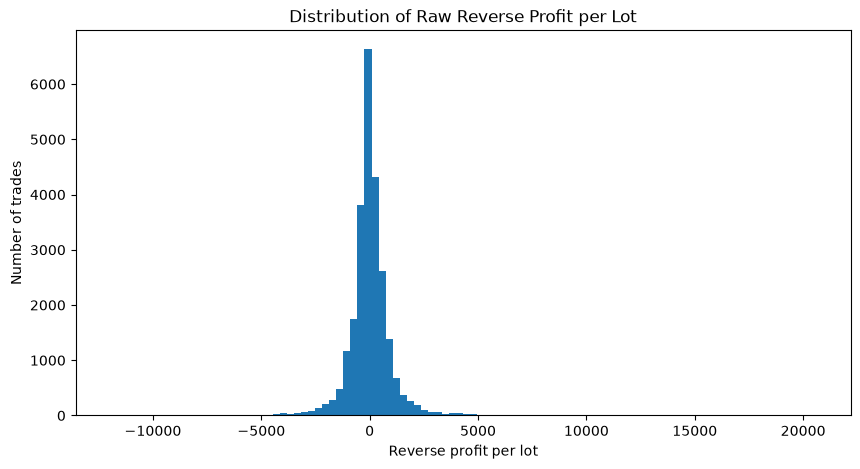

In [417]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    exp12_target_comparison[
        "raw_target"
    ].dropna(),
    bins=100,
)

plt.xlabel(
    "Reverse profit per lot"
)
plt.ylabel(
    "Number of trades"
)
plt.title(
    "Distribution of Raw Reverse Profit per Lot"
)

plt.show()

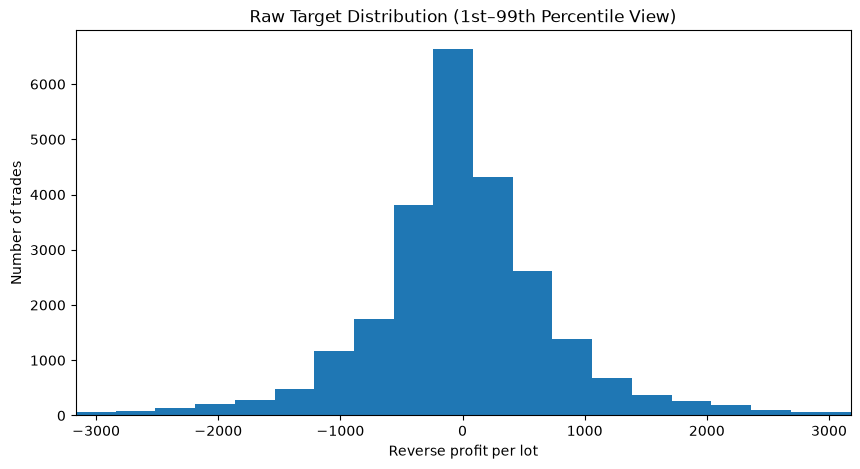

In [418]:
raw_lower = (
    exp12_target_comparison[
        "raw_target"
    ].quantile(0.01)
)

raw_upper = (
    exp12_target_comparison[
        "raw_target"
    ].quantile(0.99)
)

plt.figure(figsize=(10, 5))

plt.hist(
    exp12_target_comparison[
        "raw_target"
    ].dropna(),
    bins=100,
)

plt.xlim(
    raw_lower,
    raw_upper,
)

plt.xlabel(
    "Reverse profit per lot"
)
plt.ylabel(
    "Number of trades"
)
plt.title(
    "Raw Target Distribution "
    "(1st–99th Percentile View)"
)

plt.show()

### Signed-log target distribution

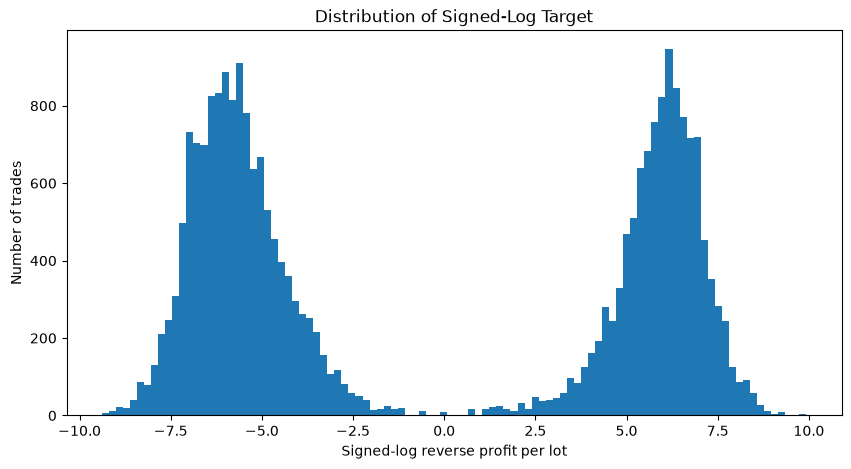

In [419]:
plt.figure(figsize=(10, 5))

plt.hist(
    exp12_target_comparison[
        "signed_log_target"
    ].dropna(),
    bins=100,
)

plt.xlabel(
    "Signed-log reverse profit per lot"
)
plt.ylabel(
    "Number of trades"
)
plt.title(
    "Distribution of Signed-Log Target"
)

plt.show()

### Raw target vs transformed target

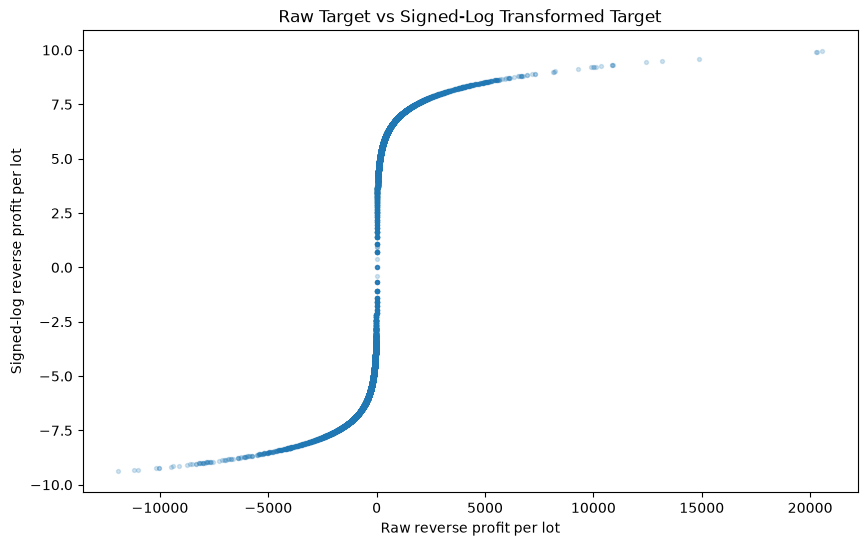

In [420]:
plt.figure(figsize=(10, 6))

plt.scatter(
    exp12_target_comparison[
        "raw_target"
    ],
    exp12_target_comparison[
        "signed_log_target"
    ],
    alpha=0.2,
    s=8,
)

plt.xlabel(
    "Raw reverse profit per lot"
)
plt.ylabel(
    "Signed-log reverse profit per lot"
)
plt.title(
    "Raw Target vs Signed-Log Transformed Target"
)

plt.show()

## Walk-forward model comparison

In [421]:
exp12_walk_forward_predictions = {}

for model_name in (
    regression_model_names
):
    print(
        f"Running {model_name}..."
    )

    exp12_walk_forward_predictions[
        model_name
    ] = (
        walk_forward_regressor_signed_log(
            data=exp12_train_data,
            feature_columns=(
                exp12_feature_columns
            ),
            target_column=(
                exp12_target_column
            ),
            model_name=model_name,
            minimum_training_campaigns=(
                exp12_minimum_training_campaigns
            ),
        )
    )

Running ridge...
Running elastic_net...
Running huber...


KeyboardInterrupt: 

## Threshold evaluation

In [ ]:
exp12_threshold_results = []

for model_name, predictions in (
    exp12_walk_forward_predictions.items()
):
    model_results = (
        evaluate_score_quantiles(
            predictions=predictions,
            score_column=(
                exp12_score_column
            ),
            quantiles=(
                candidate_quantiles
            ),
        )
    )

    model_results[
        "model_name"
    ] = model_name

    exp12_threshold_results.append(
        model_results
    )

exp12_threshold_results = (
    pd.concat(
        exp12_threshold_results,
        ignore_index=True,
    )
)

exp12_threshold_results

,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,model_name
0,0.5,-0.551036,6386,0.500039,0.776224,2.401452,ridge
1,0.7,0.122007,3832,0.300055,6.997752,7.665248,ridge
2,0.9,0.854238,1278,0.100070,7.122183,12.445951,ridge
3,0.5,-0.438818,6438,0.504111,-1.235321,3.112315,elastic_net
4,0.7,-0.254749,3832,0.300055,-2.158333,0.315912,elastic_net
5,0.9,-0.141239,1278,0.100070,13.951760,8.795592,elastic_net
6,0.5,-0.602463,6386,0.500039,1.500465,3.154253,huber
7,0.7,0.136473,3832,0.300055,7.009495,7.655621,huber
8,0.9,0.936401,1278,0.100070,2.058020,5.895161,huber
9,0.5,-0.335335,6386,0.500039,-0.870436,4.363304,random_forest


## Candidate evaluation and campaign robustness

In [ ]:
exp12_candidate_results = []

for model_name, predictions in (
    exp12_walk_forward_predictions.items()
):
    for quantile in (
        candidate_quantiles
    ):
        threshold = (
            predictions[
                exp12_score_column
            ]
            .quantile(
                quantile
            )
        )

        strategy_result = (
            evaluate_strategy(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp12_score_column
                ),
            )
        )

        campaign_results = (
            evaluate_strategy_by_campaign(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp12_score_column
                ),
            )
        )

        robustness = (
            summarize_campaign_robustness(
                campaign_results
            )
        )

        exp12_candidate_results.append(
            {
                "model_name":
                    model_name,
                "quantile":
                    quantile,
                "threshold":
                    threshold,
                **strategy_result,
                **robustness,
            }
        )

exp12_candidate_results = (
    pd.DataFrame(
        exp12_candidate_results
    )
)

exp12_candidate_results

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,ridge,0.5,-0.551036,6386,0.500039,0.776224,2.401452,10,5,0.5,-4.521346
1,ridge,0.7,0.122007,3832,0.300055,6.997752,7.665248,10,6,0.6,4.129643
2,ridge,0.9,0.854238,1278,0.100070,7.122183,12.445951,10,5,0.5,5.514942
3,elastic_net,0.5,-0.438818,6438,0.504111,-1.235321,3.112315,10,6,0.6,2.156759
4,elastic_net,0.7,-0.254749,3832,0.300055,-2.158333,0.315912,10,5,0.5,0.138830
5,elastic_net,0.9,-0.141239,1278,0.100070,13.951760,8.795592,10,6,0.6,9.912917
6,huber,0.5,-0.602463,6386,0.500039,1.500465,3.154253,10,4,0.4,-5.697446
7,huber,0.7,0.136473,3832,0.300055,7.009495,7.655621,10,4,0.4,-2.515834
8,huber,0.9,0.936401,1278,0.100070,2.058020,5.895161,10,5,0.5,-3.596670
9,random_forest,0.5,-0.335335,6386,0.500039,-0.870436,4.363304,10,5,0.5,-1.066163


## Candidate selection

In [ ]:
exp12_promising_candidates = (
    exp12_candidate_results.loc[
        (
            exp12_candidate_results[
                "mean_reverse_profit_per_lot"
            ] > 0
        )
        & (
            exp12_candidate_results[
                "total_reverse_profit_per_total_lot"
            ] > 0
        )
        & (
            exp12_candidate_results[
                "positive_campaign_share"
            ] >= 0.50
        )
        & (
            exp12_candidate_results[
                "median_campaign_profit_per_lot"
            ] > 0
        )
    ]
    .copy()
)

In [ ]:
exp12_promising_candidates = (
    exp12_promising_candidates
    .sort_values(
        [
            "positive_campaign_share",
            "median_campaign_profit_per_lot",
            "total_reverse_profit_per_total_lot",
            "mean_reverse_profit_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

exp12_promising_candidates

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,lightgbm,0.9,0.958719,1278,0.100070,39.273975,30.521670,10,8,0.8,44.621100
1,svr,0.9,3.906184,1278,0.100070,10.769595,6.131466,10,6,0.6,17.655540
2,hist_gradient_boosting,0.9,0.789308,1278,0.100070,22.852347,12.842299,10,6,0.6,16.132769
3,mlp,0.9,0.981545,1278,0.100070,38.038049,19.030749,10,6,0.6,11.782233
4,extra_trees,0.9,0.805934,1278,0.100070,26.152347,10.721962,10,6,0.6,11.295567
5,elastic_net,0.9,-0.141239,1278,0.100070,13.951760,8.795592,10,6,0.6,9.912917
6,lightgbm,0.7,0.093372,3832,0.300055,5.977523,8.408619,10,6,0.6,9.297472
7,ridge,0.7,0.122007,3832,0.300055,6.997752,7.665248,10,6,0.6,4.129643
8,catboost,0.9,0.916930,1278,0.100070,15.832681,12.142654,10,5,0.5,5.596723
9,ridge,0.9,0.854238,1278,0.100070,7.122183,12.445951,10,5,0.5,5.514942


In [ ]:
if exp12_promising_candidates.empty:
    print(
        "No Experiment 12 candidate "
        "passed the robustness criteria."
    )

else:
    exp12_selected_result = (
        exp12_promising_candidates.iloc[0]
    )

    exp12_selected_model_name = (
        exp12_selected_result[
            "model_name"
        ]
    )

    exp12_selected_quantile = (
        exp12_selected_result[
            "quantile"
        ]
    )

    exp12_selected_threshold = (
        exp12_selected_result[
            "threshold"
        ]
    )

    print(
        "Selected model:",
        exp12_selected_model_name,
    )

    print(
        "Selected quantile:",
        exp12_selected_quantile,
    )

    print(
        "Frozen transformed threshold:",
        exp12_selected_threshold,
    )

Selected model: lightgbm
Selected quantile: 0.9
Frozen transformed threshold: 0.9587193396945973


## Fit final model on campaigns 53-66

In [ ]:
exp12_transformed_train_target = (
    signed_log_transform(
        exp12_train_data[
            exp12_target_column
        ]
    )
)

In [ ]:
exp12_final_model = (
    build_regressor(
        exp12_selected_model_name
    )
)

exp12_final_model.fit(
    exp12_train_data[
        exp12_feature_columns
    ],
    exp12_transformed_train_target,
)

,num_leaves,15
,learning_rate,0.05
,n_estimators,200
,random_state,42
,verbosity,-1
,boosting_type,'gbdt'
,max_depth,-1
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


## Validation predictions

In [ ]:
exp12_validation_predictions = (
    exp12_validation_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
        ]
    ]
    .copy()
)

exp12_validation_predictions[
    exp12_score_column
] = exp12_final_model.predict(
    exp12_validation_data[
        exp12_feature_columns
    ]
)

In [ ]:
exp12_validation_predictions[
    "predicted_rp_per_lot_inverse_transformed"
] = inverse_signed_log_transform(
    exp12_validation_predictions[
        exp12_score_column
    ]
)

## Validation strategy result

In [ ]:
exp12_validation_result = (
    evaluate_strategy(
        predictions=(
            exp12_validation_predictions
        ),
        threshold=(
            exp12_selected_threshold
        ),
        score_column=(
            exp12_score_column
        ),
    )
)

exp12_validation_result

{'n_faded': 1931,
 'coverage': 0.09042378833996723,
 'mean_reverse_profit_per_lot': np.float64(-14.912673060175035),
 'total_reverse_profit_per_total_lot': np.float64(-19.352528163479175)}

## Validation campaign robustness

In [ ]:
exp12_validation_by_campaign = (
    evaluate_strategy_by_campaign(
        predictions=(
            exp12_validation_predictions
        ),
        threshold=(
            exp12_selected_threshold
        ),
        score_column=(
            exp12_score_column
        ),
    )
)

exp12_validation_by_campaign

,campaign_id,n_trades,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,53,1063,133,0.125118,76.610526,72.735308
1,54,1511,153,0.101257,20.084967,-5.186633
2,55,1222,101,0.082651,13.392857,-38.853054
3,56,1732,140,0.080831,-167.894388,-73.567737
4,57,1256,150,0.119427,13.726667,12.697132
5,58,1263,97,0.076801,-108.432990,-90.518482
6,59,1490,135,0.090604,24.548148,25.993990
7,60,1575,127,0.080635,28.755512,-34.739562
8,61,1573,156,0.099174,26.961538,8.915737
9,62,1602,127,0.079276,-19.459843,-17.641791


In [ ]:
exp12_validation_robustness = (
    summarize_campaign_robustness(
        exp12_validation_by_campaign
    )
)

exp12_validation_robustness

{'n_campaigns': 14,
 'positive_campaigns': np.int64(4),
 'positive_campaign_share': np.float64(0.2857142857142857),
 'median_campaign_profit_per_lot': np.float64(-20.636981716324414)}

## Account-cluster bootstrap

In [ ]:
exp12_bootstrap_results = (
    account_cluster_bootstrap(
        predictions=(
            exp12_validation_predictions
        ),
        threshold=(
            exp12_selected_threshold
        ),
        score_column=(
            exp12_score_column
        ),
        n_bootstrap=N_BOOTSTRAP,
        random_seed=RANDOM_SEED,
    )
)

Bootstrap progress: 100/1000
Bootstrap progress: 200/1000
Bootstrap progress: 300/1000
Bootstrap progress: 400/1000
Bootstrap progress: 500/1000
Bootstrap progress: 600/1000
Bootstrap progress: 700/1000
Bootstrap progress: 800/1000
Bootstrap progress: 900/1000
Bootstrap progress: 1000/1000
Bootstrap complete.


In [ ]:
exp12_bootstrap_summary = pd.DataFrame(
    [
        {
            "metric":
                "mean_reverse_profit_per_lot",
            **summarize_bootstrap(
                exp12_bootstrap_results,
                "mean_reverse_profit_per_lot",
            ),
        },
        {
            "metric":
                (
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            **summarize_bootstrap(
                exp12_bootstrap_results,
                (
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            ),
        },
    ]
)

exp12_bootstrap_summary

,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,-15.278532,-14.712667,-49.059820,18.228218,0.185
1,total_reverse_profit_per_total_lot,-19.787793,-19.897731,-39.726207,2.175055,0.040


## Exp10B vs Exp11A vs Exp12 comparison

In [ ]:
exp12_comparison = pd.DataFrame(
    [
        {
            "experiment":
                "Exp10B baseline",
            "target_handling":
                "raw",
            **exp10b_validation_result,
            **exp10b_validation_robustness,
        },
        {
            "experiment":
                "Exp11A feature winsorization",
            "target_handling":
                "raw",
            **exp11a_validation_result,
            **exp11a_validation_robustness,
        },
        {
            "experiment":
                "Exp12 signed-log target",
            "target_handling":
                "signed_log",
            **exp12_validation_result,
            **exp12_validation_robustness,
        },
    ]
)

exp12_comparison[
    [
        "experiment",
        "target_handling",
        "n_faded",
        "coverage",
        "mean_reverse_profit_per_lot",
        "total_reverse_profit_per_total_lot",
        "positive_campaign_share",
        "median_campaign_profit_per_lot",
    ]
]

,experiment,target_handling,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,positive_campaign_share,median_campaign_profit_per_lot
0,Exp10B baseline,raw,2065,0.096699,25.740818,16.322315,0.642857,19.472722
1,Exp11A feature winsorization,raw,2902,0.135893,29.528338,12.464073,0.571429,6.449580
2,Exp12 signed-log target,signed_log,1931,0.090424,-14.912673,-19.352528,0.285714,-20.636982


In [ ]:
print("Exp10B")
display(
    exp10b_bootstrap_summary
)

print("Exp11A")
display(
    exp11a_bootstrap_summary
)

print("Exp12")
display(
    exp12_bootstrap_summary
)

Exp10B


,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,27.240744,27.467669,-12.890623,66.119871,0.910
1,total_reverse_profit_per_total_lot,16.939604,17.155410,-11.437105,43.292725,0.889


Exp11A


,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,30.554631,30.660077,-2.359567,61.085019,0.963
1,total_reverse_profit_per_total_lot,12.784958,13.296058,-12.220733,35.120799,0.857


Exp12


,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,-15.278532,-14.712667,-49.059820,18.228218,0.185
1,total_reverse_profit_per_total_lot,-19.787793,-19.897731,-39.726207,2.175055,0.040


## Save result

In [ ]:
save_experiment_results(
    experiment_name="exp12",
    experiment_description="reduced_regression_signed_log_target",
    selected_result=exp12_selected_result,
    validation_predictions=exp12_validation_predictions,
    validation_result=exp12_validation_result,
    validation_by_campaign=exp12_validation_by_campaign,
    validation_robustness=exp12_validation_robustness,
    bootstrap_results=exp12_bootstrap_results,
    bootstrap_summary=exp12_bootstrap_summary,
)

Saved exp12 results to: outputs\stage3\exp12


# Experiment 13: Reduced-feature quantile regression

## Experiment configuration

In [ ]:
exp13_feature_columns = (
    exp10b_feature_columns.copy()
)

exp13_train_data = (
    base_train_data.copy()
)

exp13_validation_data = (
    base_validation_data.copy()
)

exp13_target_column = (
    regression_target_column
)

exp13_score_column = (
    "predicted_quantile_rp_per_lot"
)

exp13_minimum_training_campaigns = 10

In [ ]:
exp13_target_quantiles = [
    0.10,
    0.25,
    0.50,
]

In [ ]:
exp13_model_names = [
    "gradient_boosting",
    "hist_gradient_boosting",
    "lightgbm",
    "catboost",
]

In [ ]:
assert (
    exp13_target_column
    not in exp13_feature_columns
)

exp13_leaking_features = sorted(
    set(exp13_feature_columns)
    & set(banned_feature_columns)
)

assert not exp13_leaking_features, (
    "Leakage detected: "
    + ", ".join(
        exp13_leaking_features
    )
)

missing_exp13_features = sorted(
    set(exp13_feature_columns)
    - set(
        exp13_train_data.columns
    )
)

assert not missing_exp13_features, (
    "Missing features: "
    + ", ".join(
        missing_exp13_features
    )
)

print(
    "Number of features:",
    len(exp13_feature_columns),
)

print(
    "Target quantiles:",
    exp13_target_quantiles,
)

print(
    "Models:",
    exp13_model_names,
)

Number of features: 22
Target quantiles: [0.1, 0.25, 0.5]
Models: ['gradient_boosting', 'hist_gradient_boosting', 'lightgbm', 'catboost']


## Walk-forward predictions

In [ ]:
exp13_walk_forward_predictions = {}

for target_quantile in (
    exp13_target_quantiles
):
    for model_name in (
        exp13_model_names
    ):
        candidate_name = (
            f"{model_name}_"
            f"q{target_quantile:.2f}"
        )

        print(
            f"Running {candidate_name}..."
        )

        exp13_walk_forward_predictions[
            candidate_name
        ] = (
            walk_forward_quantile_regressor(
                data=exp13_train_data,
                feature_columns=(
                    exp13_feature_columns
                ),
                target_column=(
                    exp13_target_column
                ),
                model_name=model_name,
                target_quantile=(
                    target_quantile
                ),
                minimum_training_campaigns=(
                    exp13_minimum_training_campaigns
                ),
            )
        )

Running gradient_boosting_q0.10...


Running hist_gradient_boosting_q0.10...
Running lightgbm_q0.10...
Running catboost_q0.10...
Running gradient_boosting_q0.25...
Running hist_gradient_boosting_q0.25...
Running lightgbm_q0.25...
Running catboost_q0.25...
Running gradient_boosting_q0.50...
Running hist_gradient_boosting_q0.50...
Running lightgbm_q0.50...
Running catboost_q0.50...


## Candidate evaluation

In [ ]:
exp13_candidate_results = []

for target_quantile in (
    exp13_target_quantiles
):
    for model_name in (
        exp13_model_names
    ):
        candidate_name = (
            f"{model_name}_"
            f"q{target_quantile:.2f}"
        )

        predictions = (
            exp13_walk_forward_predictions[
                candidate_name
            ]
        )

        for selection_quantile in (
            candidate_quantiles
        ):
            threshold = (
                predictions[
                    exp13_score_column
                ]
                .quantile(
                    selection_quantile
                )
            )

            strategy_result = (
                evaluate_strategy(
                    predictions=predictions,
                    threshold=threshold,
                    score_column=(
                        exp13_score_column
                    ),
                )
            )

            campaign_results = (
                evaluate_strategy_by_campaign(
                    predictions=predictions,
                    threshold=threshold,
                    score_column=(
                        exp13_score_column
                    ),
                )
            )

            robustness = (
                summarize_campaign_robustness(
                    campaign_results
                )
            )

            exp13_candidate_results.append(
                {
                    "candidate_name":
                        candidate_name,
                    "model_name":
                        model_name,
                    "target_quantile":
                        target_quantile,
                    "selection_quantile":
                        selection_quantile,
                    "threshold":
                        threshold,
                    **strategy_result,
                    **robustness,
                }
            )

exp13_candidate_results = (
    pd.DataFrame(
        exp13_candidate_results
    )
)

In [ ]:
exp13_candidate_results[
    [
        "model_name",
        "target_quantile",
        "selection_quantile",
        "coverage",
        "mean_reverse_profit_per_lot",
        "total_reverse_profit_per_total_lot",
        "positive_campaign_share",
        "median_campaign_profit_per_lot",
    ]
].sort_values(
    [
        "positive_campaign_share",
        "median_campaign_profit_per_lot",
    ],
    ascending=False,
)

,model_name,target_quantile,selection_quantile,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,positive_campaign_share,median_campaign_profit_per_lot
11,catboost,0.10,0.9,0.100070,6.075665,4.758348,0.8,16.538474
18,lightgbm,0.25,0.5,0.500117,-8.301194,0.091731,0.7,9.309343
19,lightgbm,0.25,0.7,0.300055,-3.980257,1.011091,0.7,7.733531
5,hist_gradient_boosting,0.10,0.9,0.100070,-0.441549,-0.056671,0.7,6.594357
29,hist_gradient_boosting,0.50,0.9,0.100070,5.997770,11.712277,0.7,5.560670
28,hist_gradient_boosting,0.50,0.7,0.300055,10.869701,13.087677,0.7,5.356671
6,lightgbm,0.10,0.5,0.500039,-3.032838,0.177206,0.7,5.202698
7,lightgbm,0.10,0.7,0.300055,-5.579273,0.426218,0.6,13.075317
4,hist_gradient_boosting,0.10,0.7,0.300055,-4.620592,-0.218627,0.6,10.424253
10,catboost,0.10,0.7,0.300055,-6.249045,-0.108042,0.6,9.443048


## Apply the same robustness criteria

In [ ]:
exp13_promising_candidates = (
    exp13_candidate_results.loc[
        (
            exp13_candidate_results[
                "mean_reverse_profit_per_lot"
            ] > 0
        )
        & (
            exp13_candidate_results[
                "total_reverse_profit_per_total_lot"
            ] > 0
        )
        & (
            exp13_candidate_results[
                "positive_campaign_share"
            ] >= 0.50
        )
        & (
            exp13_candidate_results[
                "median_campaign_profit_per_lot"
            ] > 0
        )
    ]
    .copy()
)

In [ ]:
exp13_promising_candidates = (
    exp13_promising_candidates
    .sort_values(
        [
            "positive_campaign_share",
            "median_campaign_profit_per_lot",
            "total_reverse_profit_per_total_lot",
            "mean_reverse_profit_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

exp13_promising_candidates

,candidate_name,model_name,target_quantile,selection_quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,catboost_q0.10,catboost,0.1,0.9,-343.180076,1278,0.100070,6.075665,4.758348,10,8,0.8,16.538474
1,hist_gradient_boosting_q0.50,hist_gradient_boosting,0.5,0.9,106.773051,1278,0.100070,5.997770,11.712277,10,7,0.7,5.560670
2,hist_gradient_boosting_q0.50,hist_gradient_boosting,0.5,0.7,4.050949,3832,0.300055,10.869701,13.087677,10,7,0.7,5.356671
3,lightgbm_q0.50,lightgbm,0.5,0.9,120.934575,1278,0.100070,16.140571,20.025226,10,6,0.6,8.691356
4,lightgbm_q0.10,lightgbm,0.1,0.9,-332.126308,1278,0.100070,2.793975,4.959108,10,6,0.6,7.074177
5,catboost_q0.50,catboost,0.5,0.9,139.774797,1278,0.100070,15.528416,10.387580,10,6,0.6,2.719534
6,gradient_boosting_q0.50,gradient_boosting,0.5,0.7,10.027597,3832,0.300055,4.796345,9.457996,10,6,0.6,2.196770
7,gradient_boosting_q0.50,gradient_boosting,0.5,0.5,-40.798563,6389,0.500274,5.606796,9.499014,10,5,0.5,5.807241
8,lightgbm_q0.50,lightgbm,0.5,0.7,9.694167,3832,0.300055,7.568990,8.294763,10,5,0.5,3.097785
9,catboost_q0.50,catboost,0.5,0.7,16.375772,3832,0.300055,14.652394,13.167173,10,5,0.5,1.811430


## Freeze selected candidate

In [ ]:
if exp13_promising_candidates.empty:
    print(
        "No Experiment 13 candidate "
        "passed the robustness criteria."
    )

else:
    exp13_selected_result = (
        exp13_promising_candidates.iloc[0]
    )

    exp13_selected_model_name = (
        exp13_selected_result[
            "model_name"
        ]
    )

    exp13_selected_target_quantile = (
        exp13_selected_result[
            "target_quantile"
        ]
    )

    exp13_selected_selection_quantile = (
        exp13_selected_result[
            "selection_quantile"
        ]
    )

    exp13_selected_threshold = (
        exp13_selected_result[
            "threshold"
        ]
    )

    print(
        "Selected model:",
        exp13_selected_model_name,
    )

    print(
        "Target quantile:",
        exp13_selected_target_quantile,
    )

    print(
        "Selection quantile:",
        exp13_selected_selection_quantile,
    )

    print(
        "Frozen threshold:",
        exp13_selected_threshold,
    )

Selected model: catboost
Target quantile: 0.1
Selection quantile: 0.9
Frozen threshold: -343.1800759267819


## Fit final quantile model on campaigns 33-52

In [ ]:
exp13_final_model = (
    build_quantile_regressor(
        model_name=(
            exp13_selected_model_name
        ),
        target_quantile=(
            exp13_selected_target_quantile
        ),
    )
)

In [ ]:
exp13_final_model.fit(
    exp13_train_data[
        exp13_feature_columns
    ],
    exp13_train_data[
        exp13_target_column
    ],
)

CatBoostRegressor(depth=6, iterations=200, learning_rate=0.05, loss_function='Quantile:alpha=0.1', random_seed=42, verbose=False)

## Validation predictions

In [ ]:
exp13_validation_predictions = (
    exp13_validation_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
        ]
    ]
    .copy()
)

In [ ]:
exp13_validation_predictions[
    exp13_score_column
] = exp13_final_model.predict(
    exp13_validation_data[
        exp13_feature_columns
    ]
)

## Validation strategy

In [ ]:
exp13_validation_result = (
    evaluate_strategy(
        predictions=(
            exp13_validation_predictions
        ),
        threshold=(
            exp13_selected_threshold
        ),
        score_column=(
            exp13_score_column
        ),
    )
)

exp13_validation_result

{'n_faded': 4012,
 'coverage': 0.18787169281198782,
 'mean_reverse_profit_per_lot': np.float64(-11.953316897677894),
 'total_reverse_profit_per_total_lot': np.float64(-9.384912725735338)}

## Campaign robustness

In [ ]:
exp13_validation_by_campaign = (
    evaluate_strategy_by_campaign(
        predictions=(
            exp13_validation_predictions
        ),
        threshold=(
            exp13_selected_threshold
        ),
        score_column=(
            exp13_score_column
        ),
    )
)

exp13_validation_by_campaign

,campaign_id,n_trades,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,53,1063,134,0.126058,25.907569,34.377310
1,54,1511,190,0.125745,-19.410207,-28.168838
2,55,1222,164,0.134206,1.442683,9.109269
3,56,1732,224,0.129330,-33.518622,-33.431415
4,57,1256,183,0.145701,-5.923497,-2.828287
5,58,1263,247,0.195566,-24.295547,-7.041194
6,59,1490,220,0.147651,16.845455,13.781770
7,60,1575,250,0.158730,-33.340000,-32.626478
8,61,1573,346,0.219962,5.294412,4.330278
9,62,1602,444,0.277154,-14.753378,-11.287708


In [ ]:
exp13_validation_robustness = (
    summarize_campaign_robustness(
        exp13_validation_by_campaign
    )
)

exp13_validation_robustness

{'n_campaigns': 14,
 'positive_campaigns': np.int64(5),
 'positive_campaign_share': np.float64(0.35714285714285715),
 'median_campaign_profit_per_lot': np.float64(-9.164450739246323)}

## Account-cluster bootstrap

In [ ]:
exp13_bootstrap_results = (
    account_cluster_bootstrap(
        predictions=(
            exp13_validation_predictions
        ),
        threshold=(
            exp13_selected_threshold
        ),
        score_column=(
            exp13_score_column
        ),
        n_bootstrap=N_BOOTSTRAP,
        random_seed=RANDOM_SEED,
    )
)

Bootstrap progress: 100/1000
Bootstrap progress: 200/1000
Bootstrap progress: 300/1000
Bootstrap progress: 400/1000
Bootstrap progress: 500/1000
Bootstrap progress: 600/1000
Bootstrap progress: 700/1000
Bootstrap progress: 800/1000
Bootstrap progress: 900/1000
Bootstrap progress: 1000/1000
Bootstrap complete.


In [ ]:
exp13_bootstrap_summary = pd.DataFrame(
    [
        {
            "metric":
                "mean_reverse_profit_per_lot",
            **summarize_bootstrap(
                exp13_bootstrap_results,
                "mean_reverse_profit_per_lot",
            ),
        },
        {
            "metric":
                (
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            **summarize_bootstrap(
                exp13_bootstrap_results,
                (
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            ),
        },
    ]
)

exp13_bootstrap_summary

,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,-12.061772,-11.949023,-20.292168,-3.894980,0.002
1,total_reverse_profit_per_total_lot,-9.525847,-9.425189,-17.743547,-1.468775,0.008


## Save result

In [ ]:
save_experiment_results(
    experiment_name="exp13",
    experiment_description="reduced_feature_quantile_regression",
    selected_result=exp13_selected_result,
    validation_predictions=exp13_validation_predictions,
    validation_result=exp13_validation_result,
    validation_by_campaign=exp13_validation_by_campaign,
    validation_robustness=exp13_validation_robustness,
    bootstrap_results=exp13_bootstrap_results,
    bootstrap_summary=exp13_bootstrap_summary,
)

Saved exp13 results to: outputs\stage3\exp13


# Experiment 14: Reduced-feeature neural-network rergession

## Imports and reproducibility

In [ ]:
import copy
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import (
    DataLoader,
    TensorDataset,
)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [ ]:
def set_neural_network_seed(
    seed=RANDOM_SEED,
):
    """Set random seeds for reproducible neural-network training."""

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            seed
        )


set_neural_network_seed()

NameError: name 'RANDOM_SEED' is not defined

In [ ]:
exp14_device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Neural-network device:",
    exp14_device,
)

## Neural network architecture

In [ ]:
class TabularRegressionNetwork(
    nn.Module,
):
    """Small feed-forward network for tabular regression."""

    def __init__(
        self,
        n_features,
        dropout_rate=0.20,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                n_features,
                64,
            ),
            nn.ReLU(),
            nn.LayerNorm(64),
            nn.Dropout(
                dropout_rate
            ),

            nn.Linear(
                64,
                32,
            ),
            nn.ReLU(),
            nn.LayerNorm(32),
            nn.Dropout(
                dropout_rate
            ),

            nn.Linear(
                32,
                16,
            ),
            nn.ReLU(),

            nn.Linear(
                16,
                1,
            ),
        )

    def forward(
        self,
        x,
    ):
        return (
            self.network(x)
            .squeeze(-1)
        )

## Loss function helper

In [ ]:
def build_neural_regression_loss(
    loss_name,
):
    """Build the neural-network regression loss."""

    if loss_name == "mse":
        return nn.MSELoss()

    if loss_name == "huber":
        return nn.HuberLoss(
            delta=1.0
        )

    raise ValueError(
        f"Unknown loss: "
        f"{loss_name}"
    )

## Preprocessing helper

In [ ]:
def fit_neural_preprocessors(
    data,
    feature_columns,
    target_column,
):
    """Fit feature and target preprocessing from training data."""

    feature_imputer = (
        SimpleImputer(
            strategy="median"
        )
    )

    feature_scaler = (
        StandardScaler()
    )

    target_scaler = (
        StandardScaler()
    )

    X_imputed = (
        feature_imputer.fit_transform(
            data[
                feature_columns
            ]
        )
    )

    feature_scaler.fit(
        X_imputed
    )

    target_scaler.fit(
        data[
            [target_column]
        ]
    )

    return {
        "feature_imputer":
            feature_imputer,
        "feature_scaler":
            feature_scaler,
        "target_scaler":
            target_scaler,
    }

In [ ]:
def transform_neural_data(
    data,
    feature_columns,
    target_column,
    preprocessors,
):
    """Apply fitted neural-network preprocessing."""

    X = (
        preprocessors[
            "feature_imputer"
        ]
        .transform(
            data[
                feature_columns
            ]
        )
    )

    X = (
        preprocessors[
            "feature_scaler"
        ]
        .transform(X)
    )

    y = (
        preprocessors[
            "target_scaler"
        ]
        .transform(
            data[
                [target_column]
            ]
        )
        .ravel()
    )

    return X, y

In [ ]:
def transform_neural_features(
    data,
    feature_columns,
    preprocessors,
):
    """Transform features for neural-network prediction."""

    X = (
        preprocessors[
            "feature_imputer"
        ]
        .transform(
            data[
                feature_columns
            ]
        )
    )

    X = (
        preprocessors[
            "feature_scaler"
        ]
        .transform(X)
    )

    return X

## Tensor helper

In [ ]:
def make_regression_loader(
    X,
    y,
    batch_size,
    shuffle,
):
    """Create a PyTorch regression DataLoader."""

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32,
    )

    y_tensor = torch.tensor(
        y,
        dtype=torch.float32,
    )

    dataset = TensorDataset(
        X_tensor,
        y_tensor,
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
    )

## Find the best number of epochs

In [ ]:
def find_best_neural_epoch(
    data,
    feature_columns,
    target_column,
    loss_name,
    max_epochs=150,
    patience=12,
    batch_size=512,
    learning_rate=0.001,
    weight_decay=0.0001,
    dropout_rate=0.20,
    campaign_column="campaign_id",
):
    """Find the best epoch using the latest historical campaign."""

    campaigns = sorted(
        data[
            campaign_column
        ]
        .dropna()
        .unique()
    )

    if len(campaigns) < 2:
        raise ValueError(
            "At least two campaigns are "
            "required for early stopping."
        )

    validation_campaign = (
        campaigns[-1]
    )

    fitting_campaigns = (
        campaigns[:-1]
    )

    fit_data = (
        data.loc[
            data[
                campaign_column
            ].isin(
                fitting_campaigns
            )
        ]
        .copy()
    )

    early_stop_data = (
        data.loc[
            data[
                campaign_column
            ]
            == validation_campaign
        ]
        .copy()
    )

    preprocessors = (
        fit_neural_preprocessors(
            data=fit_data,
            feature_columns=(
                feature_columns
            ),
            target_column=(
                target_column
            ),
        )
    )

    X_fit, y_fit = (
        transform_neural_data(
            data=fit_data,
            feature_columns=(
                feature_columns
            ),
            target_column=(
                target_column
            ),
            preprocessors=(
                preprocessors
            ),
        )
    )

    X_early, y_early = (
        transform_neural_data(
            data=early_stop_data,
            feature_columns=(
                feature_columns
            ),
            target_column=(
                target_column
            ),
            preprocessors=(
                preprocessors
            ),
        )
    )

    train_loader = (
        make_regression_loader(
            X=X_fit,
            y=y_fit,
            batch_size=batch_size,
            shuffle=True,
        )
    )

    X_early_tensor = torch.tensor(
        X_early,
        dtype=torch.float32,
        device=exp14_device,
    )

    y_early_tensor = torch.tensor(
        y_early,
        dtype=torch.float32,
        device=exp14_device,
    )

    set_neural_network_seed()

    model = (
        TabularRegressionNetwork(
            n_features=len(
                feature_columns
            ),
            dropout_rate=(
                dropout_rate
            ),
        )
        .to(
            exp14_device
        )
    )

    loss_function = (
        build_neural_regression_loss(
            loss_name
        )
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    best_validation_loss = (
        np.inf
    )

    best_epoch = 1
    epochs_without_improvement = 0

    for epoch in range(
        1,
        max_epochs + 1,
    ):
        model.train()

        for (
            X_batch,
            y_batch,
        ) in train_loader:
            X_batch = (
                X_batch.to(
                    exp14_device
                )
            )

            y_batch = (
                y_batch.to(
                    exp14_device
                )
            )

            optimizer.zero_grad()

            predictions = model(
                X_batch
            )

            loss = loss_function(
                predictions,
                y_batch,
            )

            loss.backward()

            optimizer.step()

        model.eval()

        with torch.no_grad():
            validation_predictions = (
                model(
                    X_early_tensor
                )
            )

            validation_loss = (
                loss_function(
                    validation_predictions,
                    y_early_tensor,
                )
                .item()
            )

        if (
            validation_loss
            < best_validation_loss
            - 1e-5
        ):
            best_validation_loss = (
                validation_loss
            )

            best_epoch = epoch

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= patience
        ):
            break

    return {
        "best_epoch":
            best_epoch,
        "best_validation_loss":
            best_validation_loss,
        "early_stop_campaign":
            validation_campaign,
    }

## Fit neural network for a fixed number of epochs

In [ ]:
def fit_neural_regressor(
    data,
    feature_columns,
    target_column,
    loss_name,
    n_epochs,
    batch_size=512,
    learning_rate=0.001,
    weight_decay=0.0001,
    dropout_rate=0.20,
):
    """Fit a neural regressor on all supplied training data."""

    preprocessors = (
        fit_neural_preprocessors(
            data=data,
            feature_columns=(
                feature_columns
            ),
            target_column=(
                target_column
            ),
        )
    )

    X_train, y_train = (
        transform_neural_data(
            data=data,
            feature_columns=(
                feature_columns
            ),
            target_column=(
                target_column
            ),
            preprocessors=(
                preprocessors
            ),
        )
    )

    train_loader = (
        make_regression_loader(
            X=X_train,
            y=y_train,
            batch_size=batch_size,
            shuffle=True,
        )
    )

    set_neural_network_seed()

    model = (
        TabularRegressionNetwork(
            n_features=len(
                feature_columns
            ),
            dropout_rate=(
                dropout_rate
            ),
        )
        .to(
            exp14_device
        )
    )

    loss_function = (
        build_neural_regression_loss(
            loss_name
        )
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    for _ in range(
        n_epochs
    ):
        model.train()

        for (
            X_batch,
            y_batch,
        ) in train_loader:
            X_batch = (
                X_batch.to(
                    exp14_device
                )
            )

            y_batch = (
                y_batch.to(
                    exp14_device
                )
            )

            optimizer.zero_grad()

            predictions = model(
                X_batch
            )

            loss = loss_function(
                predictions,
                y_batch,
            )

            loss.backward()

            optimizer.step()

    return {
        "model":
            model,
        "preprocessors":
            preprocessors,
        "n_epochs":
            n_epochs,
        "loss_name":
            loss_name,
    }

## Prediction helper

In [ ]:
def predict_neural_regressor(
    fitted_model,
    data,
    feature_columns,
):
    """Generate RP/lot predictions from a fitted neural regressor."""

    model = (
        fitted_model[
            "model"
        ]
    )

    preprocessors = (
        fitted_model[
            "preprocessors"
        ]
    )

    X = (
        transform_neural_features(
            data=data,
            feature_columns=(
                feature_columns
            ),
            preprocessors=(
                preprocessors
            ),
        )
    )

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32,
        device=exp14_device,
    )

    model.eval()

    with torch.no_grad():
        standardized_predictions = (
            model(
                X_tensor
            )
            .cpu()
            .numpy()
        )

    predictions = (
        preprocessors[
            "target_scaler"
        ]
        .inverse_transform(
            standardized_predictions.reshape(
                -1,
                1,
            )
        )
        .ravel()
    )

    return predictions

## Walk-forward neural regression

In [ ]:
def walk_forward_neural_regressor(
    data,
    feature_columns,
    target_column,
    loss_name,
    minimum_training_campaigns,
    max_epochs=150,
    patience=12,
    batch_size=512,
    learning_rate=0.001,
    weight_decay=0.0001,
    dropout_rate=0.20,
    campaign_column="campaign_id",
):
    """Generate walk-forward neural-network regression predictions."""

    campaigns = sorted(
        data[
            campaign_column
        ]
        .dropna()
        .unique()
    )

    prediction_frames = []

    for test_index in range(
        minimum_training_campaigns,
        len(campaigns),
    ):
        test_campaign = (
            campaigns[test_index]
        )

        training_campaigns = (
            campaigns[:test_index]
        )

        train_data = (
            data.loc[
                data[
                    campaign_column
                ].isin(
                    training_campaigns
                )
            ]
            .copy()
        )

        test_data = (
            data.loc[
                data[
                    campaign_column
                ]
                == test_campaign
            ]
            .copy()
        )

        print(
            f"{loss_name}: "
            f"predicting campaign "
            f"{test_campaign}"
        )

        epoch_result = (
            find_best_neural_epoch(
                data=train_data,
                feature_columns=(
                    feature_columns
                ),
                target_column=(
                    target_column
                ),
                loss_name=(
                    loss_name
                ),
                max_epochs=(
                    max_epochs
                ),
                patience=patience,
                batch_size=batch_size,
                learning_rate=(
                    learning_rate
                ),
                weight_decay=(
                    weight_decay
                ),
                dropout_rate=(
                    dropout_rate
                ),
                campaign_column=(
                    campaign_column
                ),
            )
        )

        best_epoch = (
            epoch_result[
                "best_epoch"
            ]
        )

        print(
            f"  best epoch: "
            f"{best_epoch}"
        )

        fitted_model = (
            fit_neural_regressor(
                data=train_data,
                feature_columns=(
                    feature_columns
                ),
                target_column=(
                    target_column
                ),
                loss_name=(
                    loss_name
                ),
                n_epochs=(
                    best_epoch
                ),
                batch_size=batch_size,
                learning_rate=(
                    learning_rate
                ),
                weight_decay=(
                    weight_decay
                ),
                dropout_rate=(
                    dropout_rate
                ),
            )
        )

        predictions = (
            predict_neural_regressor(
                fitted_model=(
                    fitted_model
                ),
                data=test_data,
                feature_columns=(
                    feature_columns
                ),
            )
        )

        fold_predictions = (
            test_data[
                [
                    "trade_row_id",
                    "campaign_id",
                    "account_id",
                    "amount",
                    "reverse_profit",
                    "reverse_profit_per_lot",
                ]
            ]
            .copy()
        )

        fold_predictions[
            "predicted_reverse_profit_per_lot"
        ] = predictions

        fold_predictions[
            "neural_best_epoch"
        ] = best_epoch

        prediction_frames.append(
            fold_predictions
        )

    return pd.concat(
        prediction_frames,
        ignore_index=True,
    )

## Experiment configuration

In [ ]:
exp14_feature_columns = (
    exp10b_feature_columns.copy()
)

exp14_train_data = (
    base_train_data.copy()
)

exp14_validation_data = (
    base_validation_data.copy()
)

exp14_target_column = (
    regression_target_column
)

exp14_score_column = (
    "predicted_reverse_profit_per_lot"
)

exp14_minimum_training_campaigns = 10

In [ ]:
exp14_loss_names = [
    "mse",
    "huber",
]

In [ ]:
exp14_max_epochs = 150
exp14_patience = 12

exp14_batch_size = 512

exp14_learning_rate = 0.001
exp14_weight_decay = 0.0001

exp14_dropout_rate = 0.20

In [ ]:
assert (
    exp14_target_column
    not in exp14_feature_columns
)

exp14_leaking_features = sorted(
    set(exp14_feature_columns)
    & set(banned_feature_columns)
)

assert not exp14_leaking_features, (
    "Leakage detected: "
    + ", ".join(
        exp14_leaking_features
    )
)

print(
    "Number of features:",
    len(exp14_feature_columns),
)

print(
    "Loss functions:",
    exp14_loss_names,
)

print(
    "Device:",
    exp14_device,
)

## Walk-forward predictions

In [ ]:
exp14_walk_forward_predictions = {}

for loss_name in (
    exp14_loss_names
):
    print(
        "\n"
        + "=" * 60
    )

    print(
        f"Running neural network "
        f"with {loss_name} loss"
    )

    print(
        "=" * 60
    )

    exp14_walk_forward_predictions[
        loss_name
    ] = (
        walk_forward_neural_regressor(
            data=exp14_train_data,
            feature_columns=(
                exp14_feature_columns
            ),
            target_column=(
                exp14_target_column
            ),
            loss_name=loss_name,
            minimum_training_campaigns=(
                exp14_minimum_training_campaigns
            ),
            max_epochs=(
                exp14_max_epochs
            ),
            patience=(
                exp14_patience
            ),
            batch_size=(
                exp14_batch_size
            ),
            learning_rate=(
                exp14_learning_rate
            ),
            weight_decay=(
                exp14_weight_decay
            ),
            dropout_rate=(
                exp14_dropout_rate
            ),
        )
    )

## Inspect selected epochs

In [ ]:
exp14_epoch_summary = []

for loss_name, predictions in (
    exp14_walk_forward_predictions.items()
):
    epoch_by_campaign = (
        predictions[
            [
                "campaign_id",
                "neural_best_epoch",
            ]
        ]
        .drop_duplicates()
    )

    exp14_epoch_summary.append(
        {
            "loss_name":
                loss_name,
            "mean_best_epoch":
                epoch_by_campaign[
                    "neural_best_epoch"
                ].mean(),
            "median_best_epoch":
                epoch_by_campaign[
                    "neural_best_epoch"
                ].median(),
            "min_best_epoch":
                epoch_by_campaign[
                    "neural_best_epoch"
                ].min(),
            "max_best_epoch":
                epoch_by_campaign[
                    "neural_best_epoch"
                ].max(),
        }
    )

exp14_epoch_summary = pd.DataFrame(
    exp14_epoch_summary
)

exp14_epoch_summary

## Threshold evaluation

In [ ]:
exp14_threshold_results = []

for loss_name, predictions in (
    exp14_walk_forward_predictions.items()
):
    model_results = (
        evaluate_score_quantiles(
            predictions=predictions,
            score_column=(
                exp14_score_column
            ),
            quantiles=(
                candidate_quantiles
            ),
        )
    )

    model_results[
        "loss_name"
    ] = loss_name

    exp14_threshold_results.append(
        model_results
    )

exp14_threshold_results = (
    pd.concat(
        exp14_threshold_results,
        ignore_index=True,
    )
)

exp14_threshold_results

## Candidate evaluation

In [ ]:
exp14_candidate_results = []

for loss_name, predictions in (
    exp14_walk_forward_predictions.items()
):
    for selection_quantile in (
        candidate_quantiles
    ):
        threshold = (
            predictions[
                exp14_score_column
            ]
            .quantile(
                selection_quantile
            )
        )

        strategy_result = (
            evaluate_strategy(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp14_score_column
                ),
            )
        )

        campaign_results = (
            evaluate_strategy_by_campaign(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp14_score_column
                ),
            )
        )

        robustness = (
            summarize_campaign_robustness(
                campaign_results
            )
        )

        exp14_candidate_results.append(
            {
                "loss_name":
                    loss_name,
                "selection_quantile":
                    selection_quantile,
                "threshold":
                    threshold,
                **strategy_result,
                **robustness,
            }
        )

exp14_candidate_results = pd.DataFrame(
    exp14_candidate_results
)

exp14_candidate_results

## Candidate selection

In [ ]:
exp14_promising_candidates = (
    exp14_candidate_results.loc[
        (
            exp14_candidate_results[
                "mean_reverse_profit_per_lot"
            ] > 0
        )
        & (
            exp14_candidate_results[
                "total_reverse_profit_per_total_lot"
            ] > 0
        )
        & (
            exp14_candidate_results[
                "positive_campaign_share"
            ] >= 0.50
        )
        & (
            exp14_candidate_results[
                "median_campaign_profit_per_lot"
            ] > 0
        )
    ]
    .copy()
)

In [ ]:
exp14_promising_candidates = (
    exp14_promising_candidates
    .sort_values(
        [
            "positive_campaign_share",
            "median_campaign_profit_per_lot",
            "total_reverse_profit_per_total_lot",
            "mean_reverse_profit_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

exp14_promising_candidates

In [ ]:
if exp14_promising_candidates.empty:
    print(
        "No Experiment 14 candidate "
        "passed the robustness criteria."
    )

else:
    exp14_selected_result = (
        exp14_promising_candidates.iloc[0]
    )

    exp14_selected_loss_name = (
        exp14_selected_result[
            "loss_name"
        ]
    )

    exp14_selected_quantile = (
        exp14_selected_result[
            "selection_quantile"
        ]
    )

    exp14_selected_threshold = (
        exp14_selected_result[
            "threshold"
        ]
    )

    print(
        "Selected loss:",
        exp14_selected_loss_name,
    )

    print(
        "Selected quantile:",
        exp14_selected_quantile,
    )

    print(
        "Frozen threshold:",
        exp14_selected_threshold,
    )

## Determine final training epochs

In [ ]:
exp14_final_epoch_result = (
    find_best_neural_epoch(
        data=exp14_train_data,
        feature_columns=(
            exp14_feature_columns
        ),
        target_column=(
            exp14_target_column
        ),
        loss_name=(
            exp14_selected_loss_name
        ),
        max_epochs=(
            exp14_max_epochs
        ),
        patience=(
            exp14_patience
        ),
        batch_size=(
            exp14_batch_size
        ),
        learning_rate=(
            exp14_learning_rate
        ),
        weight_decay=(
            exp14_weight_decay
        ),
        dropout_rate=(
            exp14_dropout_rate
        ),
    )
)

exp14_final_best_epoch = (
    exp14_final_epoch_result[
        "best_epoch"
    ]
)

print(
    "Final selected epochs:",
    exp14_final_best_epoch,
)

In [ ]:
exp14_final_model = (
    fit_neural_regressor(
        data=exp14_train_data,
        feature_columns=(
            exp14_feature_columns
        ),
        target_column=(
            exp14_target_column
        ),
        loss_name=(
            exp14_selected_loss_name
        ),
        n_epochs=(
            exp14_final_best_epoch
        ),
        batch_size=(
            exp14_batch_size
        ),
        learning_rate=(
            exp14_learning_rate
        ),
        weight_decay=(
            exp14_weight_decay
        ),
        dropout_rate=(
            exp14_dropout_rate
        ),
    )
)

## Validation predictions

In [ ]:
exp14_validation_predictions = (
    exp14_validation_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
        ]
    ]
    .copy()
)

In [ ]:
exp14_validation_predictions[
    exp14_score_column
] = predict_neural_regressor(
    fitted_model=(
        exp14_final_model
    ),
    data=(
        exp14_validation_data
    ),
    feature_columns=(
        exp14_feature_columns
    ),
)

## Validation strategy

In [ ]:
exp14_validation_result = (
    evaluate_strategy(
        predictions=(
            exp14_validation_predictions
        ),
        threshold=(
            exp14_selected_threshold
        ),
        score_column=(
            exp14_score_column
        ),
    )
)

exp14_validation_result

## Campaign robustness

In [ ]:
exp14_validation_by_campaign = (
    evaluate_strategy_by_campaign(
        predictions=(
            exp14_validation_predictions
        ),
        threshold=(
            exp14_selected_threshold
        ),
        score_column=(
            exp14_score_column
        ),
    )
)

exp14_validation_by_campaign

In [ ]:
exp14_validation_robustness = (
    summarize_campaign_robustness(
        exp14_validation_by_campaign
    )
)

exp14_validation_robustness

## Account-cluster bootstrap

In [ ]:
exp14_bootstrap_results = (
    account_cluster_bootstrap(
        predictions=(
            exp14_validation_predictions
        ),
        threshold=(
            exp14_selected_threshold
        ),
        score_column=(
            exp14_score_column
        ),
        n_bootstrap=N_BOOTSTRAP,
        random_seed=RANDOM_SEED,
    )
)

In [ ]:
exp14_bootstrap_summary = pd.DataFrame(
    [
        {
            "metric":
                "mean_reverse_profit_per_lot",
            **summarize_bootstrap(
                exp14_bootstrap_results,
                "mean_reverse_profit_per_lot",
            ),
        },
        {
            "metric":
                (
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            **summarize_bootstrap(
                exp14_bootstrap_results,
                (
                    "total_reverse_profit_"
                    "per_total_lot"
                ),
            ),
        },
    ]
)

exp14_bootstrap_summary

## Final comparison

In [ ]:
exp14_comparison = pd.DataFrame(
    [
        {
            "experiment":
                "Exp10B conventional regression",
            "model_type":
                "traditional",
            **exp10b_validation_result,
            **exp10b_validation_robustness,
        },
        {
            "experiment":
                "Exp11A winsorized regression",
            "model_type":
                "traditional_winsorized",
            **exp11a_validation_result,
            **exp11a_validation_robustness,
        },
        {
            "experiment":
                (
                    f"Exp14 neural network "
                    f"({exp14_selected_loss_name})"
                ),
            "model_type":
                "neural_network",
            **exp14_validation_result,
            **exp14_validation_robustness,
        },
    ]
)

exp14_comparison[
    [
        "experiment",
        "model_type",
        "n_faded",
        "coverage",
        "mean_reverse_profit_per_lot",
        "total_reverse_profit_per_total_lot",
        "positive_campaign_share",
        "median_campaign_profit_per_lot",
    ]
]

In [ ]:
print("Exp10B")
display(
    exp10b_bootstrap_summary
)

print("Exp11A")
display(
    exp11a_bootstrap_summary
)

print("Exp14")
display(
    exp14_bootstrap_summary
)

## Save result

In [ ]:
save_experiment_results(
    experiment_name="exp14",
    experiment_description="reduced_feature_neural_network_regression",
    selected_result=exp14_selected_result,
    validation_predictions=exp14_validation_predictions,
    validation_result=exp14_validation_result,
    validation_by_campaign=exp14_validation_by_campaign,
    validation_robustness=exp14_validation_robustness,
    bootstrap_results=exp14_bootstrap_results,
    bootstrap_summary=exp14_bootstrap_summary,
)